# YOLO11 알약 객체 탐지 — 전처리·EDA·증강 파이프라인 v6.0.5

`IntegratedDataset.tar`를 검증·정제하고, 기존 group-safe Train/Validation 분할을 유지한 YOLO 형식 데이터셋을 생성한다.

주요 작업은 이미지 무결성 검사, 클래스·BBox 검증, 중복 후보 탐색, 그룹 기반 EDA, 색상·화질 정규화, 960×960 letterbox, export 무결성 검사다. 마지막 절에는 Train 전용 오프라인 증강 기능을 별도로 제공한다.

## 데이터 계약과 처리 원칙

| 항목 | 값 |
|---|---:|
| 라벨 이미지 | 12,196 |
| Train | 9,763 |
| Validation | 2,433 |
| 객체 | 46,394 |
| 클래스 | 118 |
| 촬영 조합 그룹 | 4,104 |
| 추론 전용 이미지 | 842 |

- `split_manifest.csv`의 Train/Validation과 `group_id`를 기준으로 사용한다.
- 병합 과정의 `base__` / `extra__` 접두사 때문에 파일명만으로 그룹을 다시 만들지 않는다.
- base 232장은 병합본 기준 763 objects 상태를 그대로 사용한다.
- 검토 항목은 `manual_review_decisions_v6_0.csv`에 판정 근거를 기록한다.
- export 이미지는 색상·화질 정규화와 960×960 letterbox를 적용하고 BBox를 함께 변환한다.

## 공통 데이터 계약

- 출력 루트: `pill_yolo_full_v6_0_preprocessed`
- 구조: `images/train`, `images/val`, `labels/train`, `labels/val`
- 기존 Train/Validation 분할 유지
- 원본 파일명 유지
- YOLO class ID 118개 유지
- `class_mapping.csv`: YOLO class ID ↔ 원본 category ID
- `dataset_manifest.csv`: split, group_id, 객체 수, 파일 해시
- `data.yaml`: `train: images/train`, `val: images/val`

## 실행 모드

`audit`는 데이터 검사와 EDA를 수행하고, `release`는 검증을 통과한 학습용 데이터셋을 생성한다. 실행 모드는 노트북 시작 단계에서 한 번만 설정한다.

In [1]:
# 이미 마운트된 Drive는 다시 마운트하지 않는다.
# 재마운트는 진행 중인 I/O를 끊을 수 있어 기존 연결을 유지한다.
import os

try:
    from google.colab import drive
    if not os.path.isdir('/content/drive/MyDrive'):
        drive.mount('/content/drive')
    else:
        print('Google Drive is already mounted.')
except ImportError:
    print('Not running in Google Colab; Drive mount skipped.')


Mounted at /content/drive


In [2]:
# 실행 모드 선택.
# release 실행 시 DEFAULT_BUILD_MODE를 'release'로 바꾼 뒤 런타임을 재시작하고 Run all 하면 된다.
# 외부에서 YOLO_BUILD_MODE 환경변수를 지정한 경우 그 값이 우선한다.
import os

DEFAULT_BUILD_MODE = 'release'  # 'audit' | 'release'
requested_build_mode = os.getenv('YOLO_BUILD_MODE', DEFAULT_BUILD_MODE).strip().lower()
if requested_build_mode not in {'audit', 'release'}:
    raise ValueError("YOLO_BUILD_MODE must be 'audit' or 'release'.")
os.environ['YOLO_BUILD_MODE'] = requested_build_mode
print(f'YOLO_BUILD_MODE={requested_build_mode}')


YOLO_BUILD_MODE=release


## 1. 환경 설정·경로·품질 정책

### 공통 설정 초기화

경로, 임계값, seed, 진행률, 폰트, 해시와 검토 관련 공용 설정을 정의한다.

In [3]:
# 오래 걸리는 반복의 진행률을 표시하기 위해 필요한 클래스·함수를 가져온다.
from tqdm.auto import tqdm as _pipeline_tqdm

_PIPELINE_TOTAL_CELLS = 29
_pipeline_overall_bar = _pipeline_tqdm(
    total=_PIPELINE_TOTAL_CELLS,
    desc='Overall progress', unit='cell', dynamic_ncols=True, leave=True,
    bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{percentage:3.0f}%]',
)
_pipeline_current_cell_bar = None


def pipeline_cell_start(step, title):
    # 현재 단계의 계산·검증 흐름을 순서대로 이어간다.
    global _pipeline_current_cell_bar
    if _pipeline_current_cell_bar is not None:
        _pipeline_current_cell_bar.close()
    _pipeline_overall_bar.n = max(0, step - 1)
    _pipeline_overall_bar.set_description_str(
        f'Overall progress · {step}/{_PIPELINE_TOTAL_CELLS} · {title}'
    )
    _pipeline_overall_bar.refresh()
    _pipeline_current_cell_bar = _pipeline_tqdm(
        total=1, desc=f'Current cell · {step}/{_PIPELINE_TOTAL_CELLS} · {title}',
        unit='cell', dynamic_ncols=True, leave=True,
        bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{percentage:3.0f}%]',
    )


def pipeline_cell_finish(step):
    # 현재 단계의 계산·검증 흐름을 순서대로 이어간다.
    global _pipeline_current_cell_bar
    if _pipeline_current_cell_bar is not None:
        remaining = max(0, 1 - _pipeline_current_cell_bar.n)
        if remaining:
            _pipeline_current_cell_bar.update(remaining)
        _pipeline_current_cell_bar.close()
        _pipeline_current_cell_bar = None
    _pipeline_overall_bar.n = min(step, _PIPELINE_TOTAL_CELLS)
    if step == _PIPELINE_TOTAL_CELLS:
        _pipeline_overall_bar.set_description_str('Overall progress · complete')
    _pipeline_overall_bar.refresh()

pipeline_cell_start(1, "1. Environment, paths, and quality policy")

from pathlib import Path
from collections import Counter, defaultdict
from itertools import combinations
from numbers import Real
from importlib import metadata as importlib_metadata
from io import BytesIO
from functools import lru_cache
from IPython.display import display
# 원본과 산출물의 SHA-256 해시를 계산하기 위해 관련 라이브러리를 불러온다.
import hashlib
# 설정·메타데이터 JSON을 읽고 쓰기 위해 관련 라이브러리를 불러온다.
import json
# 이 단계에 필요한 기능을 사용하기 위해 관련 라이브러리를 불러온다.
import math
# 환경변수와 운영체제 경로를 다루기 위해 관련 라이브러리를 불러온다.
import os
# 이 단계에 필요한 기능을 사용하기 위해 관련 라이브러리를 불러온다.
import platform
# 재현 가능한 표본 선택과 난수 처리를 하기 위해 관련 라이브러리를 불러온다.
import random
# 파일명과 그룹 규칙을 정규식으로 검사하기 위해 관련 라이브러리를 불러온다.
import re
# 파일·폴더 복사와 교체에 필요한 라이브러리
import shutil
# 이 단계에 필요한 기능을 사용하기 위해 관련 라이브러리를 불러온다.
import subprocess
# 이 단계에 필요한 기능을 사용하기 위해 관련 라이브러리를 불러온다.
import sys
# 원본 tar 아카이브를 검사하고 풀기 위해 관련 라이브러리를 불러온다.
import tarfile
# 이 단계에 필요한 기능을 사용하기 위해 관련 라이브러리를 불러온다.
import time
# 이 단계에 필요한 기능을 사용하기 위해 관련 라이브러리를 불러온다.
import unicodedata
# 필요한 경고만 제어하기 위해 관련 라이브러리를 불러온다.
import warnings

# 이 단계에 필요한 기능을 사용하기 위해 관련 라이브러리를 불러온다.
import cv2
# EDA와 QA 그래프를 만들기 위해 관련 라이브러리를 불러온다.
import matplotlib.pyplot as plt
# 수치 계산과 배열 처리를 하기 위해 관련 라이브러리를 불러온다.
import numpy as np
# 검증·분석 결과를 표로 다루기 위해 관련 라이브러리를 불러온다.
import pandas as pd
# 이 단계에 필요한 기능을 사용하기 위해 관련 라이브러리를 불러온다.
import yaml
# EDA와 QA 그래프를 만들기 위해 필요한 클래스·함수를 가져온다.
from matplotlib.patches import Rectangle
# EDA와 QA 그래프를 만들기 위해 필요한 클래스·함수를 가져온다.
from matplotlib import font_manager as mpl_font_manager, ft2font
# 이미지·EXIF·ICC 처리에 필요한 클래스와 함수
from PIL import Image, ImageCms, ImageOps
# 군집화와 통계적 비교를 수행하기 위해 필요한 클래스·함수를 가져온다.
from sklearn.cluster import KMeans
# 군집화와 통계적 비교를 수행하기 위해 필요한 클래스·함수를 가져온다.
from sklearn.metrics import silhouette_score
# 오래 걸리는 반복의 진행률을 표시하기 위해 필요한 클래스·함수를 가져온다.
from tqdm.auto import tqdm

try:
    from scipy.stats import ks_2samp, wasserstein_distance
except Exception:
    ks_2samp = wasserstein_distance = None


Overall progress:   0%|          | 0/29 [  0%]

Current cell · 1/29 · 1. Environment, paths, and quality policy:   0%|          | 0/1 [  0%]

### 환경 변수 처리

In [4]:

try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    drive = None
    IN_COLAB = False


def env_bool(name, default=False):
    value = os.getenv(name)
    if value is None:
        return bool(default)
    return value.strip().lower() in {'1', 'true', 'yes', 'y', 'on'}


# ---------------- 릴리스·경로 ----------------
PIPELINE_VERSION = '6.0.5'
# 이 값은 런타임에 검증되지 않는 '선언된' 지문이다. 노트북 셀을 한 줄이라도
# 고치면 실제 소스 해시와 달라지지만 아무 곳에서도 실패하지 않으므로, 리포트에는
# 검증되지 않은 값임을 함께 기록한다(아래 PIPELINE_SOURCE_SHA256_VERIFIED).
PIPELINE_SOURCE_SHA256 = '3c776765841846b3b79d6c64bb4f43fcaa52360ccf2ef91e8ad9a6d465329508'
PIPELINE_SOURCE_SHA256_VERIFIED = False
FINAL_WRAPPER_NAME = 'pill_yolo_full_v6_0_preprocessed'
BUILD_MODE = os.getenv('YOLO_BUILD_MODE', 'audit').strip().lower()
if BUILD_MODE not in {'audit', 'release'}:
    raise ValueError("BUILD_MODE must be 'audit' or 'release'.")

if IN_COLAB and not os.path.isdir('/content/drive/MyDrive'):
    # 이미 마운트되어 있으면 재마운트하지 않는다.
    drive.mount('/content/drive')

default_workspace = '/content/drive/MyDrive/baby_kangaroo/week2/데이터전처리/yolo_전처리'
WORKSPACE_ROOT = Path(os.getenv('YOLO_PREPROCESSING_WORKSPACE', default_workspace)).resolve()
WORKSPACE_ROOT.mkdir(parents=True, exist_ok=True)
FINAL_DATASET_ROOT = WORKSPACE_ROOT / FINAL_WRAPPER_NAME
AUDIT_ROOT = WORKSPACE_ROOT / f'{FINAL_WRAPPER_NAME}_audit'
EDA_DIR = AUDIT_ROOT / 'eda'
REPORT_DIR = AUDIT_ROOT / 'reports'
REVIEW_DIR = AUDIT_ROOT / 'review_montages'
STAGING_ROOT = Path(os.getenv(
    'YOLO_STAGING_ROOT', f'/content/{FINAL_WRAPPER_NAME}_staging'
)).resolve()

DRIVE_TAR_CANDIDATES = (
    Path(os.getenv('YOLO_DATASET_TAR', '')) if os.getenv('YOLO_DATASET_TAR') else None,
    WORKSPACE_ROOT / 'dataset.tar',
    WORKSPACE_ROOT / 'data' / 'dataset.tar',
    Path('/content/drive/MyDrive/baby_kangaroo/baby_kangaroo_cache/IntegratedDataset.tar'),
)
DRIVE_TAR_CANDIDATES = tuple(path for path in DRIVE_TAR_CANDIDATES if path is not None)
PROJECT_DIR_NAME = 'IntegratedDataset'
LOCAL_CACHE_ROOT = Path(os.getenv(
    'YOLO_LOCAL_CACHE_ROOT', '/content/baby_kangaroo_preprocess_v6_0'
)).resolve()

# ---------------- 팀 계약 ----------------
EXPECTED_CLASS_COUNT = int(os.getenv('YOLO_EXPECTED_CLASS_COUNT', '118'))
EXPECTED_LABELED_IMAGE_COUNT = int(os.getenv('YOLO_EXPECTED_IMAGE_COUNT', '12196'))
EXPECTED_OBJECT_COUNT = int(os.getenv('YOLO_EXPECTED_OBJECT_COUNT', '46394'))
EXPECTED_CAPTURE_GROUP_COUNT = int(os.getenv('YOLO_EXPECTED_GROUP_COUNT', '4104'))
GROUP_TOKEN_COUNT = 1
GROUP_REGEX = None
PRESERVE_ORIGINAL_FILENAMES = True
INCLUDE_NEGATIVE_IMAGES = True
REQUIRE_SAMPLE_SUBMISSION_FOR_RELEASE = env_bool('YOLO_REQUIRE_SAMPLE_SUBMISSION', False)
SAMPLE_SUBMISSION_PATH = os.getenv('YOLO_SAMPLE_SUBMISSION_PATH') or None

# ---------------- 품질 정책 ----------------
RANDOM_SEED = 42
QUALITY_MAX_SIDE = 512
TARGET_IMAGE_SIZES = (640, 960, 1280)
# YOLO→픽셀 변환의 부동소수점 잔차만 흡수하는 허용치(px).
# 실측 잔차는 1e-6~1e-5px, 6자리 반올림 라벨의 이론적 최대 잔차도 약 1e-3px이므로 0.01px이면 충분하다.
# 이 범위를 넘는 이탈은 실제 라벨 오류이므로 보정하지 않고 검증 단계에서 그대로 잡는다.
BBOX_SNAP_EPSILON = float(os.getenv('YOLO_BBOX_SNAP_EPSILON', '0.01'))
TINY_BOX_REL_AREA = 0.001
HUGE_BOX_REL_AREA = 0.80
DUPLICATE_IOU_THRESHOLD = 0.95
CROSS_CLASS_CONFLICT_IOU_THRESHOLD = 0.95
GROUP_SHAPE_REVIEW_Z = 4.5
GROUP_SHAPE_BLOCKING_Z = 7.0
MIN_GROUPS_FOR_SHAPE_OUTLIER = 4
POSITION_BIAS_MIN_OBJECTS = 10
POSITION_BIAS_MIN_GROUPS = 3
RARE_CLASS_THRESHOLD = 5

RUN_NEAR_DUPLICATE_SCAN = env_bool('YOLO_RUN_NEAR_DUPLICATE_SCAN', True)
DHASH_DISTANCE_THRESHOLD = 5
PHASH_DISTANCE_THRESHOLD = 10
LOCAL_SSIM_REVIEW_THRESHOLD = 0.92
FOCUS_SSIM_REVIEW_THRESHOLD = 0.88
ORB_MATCH_REVIEW_THRESHOLD = 0.30
# ORB는 계산 비용이 커 기본값을 끄고 필요할 때만 환경 변수로 활성화한다.
RUN_ORB_FALLBACK = env_bool('YOLO_RUN_ORB_FALLBACK', False)
# 20,000건은 이 데이터 규모에서 과도하므로 기본 3,000건으로 제한한다.
MAX_NEAR_DUPLICATE_CANDIDATES = int(os.getenv('YOLO_MAX_NEAR_DUP_CANDIDATES', '3000'))


### 작업 디렉터리 초기화

In [5]:
# MAX_NEAR_DUPLICATE_CANDIDATES는 위 설정 셀의 환경변수 값을 그대로 사용한다.
REQUIRE_CROSS_SOURCE_DUPLICATE_REVIEW_FOR_RELEASE = False
REQUIRE_CURATED_BBOX_VISUAL_APPROVAL = env_bool('YOLO_REQUIRE_BBOX_VISUAL_APPROVAL', True)

SHOW_PROGRESS_BARS = True
PROGRESS_MININTERVAL = 0.25
SAVE_EDA_FIGURES = True
# 이 규모(12,196장/118클래스)에서는 그림을 노트북에 직접 embed하면 문서가 너무 커져 저장이 깨진다.
# 파일 저장은 그대로 하되, 노트북 출력창에 표시할지 여부만 별도로 끈다.
SHOW_INLINE_FIGURES = env_bool('YOLO_SHOW_INLINE_FIGURES', False)
# Section 13(시각 QA)은 이미지 렌더링이 많아 느리고 크래시 위험이 크다. 확인용 실행일 땐 꺼서 건너뛴다.
RUN_VISUAL_QA = env_bool('YOLO_RUN_VISUAL_QA', False)

# 기본 설정에서는 유형별 규칙 기반 검토 정책을 적용한다.
# 판정 근거는 manual_review_decisions_v6_0.csv의 note 컬럼에 기록한다.
AUTO_REVIEW_POLICY_ENABLED = env_bool('YOLO_AUTO_REVIEW_POLICY', True)
AUTO_REVIEW_REVIEWER = os.getenv('YOLO_AUTO_REVIEW_REVIEWER', 'auto_policy_v6_0_2')
# 세션 복원(resume) 기능은 없다. 아래 경로에는 어디까지 진행했는지 알려주는 진단용 마커 JSON만 남긴다.
# 크래시가 나면 처음부터 다시 Run all 해야 한다.
ENABLE_CHECKPOINT = env_bool('YOLO_ENABLE_CHECKPOINT', False)
CHECKPOINT_PATH_S7 = WORKSPACE_ROOT / f'{FINAL_WRAPPER_NAME}_checkpoint_pre_section7.json'
CHECKPOINT_PATH_S13 = WORKSPACE_ROOT / f'{FINAL_WRAPPER_NAME}_checkpoint_pre_section13.json'
EDA_DPI = 150
SAMPLE_GRID_SIZE = 12
CLASS_CROP_SAMPLES_PER_CLASS = 3
CLASS_CROP_CLASSES_PER_PAGE = 8
EXPORT_SANITY_SAMPLE_SIZE = 12
KMEANS_K_CANDIDATES = tuple(range(2, 9))
# full silhouette O(n^2) 메모리/시간 폭증을 막기 위한 표본 상한
SILHOUETTE_SAMPLE_SIZE = int(os.getenv('YOLO_SILHOUETTE_SAMPLE_SIZE', '5000'))

MANUAL_REVIEW_DECISIONS_PATH = WORKSPACE_ROOT / 'manual_review_decisions_v6_0.csv'
GROUP_OVERRIDES_PATH = WORKSPACE_ROOT / 'group_overrides_v6_0.csv'
REVIEW_COLUMNS = [
    'issue_type', 'issue_id', 'blocking', 'file_a', 'file_b',
    'annotation_id_a', 'annotation_id_b', 'group_id',
    'suggested_action', 'evidence', 'decision', 'reviewer',
    'reviewed_at', 'note',
]
VALID_REVIEW_DECISIONS = {
    'pending', 'approved', 'acceptable', 'confirmed_duplicate',
    'needs_relabel', 'needs_regroup', 'rejected',
}


def safe_recreate_directory(path, *, allowed_parent, required_token):
    path, allowed_parent = Path(path).resolve(), Path(allowed_parent).resolve()
    if path == allowed_parent or allowed_parent not in path.parents:
        raise RuntimeError(f'Unsafe generated directory: {path}')
    if required_token not in path.name:
        raise RuntimeError(f'Generated directory is missing safety token {required_token!r}: {path}')
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)


# Audit 산출물은 매 실행마다 완전히 새로 만든다. 최종 데이터셋은 release 검증 후에만 교체한다.
safe_recreate_directory(AUDIT_ROOT, allowed_parent=WORKSPACE_ROOT, required_token='_audit')
for path in [EDA_DIR, REPORT_DIR, REVIEW_DIR]:
    path.mkdir(parents=True, exist_ok=True)


def progress(iterable=None, *, total=None, desc='', unit='item', leave=True):
    return tqdm(
        iterable=iterable, total=total, desc=desc, unit=unit,
        dynamic_ncols=True, mininterval=PROGRESS_MININTERVAL,
        leave=leave, disable=not SHOW_PROGRESS_BARS,
    )


def _font_supports_korean(font_path):
    try:
        charmap = ft2font.FT2Font(str(font_path)).get_charmap()
        return all(ord(character) in charmap for character in '한글알약분석')
    except Exception:
        return False


def _register_system_fonts():
    for font_path in mpl_font_manager.findSystemFonts(fontext='ttf'):
        try:
            mpl_font_manager.fontManager.addfont(font_path)
        except Exception:
            continue


### 시각화 폰트 설정

In [6]:


def _find_korean_font():
    preferred = [
        'NanumGothic', 'NanumBarunGothic', 'Noto Sans CJK KR',
        'Noto Sans KR', 'Malgun Gothic', 'AppleGothic',
    ]
    candidates = [
        (font.name, font.fname)
        for font in mpl_font_manager.fontManager.ttflist
        if _font_supports_korean(font.fname)
    ]
    for preferred_name in preferred:
        match = next(
            ((name, path) for name, path in candidates if name.casefold() == preferred_name.casefold()),
            None,
        )
        if match is not None:
            return match
    return candidates[0] if candidates else (None, None)


def configure_korean_font():
    _register_system_fonts()
    selected, selected_path = _find_korean_font()
    if selected is None and IN_COLAB:
        print('[Korean font] Installing Nanum fonts in Colab. This may take a moment on the first run.')
        # 폰트는 그래프 표기용일 뿐이므로 설치 실패가 전처리 전체를 중단시키지 않게 한다.
        try:
            for command in [
                ['apt-get', 'update', '-qq'],
                ['apt-get', 'install', '-y', '-qq', 'fonts-nanum'],
            ]:
                subprocess.run(
                    command, check=True,
                    stdout=subprocess.DEVNULL, stderr=subprocess.STDOUT,
                )
        except Exception as exc:
            print(f'[Korean font] Installation failed, continuing with the default font. reason={exc}')
        _register_system_fonts()
        selected, selected_path = _find_korean_font()

    if selected is None or not _font_supports_korean(selected_path):
        # 한글 글리프가 없으면 그래프의 한글만 깨진다. 데이터 산출물에는 영향이 없으므로 진행한다.
        print(
            '[Korean font] No Korean-capable font found. Charts may show broken Korean text, '
            'but dataset outputs are unaffected.'
        )
        plt.rcParams.update({'axes.unicode_minus': False})
        return None

    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': [selected],
        'axes.unicode_minus': False,
    })
    print(f'[Korean font] {selected} registration and glyph validation complete: {selected_path}')
    return selected


SELECTED_KOREAN_FONT = configure_korean_font()
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


def save_and_show(fig, file_name, directory=EDA_DIR):
    directory = Path(directory)
    directory.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    if SAVE_EDA_FIGURES:
        fig.savefig(directory / file_name, dpi=EDA_DPI, bbox_inches='tight')
    if SHOW_INLINE_FIGURES:
        display(fig)
    plt.close(fig)


DRIVE_IO_RETRY_ATTEMPTS = int(os.getenv('YOLO_DRIVE_IO_RETRIES', '3'))


def remount_drive():
    """Colab Drive FUSE가 끊겼을 때(Errno 107) 다시 마운트한다."""
    if not IN_COLAB or drive is None:
        return False
    try:
        drive.flush_and_unmount()
    except Exception:
        pass
    try:
        drive.mount('/content/drive', force_remount=True)
        return True
    except Exception as exc:
        print(f'[Drive] Remount failed: {exc}')
        return False


def with_drive_retry(operation, *args, attempts=None, **kwargs):
    """Drive 대상 I/O를 감싸 FUSE 끊김 시 재마운트 후 재시도한다."""
    attempts = DRIVE_IO_RETRY_ATTEMPTS if attempts is None else attempts
    for attempt in range(1, attempts + 1):
        try:
            return operation(*args, **kwargs)
        except OSError as exc:
            if attempt == attempts:
                raise
            print(
                f'[Drive] I/O error on attempt {attempt}/{attempts}: {exc}. '
                'Remounting Google Drive and retrying...'
            )
            remount_drive()
            time.sleep(5)


def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open('rb') as file:
        while chunk := file.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()


def write_csv_with_schema(rows, columns, path):
    pd.DataFrame(rows, columns=columns).to_csv(path, index=False, encoding='utf-8-sig')


[Korean font] Installing Nanum fonts in Colab. This may take a moment on the first run.
[Korean font] NanumGothic registration and glyph validation complete: /usr/share/fonts/truetype/nanum/NanumGothic.ttf


### 기존 검토 기록 불러오기

In [7]:


def load_existing_review_decisions(path):
    if not Path(path).exists():
        return pd.DataFrame(columns=REVIEW_COLUMNS)
    frame = pd.read_csv(path, dtype=str).fillna('')
    for column in REVIEW_COLUMNS:
        if column not in frame.columns:
            frame[column] = ''
    frame = frame[REVIEW_COLUMNS].copy()
    invalid = sorted(set(frame['decision']) - VALID_REVIEW_DECISIONS - {''})
    if invalid:
        raise ValueError(f'Invalid manual review decisions: {invalid}')
    frame.loc[frame['decision'].eq(''), 'decision'] = 'pending'
    return frame


existing_review_df = load_existing_review_decisions(MANUAL_REVIEW_DECISIONS_PATH)
existing_review_map = {
    (row.issue_type, row.issue_id): row._asdict()
    for row in existing_review_df.itertuples(index=False)
}
review_item_rows = []


def register_review_item(issue_type, issue_id, blocking=True, **kwargs):
    key = (str(issue_type), str(issue_id))
    old = existing_review_map.get(key, {})
    row = {column: '' for column in REVIEW_COLUMNS}
    row.update({
        'issue_type': key[0], 'issue_id': key[1],
        'blocking': bool(blocking),
        'decision': old.get('decision') or 'pending',
        'reviewer': old.get('reviewer', ''),
        'reviewed_at': old.get('reviewed_at', ''),
        'note': old.get('note', ''),
    })
    for key_name, value in kwargs.items():
        if key_name in row:
            row[key_name] = value
    review_item_rows.append(row)


def review_resolution(row):
    # 모든 issue_type에 같은 규칙을 적용한다: 판정이 approved/acceptable이고
    # 검토 메타데이터(reviewer/reviewed_at/note)가 모두 채워져 있어야 해결로 인정한다.
    decision = str(row.get('decision', 'pending'))
    decision_ok = decision in {'approved', 'acceptable'}
    metadata_ok = all(str(row.get(column, '')).strip() for column in ['reviewer', 'reviewed_at', 'note'])
    return bool(decision_ok and metadata_ok)


def flush_review_items():
    generated = pd.DataFrame(review_item_rows, columns=REVIEW_COLUMNS)
    if not generated.empty:
        generated = generated.drop_duplicates(['issue_type', 'issue_id'], keep='last')
    generated['decision'] = generated['decision'].replace('', 'pending')
    generated.to_csv(MANUAL_REVIEW_DECISIONS_PATH, index=False, encoding='utf-8-sig')
    generated.to_csv(REPORT_DIR / 'manual_review_decisions_snapshot.csv', index=False, encoding='utf-8-sig')
    return generated


print(f'Pipeline v{PIPELINE_VERSION} | mode={BUILD_MODE}')
print(f'Final pre-split dataset: {FINAL_DATASET_ROOT}')
print(f'Audit output: {AUDIT_ROOT}')

pipeline_cell_finish(1)


Pipeline v6.0.5 | mode=release
Final pre-split dataset: /content/drive/.shortcut-targets-by-id/1-q0vCVWkBCyN2b_GXl4ViaIWoPix1-Mv/baby_kangaroo/week2/데이터전처리/yolo_전처리/pill_yolo_full_v6_0_preprocessed
Audit output: /content/drive/.shortcut-targets-by-id/1-q0vCVWkBCyN2b_GXl4ViaIWoPix1-Mv/baby_kangaroo/week2/데이터전처리/yolo_전처리/pill_yolo_full_v6_0_preprocessed_audit


In [8]:
# 진행 마커는 진단용이며 세션 복원 기능이 아니다. 크래시 시에는 처음부터 다시 Run all 해야 한다.
print(
    '[Checkpoint] Stage markers are diagnostic only; there is no session resume. '
    f'enabled={ENABLE_CHECKPOINT}'
)


[Checkpoint] Stage markers are diagnostic only; there is no session resume. enabled=False


## 실행 모드와 검토 정책

- `audit`: 원본 검증, EDA, 중복·그룹·라벨 검토 자료를 생성한다.
- `release`: 검증을 통과한 결과를 `images/{train,val}`, `labels/{train,val}` 구조로 게시한다.
- 기본 검토 정책은 유형별 규칙 기반 판정이며, 판정 근거를 `manual_review_decisions_v6_0.csv`에 기록한다.
- 수동 검토가 필요한 경우 자동 검토 정책을 끄고 Audit 도우미 셀에서 개별 결정을 기록할 수 있다.

이 노트북에서는 Train/Validation을 새로 나누지 않는다.

## 2. 원본 아카이브 검증과 로컬 캐시

### 원본 아카이브와 로컬 캐시

Drive의 원본 아카이브를 해시로 확인한 뒤 Colab 로컬 캐시에 복사해 반복 I/O를 줄인다.

In [9]:
pipeline_cell_start(2, "2. Source archive validation and safe local cache")

def copy_file_with_progress(source, destination, chunk_size=16 * 1024 * 1024):
    source, destination = Path(source), Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)
    with source.open('rb') as src, destination.open('wb') as dst, progress(
        total=source.stat().st_size, desc=f'Copying archive: {source.name}', unit='B'
    ) as bar:
        bar.unit_scale = True
        bar.unit_divisor = 1024
        while chunk := src.read(chunk_size):
            dst.write(chunk)
            bar.update(len(chunk))
    shutil.copystat(source, destination)


def safe_extract_tar(tar_path, destination):
    tar_path, destination = Path(tar_path), Path(destination)
    destination.mkdir(parents=True, exist_ok=True)
    destination_root = destination.resolve()
    with tarfile.open(tar_path, 'r:*') as archive:
        members = archive.getmembers()
        for member in progress(members, total=len(members), desc='Safe archive extraction', unit='file'):
            member_path = Path(member.name)
            if member_path.is_absolute() or '..' in member_path.parts:
                raise RuntimeError(f'Unsafe path in tar archive: {member.name}')
            if member.issym() or member.islnk() or member.isdev():
                raise RuntimeError(f'Links/devices are not allowed in dataset archive: {member.name}')
            target = (destination / member.name).resolve()
            if target != destination_root and destination_root not in target.parents:
                raise RuntimeError(f'Unsafe extraction target: {member.name}')
            try:
                archive.extract(member, path=destination, filter='data')
            except TypeError:
                archive.extract(member, path=destination)


archive_path = next((candidate for candidate in DRIVE_TAR_CANDIDATES if candidate.exists()), None)
if archive_path is None:
    checked = '\n'.join(f'- {path}' for path in DRIVE_TAR_CANDIDATES)
    raise FileNotFoundError(f'dataset.tar was not found. Checked paths:\n{checked}')

# 대용량 TAR 읽기 구간은 Drive I/O 오류에 대비해 재시도한다.
# size/mtime이 마커와 같으면 이미 검증된 해시를 재사용하고, 그렇지 않을 때만 전체 해시를 계산한다.
cache_marker = LOCAL_CACHE_ROOT / '.source_archive_sha256.json'
legacy_cache_marker = LOCAL_CACHE_ROOT / '.source_archive_sha256'
archive_stat = with_drive_retry(archive_path.stat)
archive_fingerprint = {'size': int(archive_stat.st_size), 'mtime_ns': int(archive_stat.st_mtime_ns)}

cached_marker = {}
if cache_marker.exists():
    try:
        cached_marker = json.loads(cache_marker.read_text(encoding='utf-8'))
    except Exception:
        cached_marker = {}

extracted_project_exists = any(path.is_dir() for path in LOCAL_CACHE_ROOT.rglob(PROJECT_DIR_NAME))
fingerprint_matches = (
    extracted_project_exists
    and cached_marker.get('size') == archive_fingerprint['size']
    and cached_marker.get('mtime_ns') == archive_fingerprint['mtime_ns']
    and bool(cached_marker.get('sha256'))
)

if fingerprint_matches:
    source_archive_sha256 = cached_marker['sha256']
    print(
        '[Archive] Cache fingerprint (size/mtime) matches; reusing the verified SHA-256 '
        'and skipping the full Drive read.'
    )
else:
    source_archive_sha256 = with_drive_retry(sha256_file, archive_path)

cache_is_current = (
    extracted_project_exists
    and cached_marker.get('sha256') == source_archive_sha256
)
if not cache_is_current and legacy_cache_marker.exists():
    cache_is_current = (
        extracted_project_exists
        and legacy_cache_marker.read_text(encoding='utf-8').strip() == source_archive_sha256
    )
if not cache_is_current:
    if LOCAL_CACHE_ROOT.exists():
        safe_recreate_directory(
            LOCAL_CACHE_ROOT,
            allowed_parent=LOCAL_CACHE_ROOT.parent,
            required_token='baby_kangaroo_preprocess_v6_0',
        )
    else:
        LOCAL_CACHE_ROOT.mkdir(parents=True, exist_ok=True)
    local_tar = LOCAL_CACHE_ROOT / 'dataset.tar'
    with_drive_retry(copy_file_with_progress, archive_path, local_tar)
    safe_extract_tar(local_tar, LOCAL_CACHE_ROOT)
    cache_marker.write_text(
        json.dumps({'sha256': source_archive_sha256, **archive_fingerprint}, indent=2),
        encoding='utf-8',
    )

project_candidates = sorted({
    path.resolve() for path in LOCAL_CACHE_ROOT.rglob(PROJECT_DIR_NAME) if path.is_dir()
})
if len(project_candidates) != 1:
    raise RuntimeError(
        f'{PROJECT_DIR_NAME} Exactly one project directory is required: {project_candidates}'
    )
PROJECT_ROOT = project_candidates[0]

# IntegratedDataset 구조: images/{train,val}, labels/{train,val}, inference_images
IMAGE_ROOT = PROJECT_ROOT / 'images'
LABEL_ROOT = PROJECT_ROOT / 'labels'
# 라벨이 있는 학습·검증 이미지 폴더를 split별로 분리해 저장한다.
TRAIN_IMAGE_DIR = IMAGE_ROOT / 'train'
VAL_IMAGE_DIR = IMAGE_ROOT / 'val'
TRAIN_LABEL_DIR = LABEL_ROOT / 'train'
VAL_LABEL_DIR = LABEL_ROOT / 'val'
# 라벨이 없는 Kaggle 제출용 추론 이미지 폴더(과거 test_images 역할).
INFERENCE_IMAGE_DIR = PROJECT_ROOT / 'inference_images'
TEST_IMAGE_DIR = INFERENCE_IMAGE_DIR

# 이미 확정된 split·클래스 계약 파일들의 위치를 고정한다.
CLASS_MAPPING_CSV = PROJECT_ROOT / 'class_mapping.csv'
CLASS_MAPPING_JSON = PROJECT_ROOT / 'class_mapping.json'
SPLIT_MANIFEST_CSV = PROJECT_ROOT / 'split_manifest.csv'
DATASET_SUMMARY_JSON = PROJECT_ROOT / 'dataset_summary.json'
SOURCE_DATA_YAML = PROJECT_ROOT / 'data.yaml'

required_dirs = [
    PROJECT_ROOT, IMAGE_ROOT, LABEL_ROOT,
    TRAIN_IMAGE_DIR, VAL_IMAGE_DIR, TRAIN_LABEL_DIR, VAL_LABEL_DIR,
    INFERENCE_IMAGE_DIR,
]
missing_dirs = [path for path in required_dirs if not path.is_dir()]
if missing_dirs:
    raise FileNotFoundError(f'Required dataset directories are missing: {missing_dirs}')

# 클래스·split 검증에 필요한 계약 파일이 모두 있는지 먼저 확인한다.
required_contract_files = [CLASS_MAPPING_CSV, SPLIT_MANIFEST_CSV, DATASET_SUMMARY_JSON]
missing_contract_files = [path for path in required_contract_files if not path.is_file()]
if missing_contract_files:
    raise FileNotFoundError(f'Required contract files are missing: {missing_contract_files}')

package_names = [
    'numpy', 'pandas', 'matplotlib', 'opencv-python', 'Pillow',
    'scikit-learn', 'scipy', 'PyYAML', 'nbformat',
]
package_versions = {}


Current cell · 2/29 · 2. Source archive validation and safe local cache:   0%|          | 0/1 [  0%]

Copying archive: IntegratedDataset.tar:   0%|          | 0/23577610240 [00:00<?, ?B/s]

Safe archive extraction:   0%|          | 0/25239 [00:00<?, ?file/s]

### 실행 환경 기록

In [10]:
for package_name in package_names:
    try:
        package_versions[package_name] = importlib_metadata.version(package_name)
    except importlib_metadata.PackageNotFoundError:
        package_versions[package_name] = None

environment_snapshot = {
    'pipeline_version': PIPELINE_VERSION,
    'pipeline_source_sha256': PIPELINE_SOURCE_SHA256,
    'python': sys.version,
    'platform': platform.platform(),
    'source_archive': str(archive_path),
    'source_archive_sha256': source_archive_sha256,
    'project_root': str(PROJECT_ROOT),
    'packages': package_versions,
}
(REPORT_DIR / 'environment_snapshot.json').write_text(
    json.dumps(environment_snapshot, ensure_ascii=False, indent=2), encoding='utf-8'
)
(REPORT_DIR / 'requirements_snapshot.txt').write_text(
    '\n'.join(f'{name}=={version}' for name, version in package_versions.items() if version) + '\n',
    encoding='utf-8',
)
print(f'Dataset root: {PROJECT_ROOT}')
print(f'Source archive SHA-256: {source_archive_sha256}')

pipeline_cell_finish(2)


Dataset root: /content/baby_kangaroo_preprocess_v6_0/IntegratedDataset
Source archive SHA-256: 9329491a942108bf0a238961ef839d1a853057073f9556b190437cc01c402d4e


## 3. 파일 검색·충돌·원본 파일명 계약

### 입력 파일 인덱싱

Train/Validation 이미지와 라벨을 찾고, 파일명과 stem 중복을 확인한다.

In [11]:
pipeline_cell_start(3, "3. File discovery, collision checks, and original filename contract")

IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tif', '.tiff'}

# IntegratedDataset은 이미 train/val로 나뉘어 있다. 이 노트북의 나머지 로직은
# "train"을 라벨 있는 전체 풀로 다루므로 train_image_files에는 train+val을 모두 담고,
# 원래 어느 split이었는지는 file_split_lookup에 남겨 나중 그룹-안전성 검증에 쓴다.
train_split_image_files = sorted(
    path for path in TRAIN_IMAGE_DIR.rglob('*')
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
)
val_split_image_files = sorted(
    path for path in VAL_IMAGE_DIR.rglob('*')
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
)
train_image_files = sorted(train_split_image_files + val_split_image_files)
test_image_files = sorted(
    path for path in TEST_IMAGE_DIR.rglob('*')
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
)
file_split_lookup = {path.name: 'train' for path in train_split_image_files}
file_split_lookup.update({path.name: 'val' for path in val_split_image_files})

if not train_image_files:
    raise FileNotFoundError('No labeled train/val images were found.')


def build_unique_name_map(paths, context):
    name_to_paths = defaultdict(list)
    for path in paths:
        name_to_paths[path.name].append(path)
    duplicates = {name: values for name, values in name_to_paths.items() if len(values) > 1}
    if duplicates:
        preview = {name: [str(p) for p in values] for name, values in list(duplicates.items())[:10]}
        raise ValueError(f'Duplicate basenames detected in {context}: {preview}')
    return {path.name: path for path in paths}


def validate_unique_stems(paths, context):
    stem_to_names = defaultdict(list)
    for path in paths:
        stem_to_names[path.stem].append(path.name)
    conflicts = {stem: names for stem, names in stem_to_names.items() if len(names) > 1}
    if conflicts:
        raise ValueError(f'YOLO label stem conflicts in {context}: {dict(list(conflicts.items())[:10])}')


train_image_map = build_unique_name_map(train_image_files, 'train+val images')
test_image_map = build_unique_name_map(test_image_files, 'inference images')
validate_unique_stems(train_image_files, 'train+val images')
cross_source_same_names = sorted(set(train_image_map) & set(test_image_map))
write_csv_with_schema(
    [{'file_name': name} for name in cross_source_same_names],
    ['file_name'], REPORT_DIR / 'cross_source_same_basenames.csv'
)

inventory_rows = []
for split, path in progress(
    [('train', p) for p in train_image_files] + [('test', p) for p in test_image_files],
    total=len(train_image_files) + len(test_image_files),
    desc='Source file inventory', unit='file',
):
    inventory_rows.append({
        'source_split': split, 'file_name': path.name,
        'source_path': str(path), 'bytes': path.stat().st_size,
    })
source_inventory_df = pd.DataFrame(inventory_rows)
source_inventory_df.to_csv(REPORT_DIR / 'source_file_inventory.csv', index=False, encoding='utf-8-sig')
print(f'Labeled pool (train+val): {len(train_image_files):,} | Inference pool: {len(test_image_files):,}')
print(f'Given split breakdown: train={len(train_split_image_files):,} | val={len(val_split_image_files):,}')

pipeline_cell_finish(3)

Current cell · 3/29 · 3. File discovery, collision checks, and original filename contract:   0%|          | 0/…

Source file inventory:   0%|          | 0/13038 [00:00<?, ?file/s]

Labeled pool (train+val): 12,196 | Inference pool: 842
Given split breakdown: train=9,763 | val=2,433


## 4. COCO JSON 병합·클래스명 정규화·118개 클래스 보존

### COCO JSON 병합

여러 annotation 파일을 이미지 기준으로 병합하고 클래스 이름을 정규화한다. 원본 `category_id`는 별도로 보존한다.

In [12]:
pipeline_cell_start(4, "4. Class mapping load and label ingestion (pre-merged YOLO format)")


def is_finite_number(value):
    return isinstance(value, Real) and not isinstance(value, bool) and math.isfinite(float(value))


# 클래스 매핑은 전처리 단계에서 확정한
# class_mapping.csv를 그대로 사용한다.
class_mapping_df = pd.read_csv(CLASS_MAPPING_CSV)
required_mapping_columns = {'yolo_class_id', 'class_name', 'original_category_id'}
missing_mapping_columns = required_mapping_columns - set(class_mapping_df.columns)
if missing_mapping_columns:
    raise KeyError(f'class_mapping.csv is missing columns: {sorted(missing_mapping_columns)}')

class_mapping_df = class_mapping_df.sort_values('yolo_class_id').reset_index(drop=True)
if class_mapping_df['yolo_class_id'].tolist() != list(range(len(class_mapping_df))):
    raise ValueError('yolo_class_id must be a continuous 0..N-1 sequence in class_mapping.csv.')

# category_id를 dict 키로 쓰는 뒤쪽 로직과 호환되도록 category_id == yolo_class_id로 둔다.
category_names = {int(row.yolo_class_id): str(row.class_name) for row in class_mapping_df.itertuples()}
category_original_names = {
    int(row.yolo_class_id): str(row.original_category_id) for row in class_mapping_df.itertuples()
}
original_category_ids = sorted(category_names)
if len(original_category_ids) != EXPECTED_CLASS_COUNT:
    raise ValueError(
        f'Expected {EXPECTED_CLASS_COUNT} classes, found {len(original_category_ids)}. '
        'Check the class-count contract.'
    )
category_id_to_yolo = {category_id: category_id for category_id in original_category_ids}
yolo_to_category_id = dict(category_id_to_yolo)

# 새로 만들 annotation id가 과거 curated-fix id(903, 4683, 990001~8 등)와
# 기존 annotation id와 겹치지 않도록 충분히 큰 offset에서 시작한다.
_ANNOTATION_ID_OFFSET = 100_000_000
_next_annotation_id = _ANNOTATION_ID_OFFSET

merged_data = {}
annotation_ids = {}
image_id_to_file = {}
label_parse_error_rows = []

Current cell · 4/29 · 4. Class mapping load and label ingestion (pre-merged YOLO format):   0%|          | 0/1…

### 클래스명 정규화

In [13]:
def yolo_label_path_for_image(image_path):
    relative = image_path.relative_to(IMAGE_ROOT)
    return (LABEL_ROOT / relative).with_suffix('.txt')


for image_path in progress(
    train_image_files, total=len(train_image_files),
    desc='Load pre-split YOLO labels', unit='image',
):
    file_name = image_path.name
    label_path = yolo_label_path_for_image(image_path)
    with Image.open(image_path) as im:
        width, height = map(int, im.size)

    image_id = f'yolo_source::{file_name}'
    image_id_to_file[image_id] = file_name
    annotations = []
    if label_path.is_file():
        for line_number, raw_line in enumerate(
            label_path.read_text(encoding='utf-8').splitlines(), start=1
        ):
            if not raw_line.strip():
                continue
            fields = raw_line.split()
            if len(fields) != 5:
                label_parse_error_rows.append(
                    {'file_name': file_name, 'line': line_number, 'raw': raw_line}
                )
                continue
            class_value = float(fields[0])
            if not class_value.is_integer():
                label_parse_error_rows.append(
                    {'file_name': file_name, 'line': line_number, 'raw': raw_line}
                )
                continue
            class_id = int(class_value)
            center_x, center_y, box_w, box_h = map(float, fields[1:])
            if class_id not in category_names:
                raise ValueError(f'Unknown yolo_class_id {class_id} in {label_path}')
            abs_w = box_w * width
            abs_h = box_h * height
            abs_x = center_x * width - abs_w / 2
            abs_y = center_y * height - abs_h / 2

            # YOLO 정규화 좌표 → 절대픽셀 변환에서 생기는 float 잔차(관측상 1e-6~1e-5px)만 흡수한다.
            # BBOX_SNAP_EPSILON보다 크게 벗어난 값은 실제 라벨 오류이므로 그대로 두어 검증에서 잡히게 한다.
            if -BBOX_SNAP_EPSILON <= abs_x < 0.0:
                abs_x = 0.0
            if -BBOX_SNAP_EPSILON <= abs_y < 0.0:
                abs_y = 0.0
            if 0.0 < (abs_x + abs_w) - width <= BBOX_SNAP_EPSILON:
                abs_w = width - abs_x
            if 0.0 < (abs_y + abs_h) - height <= BBOX_SNAP_EPSILON:
                abs_h = height - abs_y

            annotation_id = _next_annotation_id
            _next_annotation_id += 1
            annotation_ids[annotation_id] = label_path.name
            annotations.append({
                'id': annotation_id, 'image_id': image_id,
                'category_id': class_id, 'bbox': [abs_x, abs_y, abs_w, abs_h],
                'source_json': label_path.name,
            })
    else:
        label_parse_error_rows.append(
            {'file_name': file_name, 'line': None, 'raw': 'MISSING_LABEL_FILE'}
        )

    merged_data[file_name] = {
        'image_info': {'id': image_id, 'file_name': file_name, 'width': width, 'height': height},
        'annotations': annotations,
        'source_jsons': [label_path.name] if label_path.is_file() else [],
    }

if label_parse_error_rows:
    write_csv_with_schema(
        label_parse_error_rows, ['file_name', 'line', 'raw'], REPORT_DIR / 'label_parse_errors.csv'
    )
    raise ValueError(f'{len(label_parse_error_rows)} label parsing problems. See label_parse_errors.csv')

Load pre-split YOLO labels:   0%|          | 0/12196 [00:00<?, ?image/s]

### 원본 category ID 확인

In [14]:
total_objects = sum(len(item['annotations']) for item in merged_data.values())
print(f'Annotated images: {len(merged_data):,} | annotations: {total_objects:,}')
print(f'Classes preserved: {len(original_category_ids):,}')
if total_objects != EXPECTED_OBJECT_COUNT:
    raise ValueError(f'Expected {EXPECTED_OBJECT_COUNT} objects, found {total_objects}.')

pipeline_cell_finish(4)

Annotated images: 12,196 | annotations: 46,394
Classes preserved: 118


## 5. 이미지 무결성·EXIF/GPS·ICC/sRGB·품질 분석

### 이미지 무결성과 화질 검사

파일 손상, EXIF 방향, ICC 프로필, 해상도, 흐림, 밝기와 채도를 확인한다.

In [17]:
pipeline_cell_start(5, "5. Image integrity, EXIF/GPS, ICC/sRGB, and quality analysis")

# 채도 하한을 함수 안 매직넘버로 두지 않고 다른 품질 임계값과 같은 층위의
# 상수로 올린다. hue 평균에서 무채색 픽셀(회색 알약/배경)이 방향을 흔드는 것을 막는 값이다.
HUE_MIN_SATURATION_RATIO = float(os.getenv('YOLO_HUE_MIN_SATURATION', '0.08'))


def resize_for_quality(rgb_array, max_side=512):
    height, width = rgb_array.shape[:2]
    scale = min(1.0, max_side / max(height, width))
    if scale == 1.0:
        # 축소가 필요할 때는 cv2.resize가 새 배열을 주는데, 그대로 돌려주면 반환값의
        # 소유권이 분기마다 달라진다. 호출부가 반환값을 제자리 수정하면 512px 이하
        # 이미지에서만 원본이 오염되는 재현 어려운 버그가 되므로 항상 사본을 돌려준다.
        return rgb_array.copy()
    size = (max(1, round(width * scale)), max(1, round(height * scale)))
    return cv2.resize(rgb_array, size, interpolation=cv2.INTER_AREA)


class ColorProfileError(ValueError):
    """ICC 프로파일 변환 실패를 '깨진 이미지'와 구분하기 위한 전용 예외."""


def image_to_srgb(image):
    normalized = ImageOps.exif_transpose(image)
    icc_profile = normalized.info.get('icc_profile')
    has_alpha = 'A' in normalized.getbands() or 'transparency' in normalized.info

    # 색공간을 먼저 sRGB로 맞춘 뒤 알파를 합성한다: 흰 배경(255,255,255)은 sRGB 기준
    # 흰색인데, 합성을 ICC 변환보다 먼저 하면 소스가 아직 sRGB가 아닌 색공간이라 그 흰색이
    # 변환을 한 번 더 거쳐 정확한 흰색이 아니게 된다. 알약 이미지는 배경이 흰/회색이라
    # letterbox padding과 foreground_mask_from_border의 배경 중앙값에 그대로 영향을 준다.
    if icc_profile:
        try:
            source_profile = ImageCms.ImageCmsProfile(BytesIO(icc_profile))
            # 소스가 이미 sRGB면 변환은 결과를 바꾸지 않으면서 비용만 든다.
            # 이 함수는 무결성 검사/crop EDA/시각 QA/최종 export에서 이미지당 여러 번
            # 호출되므로 12,196장 규모에서는 이 건너뛰기가 실질적인 차이를 만든다.
            profile_description = ''
            try:
                profile_description = str(
                    ImageCms.getProfileDescription(source_profile) or ''
                ).strip().lower()
            except Exception:
                profile_description = ''
            already_srgb = 'srgb' in profile_description.replace(' ', '')

            if not already_srgb:
                working_mode = 'RGBA' if has_alpha else 'RGB'
                target_profile = ImageCms.createProfile('sRGB')
                normalized = ImageCms.profileToProfile(
                    normalized.convert(working_mode),
                    source_profile, target_profile,
                    outputMode=working_mode, renderingIntent=0,
                )
        except Exception as exc:
            # 픽셀은 멀쩡하고 ICC 태그만 깨진 경우다. 평범한 ValueError로 올리면
            # inspect_image 예외가 단순 손상 이미지로 분류되지 않도록
            # 분류해버려 원인을 구분할 수 없으므로, 전용 예외 타입으로 사유를 구분해 기록한다.
            raise ColorProfileError(f'ICC profile conversion failed: {exc}') from exc

    if has_alpha:
        rgba = normalized.convert('RGBA')
        background = Image.new('RGB', rgba.size, 'white')
        background.paste(rgba, mask=rgba.getchannel('A'))
        normalized = background
    else:
        normalized = normalized.convert('RGB')
    return normalized


def circular_hue_mean(hue_array, saturation_array=None, period=180.0):
    # 빈 배열이거나 채도가 전부 하한 미만이면 둘 다 'hue 방향을 정할 수 없다'는 같은
    # 상태이므로 (nan, nan)으로 통일한다. concentration만 다르게 두면(예: 0.0) 이 값을
    # 순환 평균 가중치로 쓰는 11절(그룹별 hue)에서 한쪽은 dropna로 빠지고 한쪽은 0 가중치로
    # 남아 서로 다르게 반영되므로, 방향을 정할 수 없는 두 경우를 같은 값으로 맞춘다.
    hue = np.asarray(hue_array, dtype=float).ravel()
    if hue.size == 0:
        return float('nan'), float('nan')
    if saturation_array is None:
        weights = np.ones_like(hue)
    else:
        weights = np.asarray(saturation_array, dtype=float).ravel() / 255.0
        weights = np.where(weights >= HUE_MIN_SATURATION_RATIO, weights, 0.0)
        if weights.sum() <= 1e-12:
            return float('nan'), float('nan')
    angles = hue / period * (2 * np.pi)
    mean_sin = float(np.average(np.sin(angles), weights=weights))
    mean_cos = float(np.average(np.cos(angles), weights=weights))
    angle = math.atan2(mean_sin, mean_cos) % (2 * np.pi)
    return float(angle / (2 * np.pi) * period), float(math.hypot(mean_sin, mean_cos))


Current cell · 5/29 · 5. Image integrity, EXIF/GPS, ICC/sRGB, and quality analysis:   0%|          | 0/1 [  0%…

### 이미지 메타데이터 검사

In [18]:


def inspect_image(path, split):
    with Image.open(path) as image:
        image.verify()
    with Image.open(path) as image:
        raw_width, raw_height = map(int, image.size)
        raw_mode = image.mode
        image_format = image.format or path.suffix.replace('.', '').upper()
        exif = image.getexif()
        orientation = int(exif.get(274, 1) or 1)  # 274 = EXIF Orientation 태그 ID
        has_gps = bool(exif.get(34853))  # 34853 = EXIF GPSInfo 태그 ID
        has_icc = bool(image.info.get('icc_profile'))
        has_alpha = 'A' in image.getbands() or 'transparency' in image.info
        normalized = image_to_srgb(image)
        width, height = map(int, normalized.size)
        rgb = np.asarray(normalized)
    sample = resize_for_quality(rgb, QUALITY_MAX_SIDE)
    gray = cv2.cvtColor(sample, cv2.COLOR_RGB2GRAY)
    hsv = cv2.cvtColor(sample, cv2.COLOR_RGB2HSV)
    hue_mean, hue_concentration = circular_hue_mean(hsv[..., 0], hsv[..., 1])
    return {
        'source_split': split, 'file_name': path.name, 'path': str(path),
        'raw_width': raw_width, 'raw_height': raw_height,
        'width': width, 'height': height, 'orientation': orientation,
        'orientation_changed': orientation not in (0, 1),
        'raw_mode': raw_mode, 'format': image_format,
        'has_alpha': has_alpha, 'has_icc_profile': has_icc, 'has_gps_exif': has_gps,
        'aspect_ratio': width / height, 'megapixels': width * height / 1_000_000,
        'file_size_kb': path.stat().st_size / 1024,
        'brightness_mean': float(gray.mean()), 'contrast_std': float(gray.std()),
        'blur_score': float(cv2.Laplacian(gray, cv2.CV_64F).var()),
        'rgb_r_mean': float(sample[..., 0].mean()),
        'rgb_g_mean': float(sample[..., 1].mean()),
        'rgb_b_mean': float(sample[..., 2].mean()),
        'hsv_h_mean': hue_mean, 'hsv_h_concentration': hue_concentration,
        'hsv_s_mean': float(hsv[..., 1].mean()), 'hsv_v_mean': float(hsv[..., 2].mean()),
    }


image_rows, corrupt_rows = [], []
inspection_inputs = [('train', p) for p in train_image_files] + [('test', p) for p in test_image_files]
for split, path in progress(inspection_inputs, total=len(inspection_inputs), desc='Inspect image integrity and quality', unit='image'):
    try:
        image_rows.append(inspect_image(path, split))
    except Exception as exc:
        corrupt_rows.append({'source_split': split, 'file_name': path.name, 'error': repr(exc)})

image_df = pd.DataFrame(image_rows)
corrupt_df = pd.DataFrame(corrupt_rows, columns=['source_split', 'file_name', 'error'])
corrupt_df.to_csv(REPORT_DIR / 'corrupt_images.csv', index=False, encoding='utf-8-sig')
if not corrupt_df.empty:
    raise ValueError(f'Corrupt or color-profile-invalid images: {len(corrupt_df)}')

train_image_df = image_df[image_df['source_split'].eq('train')].copy()
actual_image_sizes = {row.file_name: (int(row.width), int(row.height)) for row in train_image_df.itertuples()}
raw_image_sizes = {row.file_name: (int(row.raw_width), int(row.raw_height)) for row in train_image_df.itertuples()}
image_orientation_by_name = {row.file_name: int(row.orientation) for row in train_image_df.itertuples()}

missing_images = sorted(name for name in merged_data if name not in train_image_map)
unreferenced_images = sorted(name for name in train_image_map if name not in merged_data)
if missing_images:
    raise FileNotFoundError(f'Annotations reference missing images: {missing_images[:20]}')

size_mismatch_rows = []
for file_name, item in merged_data.items():
    raw_width, raw_height = raw_image_sizes[file_name]
    meta_width = int(item['image_info']['width'])
    meta_height = int(item['image_info']['height'])
    if (raw_width, raw_height) != (meta_width, meta_height):
        size_mismatch_rows.append({
            'file_name': file_name, 'metadata_width': meta_width, 'metadata_height': meta_height,
            'raw_width': raw_width, 'raw_height': raw_height,
        })
write_csv_with_schema(
    size_mismatch_rows,
    ['file_name', 'metadata_width', 'metadata_height', 'raw_width', 'raw_height'],
    REPORT_DIR / 'image_size_mismatches.csv',
)
if size_mismatch_rows:
    raise ValueError(f'Image metadata size mismatches: {len(size_mismatch_rows)}')


Inspect image integrity and quality:   0%|          | 0/13038 [00:00<?, ?image/s]

### 이미지 품질 지표 계산

In [19]:

if unreferenced_images and INCLUDE_NEGATIVE_IMAGES:
    for file_name in unreferenced_images:
        raw_width, raw_height = raw_image_sizes[file_name]
        merged_data[file_name] = {
            'image_info': {'id': f'negative::{file_name}', 'file_name': file_name,
                           'width': raw_width, 'height': raw_height},
            'annotations': [], 'source_jsons': [], 'is_negative': True,
        }

image_df.to_csv(REPORT_DIR / 'image_metadata_quality.csv', index=False, encoding='utf-8-sig')
quality_metrics = [
    'brightness_mean', 'contrast_std', 'blur_score', 'file_size_kb', 'megapixels',
    'rgb_r_mean', 'rgb_g_mean', 'rgb_b_mean', 'hsv_h_mean',
    'hsv_h_concentration', 'hsv_s_mean', 'hsv_v_mean',
]
image_df.groupby('source_split')[quality_metrics].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).to_csv(REPORT_DIR / 'image_quality_summary.csv', encoding='utf-8-sig')

print(f'Inspected images: {len(image_df):,}')
print(f'Unreferenced negative train images included: {len(unreferenced_images):,}')
print(f'Images with EXIF orientation / GPS / ICC: '
      f'{int(image_df.orientation_changed.sum())} / {int(image_df.has_gps_exif.sum())} / '
      f'{int(image_df.has_icc_profile.sum())}')

pipeline_cell_finish(5)


Inspected images: 13,038
Unreferenced negative train images included: 0
Images with EXIF orientation / GPS / ICC: 0 / 0 / 0


## 6. 알려진 BBox 교정·좌표 검증·라벨 충돌 검사

### BBox 보정과 라벨 검사

등록된 BBox 보정 항목을 확인하고 좌표 범위, 중복, 클래스 충돌을 검사한다.

In [20]:
pipeline_cell_start(6, "6. Known BBox corrections, strict coordinate validation, and label conflict checks")

# 아래 CURATED_BBOX_FIXES / CURATED_MISSING_ANNOTATIONS는 현재 번들에서
# 적용되지 않는다. annotation id를 100,000,000 offset부터 새로 부여하고
# 903/4683 같은 옛 id와 만날 수 없고, (b) 파일명에도 base__ 접두사가 붙어 옛 파일명과
# 매칭되지 않는다. 팀 결정(763 objects 그대로 진행)에 따라 REQUIRE_ALL_CURATED_FIXES도
# False다. 이력 보존용으로만 남겨둔 값이며 '이번 실행에서 보정이 적용된다'고 읽으면 안 된다.

CURATED_BBOX_FIXES = {
    903: {
        'file_name': 'K-003351-016262-018357_0_2_0_2_75_000_200.png',
        'before': [6567.0, 625.0, 311.0, 315.0],
        'after': [568.0, 620.0, 312.0, 322.0],
        'reason': 'Repositioned a right-shifted capsule bbox after checking the source PNG boundary and normal bbox margins.',
        'approval_basis': 'manual_source_image_pixel_review_2026-08-06',
    },
    4683: {
        'file_name': 'K-001900-016548-019607-033009_0_2_0_2_70_000_200.png',
        'before': [88.0, 255.0, 366.0, 209.0],
        'after': [68.0, 858.0, 273.0, 250.0],
        'reason': 'The bbox duplicated annotation 4691, so it was moved to the actual target pill.',
        'approval_basis': 'manual_source_image_pixel_review_2026-08-06',
    },
    5178: {
        'file_name': 'K-003351-019232-029667_0_2_1_2_70_000_200.png',
        'before': [523.0, 201.0, 232.0, 241.0],
        'after': [523.0, 201.0, 232.0, 341.0],
        'reason': 'Expanded the bbox downward by 100 px because it clipped about 84 px from the lower capsule.',
        'approval_basis': 'manual_source_image_pixel_review_2026-08-07',
    },
    3441: {
        'file_name': 'K-003351-020238-031863_0_2_0_2_70_000_200.png',
        'before': [446.0, 844.0, 190.0, 191.0],
        'after': [584.0, 288.0, 225.0, 226.0],
        'reason': 'The bbox duplicated annotation 3444, so it was moved to the actual upper target pill.',
        'approval_basis': 'manual_source_image_pixel_review_2026-08-06',
    },
    791: {
        'file_name': 'K-003351-029667-031863_0_2_0_2_70_000_200.png',
        'before': [178.0, 249.0, 205.0, 203.0],
        'after': [368.0, 851.0, 195.0, 201.0],
        'reason': 'The bbox duplicated annotation 788, so it was moved to the actual lower target pill.',
        'approval_basis': 'manual_source_image_pixel_review_2026-08-06',
    },
}


Current cell · 6/29 · 6. Known BBox corrections, strict coordinate validation, and label conflict checks:   0%…

### BBox 보정과 라벨 검사

등록된 BBox 보정 항목을 확인하고 좌표 범위, 중복, 클래스 충돌을 검사한다.

In [21]:

CURATED_MISSING_ANNOTATIONS = {
    990001: {
        'file_name': 'K-003351-013900-021325_0_2_0_2_70_000_200.png',
        'category_id': 3351,
        'bbox': [381.0, 831.0, 195.0, 202.0],
        'reason': 'Added a missing category label to a 70-degree image.',
        'approval_basis': 'manual_source_image_pixel_review_2026-08-06',
    },
    990002: {
        'file_name': 'K-003351-013900-036637_0_2_0_2_70_000_200.png',
        'category_id': 3351,
        'bbox': [425.0, 861.0, 197.0, 202.0],
        'reason': 'Added a missing category label to a 70-degree image.',
        'approval_basis': 'manual_source_image_pixel_review_2026-08-06',
    },
    990003: {
        'file_name': 'K-003351-020014-022074_0_2_0_2_90_000_200.png',
        'category_id': 20014,
        'bbox': [54.0, 712.0, 335.0, 335.0],
        'reason': 'Added a missing category label to a 90-degree image.',
        'approval_basis': 'manual_source_image_pixel_review_2026-08-06',
    },
    990004: {
        'file_name': 'K-003351-021325-032310_0_2_0_2_90_000_200.png',
        'category_id': 32310,
        'bbox': [576.0, 815.0, 377.0, 252.0],
        'reason': 'Added a missing category label to a 90-degree image.',
        'approval_basis': 'manual_source_image_pixel_review_2026-08-06',
    },
    990005: {
        'file_name': 'K-003351-032310-038162_0_2_0_2_70_000_200.png',
        'category_id': 3351,
        'bbox': [376.0, 852.0, 199.0, 202.0],
        'reason': 'Added a missing category label to a 70-degree image.',
        'approval_basis': 'manual_source_image_pixel_review_2026-08-06',
    },
    990006: {
        'file_name': 'K-003351-033880-038162_0_2_0_2_75_000_200.png',
        'category_id': 33880,
        'bbox': [65.0, 590.0, 299.0, 435.0],
        'reason': 'Added a missing category label to a 75-degree image.',
        'approval_basis': 'manual_source_image_pixel_review_2026-08-06',
    },
    990007: {
        'file_name': 'K-003351-035206-041768_0_2_0_2_70_000_200.png',
        'category_id': 3351,
        'bbox': [449.0, 868.0, 196.0, 203.0],
        'reason': 'Added a missing category label to a 70-degree image.',
        'approval_basis': 'manual_source_image_pixel_review_2026-08-06',
    },
    990008: {
        'file_name': 'K-003544-004543-012247-016548_0_2_0_2_90_000_200.png',
        'category_id': 4543,
        'bbox': [632.0, 190.0, 210.0, 210.0],
        'reason': 'Added a missing category label to a 90-degree image.',
        'approval_basis': 'manual_source_image_pixel_review_2026-08-06',
    },
}

# IntegratedDataset은 base 232장을 curated fix 적용 전(763 objects) 원본 그대로 병합했다.
# 파일명도 base__ 접두사가 붙어서 CURATED_BBOX_FIXES/CURATED_MISSING_ANNOTATIONS의
# 이전 파일명과도 매칭되지 않아 해당 검증은 비활성화한다.
REQUIRE_ALL_CURATED_FIXES = env_bool('YOLO_REQUIRE_ALL_CURATED_FIXES', False)


def bbox_error_reasons(raw_bbox, image_width, image_height):
    if not isinstance(raw_bbox, (list, tuple)):
        return ['bbox_not_list_or_tuple']
    if len(raw_bbox) != 4:
        return ['length_not_4']
    if not all(is_finite_number(value) for value in raw_bbox):
        return ['non_finite_or_non_numeric_value']
    x, y, width, height = map(float, raw_bbox)
    reasons = []
    if x < 0: reasons.append('negative_x')
    if y < 0: reasons.append('negative_y')
    if width <= 0: reasons.append('non_positive_width')
    if height <= 0: reasons.append('non_positive_height')
    if x >= image_width: reasons.append('x_outside_image')
    if y >= image_height: reasons.append('y_outside_image')
    if x + width > image_width: reasons.append('right_edge_exceeds_image')
    if y + height > image_height: reasons.append('bottom_edge_exceeds_image')
    return reasons


### EXIF 방향에 따른 BBox 변환

In [22]:


def transform_bbox_for_exif(bbox, raw_width, raw_height, orientation):
    # EXIF orientation 값(TIFF 표준)의 의미: 1=정상, 2=좌우반전, 3=180도 회전,
    # 4=상하반전, 5=좌우반전+시계90도, 6=시계90도, 7=좌우반전+반시계90도, 8=반시계90도.
    # BBox는 원본(raw) 픽셀 좌표계에 있고 image_to_srgb()가 이미 방향을 정규화하므로,
    # 같은 회전/반전을 좌표에도 적용해 두 좌표계를 다시 맞춘다.
    x, y, width, height = map(float, bbox)
    corners = [(x, y), (x + width, y), (x, y + height), (x + width, y + height)]

    def transform_point(px, py):
        if orientation in (0, 1): return px, py
        if orientation == 2: return raw_width - px, py
        if orientation == 3: return raw_width - px, raw_height - py
        if orientation == 4: return px, raw_height - py
        if orientation == 5: return py, px
        if orientation == 6: return raw_height - py, px
        if orientation == 7: return raw_height - py, raw_width - px
        if orientation == 8: return py, raw_width - px
        raise ValueError(f'Unsupported EXIF orientation: {orientation}')

    transformed = [transform_point(px, py) for px, py in corners]
    xs, ys = zip(*transformed)
    x1, x2, y1, y2 = min(xs), max(xs), min(ys), max(ys)
    return [x1, y1, x2 - x1, y2 - y1]


applied_fix_rows = []
uncurated_invalid_rows = []
effective_annotations = defaultdict(list)
seen_curated_fix_ids = set()
seen_curated_addition_ids = set()
curated_additions_by_file = defaultdict(list)
for addition_id, addition in CURATED_MISSING_ANNOTATIONS.items():
    curated_additions_by_file[addition['file_name']].append((addition_id, addition))


### 검사 실행 및 결과 확인

In [23]:

for file_name, item in progress(
    sorted(merged_data.items()), total=len(merged_data),
    desc='BBox correction and strict validation', unit='image',
):
    raw_width, raw_height = raw_image_sizes[file_name]
    norm_width, norm_height = actual_image_sizes[file_name]
    orientation = image_orientation_by_name.get(file_name, 1)
    for annotation in item['annotations']:
        annotation_id = int(annotation['id'])
        original_bbox = annotation.get('bbox')
        candidate_bbox = original_bbox
        if annotation_id in CURATED_BBOX_FIXES:
            fix = CURATED_BBOX_FIXES[annotation_id]
            seen_curated_fix_ids.add(annotation_id)
            if file_name != fix['file_name']:
                raise ValueError(f'Curated fix file mismatch: annotation {annotation_id}')
            if not np.allclose(np.asarray(original_bbox, dtype=float), fix['before'], atol=1e-9):
                raise ValueError(f'Curated fix source bbox changed: annotation {annotation_id}')
            candidate_bbox = list(map(float, fix['after']))
            fix_record = {
                'annotation_id': annotation_id, 'file_name': file_name,
                'before': json.dumps(fix['before']), 'after': json.dumps(fix['after']),
                'reason': fix['reason'], 'approval_basis': fix['approval_basis'],
            }
            applied_fix_rows.append(fix_record)
            if REQUIRE_CURATED_BBOX_VISUAL_APPROVAL:
                register_review_item(
                    'curated_bbox_fix_confirmation', str(annotation_id), blocking=True,
                    file_a=file_name, annotation_id_a=annotation_id,
                    suggested_action='Review the before/after montage, then choose approved or needs_relabel',
                    evidence=json.dumps(fix_record, ensure_ascii=False),
                )

        raw_reasons = bbox_error_reasons(candidate_bbox, raw_width, raw_height)
        if raw_reasons:
            uncurated_invalid_rows.append({
                'file_name': file_name, 'annotation_id': annotation_id,
                'bbox': repr(candidate_bbox), 'reasons': ' | '.join(raw_reasons),
            })
            continue
        normalized_bbox = transform_bbox_for_exif(
            candidate_bbox, raw_width, raw_height, orientation
        )
        normalized_reasons = bbox_error_reasons(normalized_bbox, norm_width, norm_height)
        if normalized_reasons:
            uncurated_invalid_rows.append({
                'file_name': file_name, 'annotation_id': annotation_id,
                'bbox': repr(normalized_bbox),
                'reasons': 'after_exif: ' + ' | '.join(normalized_reasons),
            })
            continue
        effective_annotations[file_name].append({
            **annotation,
            'effective_bbox': list(map(float, normalized_bbox)),
            'bbox_was_curated': annotation_id in CURATED_BBOX_FIXES,
        })

    for addition_id, addition in curated_additions_by_file.get(file_name, []):
        addition_id = int(addition_id)
        category_id = int(addition['category_id'])
        candidate_bbox = list(map(float, addition['bbox']))
        seen_curated_addition_ids.add(addition_id)

        if addition_id in annotation_ids:
            raise ValueError(f'Curated addition ID collides with source annotation: {addition_id}')
        if category_id not in category_names:
            raise ValueError(f'Unknown curated addition category: {category_id}')

        raw_reasons = bbox_error_reasons(candidate_bbox, raw_width, raw_height)
        if raw_reasons:
            uncurated_invalid_rows.append({
                'file_name': file_name, 'annotation_id': addition_id,
                'bbox': repr(candidate_bbox),
                'reasons': 'curated_addition: ' + ' | '.join(raw_reasons),
            })
            continue

        normalized_bbox = transform_bbox_for_exif(
            candidate_bbox, raw_width, raw_height, orientation
        )
        normalized_reasons = bbox_error_reasons(normalized_bbox, norm_width, norm_height)
        if normalized_reasons:
            uncurated_invalid_rows.append({
                'file_name': file_name, 'annotation_id': addition_id,
                'bbox': repr(normalized_bbox),
                'reasons': 'curated_addition_after_exif: ' + ' | '.join(normalized_reasons),
            })
            continue

        effective_annotations[file_name].append({
            'id': addition_id,
            'image_id': item['image_info']['id'],
            'category_id': category_id,
            'bbox': candidate_bbox,
            'source_json': 'curated_missing_annotation_v6_0',
            'effective_bbox': list(map(float, normalized_bbox)),
            'bbox_was_curated': True,
        })

        fix_record = {
            'annotation_id': addition_id,
            'file_name': file_name,
            'before': 'MISSING_ANNOTATION',
            'after': json.dumps(candidate_bbox),
            'reason': addition['reason'],
            'approval_basis': addition['approval_basis'],
        }
        applied_fix_rows.append(fix_record)

        if REQUIRE_CURATED_BBOX_VISUAL_APPROVAL:
            register_review_item(
                'curated_bbox_fix_confirmation', str(addition_id), blocking=True,
                file_a=file_name, annotation_id_a=addition_id,
                suggested_action='Review the added-BBox montage, then choose approved or needs_relabel',
                evidence=json.dumps(fix_record, ensure_ascii=False),
            )


BBox correction and strict validation:   0%|          | 0/12196 [00:00<?, ?image/s]

### BBox 보정과 라벨 검사

등록된 BBox 보정 항목을 확인하고 좌표 범위, 중복, 클래스 충돌을 검사한다.

In [24]:


write_csv_with_schema(
    applied_fix_rows,
    ['annotation_id', 'file_name', 'before', 'after', 'reason', 'approval_basis'],
    REPORT_DIR / 'curated_bbox_fixes_applied.csv',
)
write_csv_with_schema(
    uncurated_invalid_rows,
    ['file_name', 'annotation_id', 'bbox', 'reasons'],
    REPORT_DIR / 'uncurated_invalid_bboxes.csv',
)
missing_curated_fix_ids = sorted(set(CURATED_BBOX_FIXES) - seen_curated_fix_ids)
missing_curated_addition_ids = sorted(
    set(CURATED_MISSING_ANNOTATIONS) - seen_curated_addition_ids
)
if REQUIRE_ALL_CURATED_FIXES and (missing_curated_fix_ids or missing_curated_addition_ids):
    raise ValueError(
        'Expected curated corrections were not found: '
        f'fixes={missing_curated_fix_ids}, additions={missing_curated_addition_ids}'
    )
if uncurated_invalid_rows:
    raise ValueError(
        f'BBox errors outside curated fixes: {len(uncurated_invalid_rows)} item(s) found. '
        'Stopping without automatic clipping or dropping.'
    )


def bbox_iou_xywh(box_a, box_b):
    ax, ay, aw, ah = map(float, box_a)
    bx, by, bw, bh = map(float, box_b)
    ax2, ay2, bx2, by2 = ax + aw, ay + ah, bx + bw, by + bh
    inter_w = max(0.0, min(ax2, bx2) - max(ax, bx))
    inter_h = max(0.0, min(ay2, by2) - max(ay, by))
    intersection = inter_w * inter_h
    union = aw * ah + bw * bh - intersection
    return intersection / union if union > 0 else 0.0


bbox_rows, duplicate_label_rows, cross_class_conflict_rows = [], [], []


### BBox 보정과 라벨 검사

등록된 BBox 보정 항목을 확인하고 좌표 범위, 중복, 클래스 충돌을 검사한다.

In [25]:
for file_name in progress(sorted(merged_data), total=len(merged_data), desc='BBox statistics and conflict analysis', unit='image'):
    image_width, image_height = actual_image_sizes[file_name]
    annotations = effective_annotations[file_name]
    for annotation in annotations:
        x, y, width, height = map(float, annotation['effective_bbox'])
        row = {
            'file_name': file_name, 'annotation_id': int(annotation['id']),
            'category_id': int(annotation['category_id']),
            'yolo_id': category_id_to_yolo[int(annotation['category_id'])],
            'class_name': category_names[int(annotation['category_id'])],
            'image_width': image_width, 'image_height': image_height,
            'bbox_x': x, 'bbox_y': y, 'bbox_width': width, 'bbox_height': height,
            'relative_width': width / image_width, 'relative_height': height / image_height,
            'relative_area': (width * height) / (image_width * image_height),
            'bbox_aspect_ratio': width / height,
            'center_x': (x + width / 2) / image_width,
            'center_y': (y + height / 2) / image_height,
            'touches_left': x <= 0, 'touches_top': y <= 0,
            'touches_right': x + width >= image_width,
            'touches_bottom': y + height >= image_height,
            'is_tiny': (width * height) / (image_width * image_height) < TINY_BOX_REL_AREA,
            'is_huge': (width * height) / (image_width * image_height) > HUGE_BOX_REL_AREA,
            'was_curated': bool(annotation['bbox_was_curated']),
        }
        for imgsz in TARGET_IMAGE_SIZES:
            scale = min(imgsz / image_width, imgsz / image_height)
            row[f'width_px_at_{imgsz}'] = width * scale
            row[f'height_px_at_{imgsz}'] = height * scale
            row[f'short_side_px_at_{imgsz}'] = min(width, height) * scale
        bbox_rows.append(row)

    for ann_a, ann_b in combinations(annotations, 2):
        iou = bbox_iou_xywh(ann_a['effective_bbox'], ann_b['effective_bbox'])
        if ann_a['category_id'] == ann_b['category_id'] and iou >= DUPLICATE_IOU_THRESHOLD:
            duplicate_label_rows.append({
                'file_name': file_name, 'annotation_id_a': ann_a['id'],
                'annotation_id_b': ann_b['id'], 'category_id': ann_a['category_id'], 'iou': iou,
            })
        if ann_a['category_id'] != ann_b['category_id'] and iou >= CROSS_CLASS_CONFLICT_IOU_THRESHOLD:
            conflict = {
                'file_name': file_name, 'annotation_id_a': ann_a['id'],
                'annotation_id_b': ann_b['id'], 'category_id_a': ann_a['category_id'],
                'category_id_b': ann_b['category_id'],
                'class_name_a': category_names[ann_a['category_id']],
                'class_name_b': category_names[ann_b['category_id']], 'iou': iou,
            }
            cross_class_conflict_rows.append(conflict)
            issue_id = f'{file_name}:{min(ann_a["id"], ann_b["id"])}:{max(ann_a["id"], ann_b["id"])}'
            register_review_item(
                'cross_class_bbox_conflict', issue_id, blocking=True,
                file_a=file_name, annotation_id_a=ann_a['id'], annotation_id_b=ann_b['id'],
                suggested_action='acceptable or needs_relabel',
                evidence=json.dumps(conflict, ensure_ascii=False),
            )

bbox_df = pd.DataFrame(bbox_rows)
if bbox_df.empty:
    raise ValueError('No valid BBox remains.')
bbox_df.to_csv(REPORT_DIR / 'bbox_analysis_pre_group.csv', index=False, encoding='utf-8-sig')
write_csv_with_schema(
    duplicate_label_rows,
    ['file_name', 'annotation_id_a', 'annotation_id_b', 'category_id', 'iou'],
    REPORT_DIR / 'duplicate_label_candidates.csv',
)
write_csv_with_schema(
    cross_class_conflict_rows,
    ['file_name', 'annotation_id_a', 'annotation_id_b', 'category_id_a', 'category_id_b',
     'class_name_a', 'class_name_b', 'iou'],
    REPORT_DIR / 'cross_class_bbox_conflicts.csv',
)
duplicate_label_df = pd.DataFrame(duplicate_label_rows)
cross_class_conflict_df = pd.DataFrame(cross_class_conflict_rows)

if duplicate_label_rows:
    raise ValueError(f'Duplicate same-class labels detected: {len(duplicate_label_rows)}')
if set(bbox_df['category_id']) != set(original_category_ids):
    missing = sorted(set(original_category_ids) - set(bbox_df['category_id']))
    raise ValueError(f'Classes lost after BBox validation: {missing}')

print(f'Valid objects: {len(bbox_df):,} | curated fixes: {len(applied_fix_rows):,}')
print(f'Cross-class high-IoU conflicts requiring review: {len(cross_class_conflict_rows):,}')

pipeline_cell_finish(6)


BBox statistics and conflict analysis:   0%|          | 0/12196 [00:00<?, ?image/s]

Valid objects: 46,394 | curated fixes: 0
Cross-class high-IoU conflicts requiring review: 74


### COCO↔YOLO 좌표 왕복 검증

COCO의 `[x,y,w,h]`를 YOLO 정규화 좌표로 바꾸고 다시 복원했을 때 정보가 유지되는지 확인한다.

In [26]:
pipeline_cell_start(7, "6. Known BBox corrections, strict coordinate validation, and label conflict checks")

def convert_bbox_to_yolo(bbox, image_width, image_height):
    x, y, width, height = map(float, bbox)
    return ((x + width / 2) / image_width, (y + height / 2) / image_height,
            width / image_width, height / image_height)


def convert_yolo_to_bbox(yolo_bbox, image_width, image_height):
    center_x, center_y, norm_width, norm_height = map(float, yolo_bbox)
    width, height = norm_width * image_width, norm_height * image_height
    return (center_x * image_width - width / 2,
            center_y * image_height - height / 2, width, height)


def validate_yolo_coordinates(yolo_bbox, context=''):
    center_x, center_y, norm_width, norm_height = map(float, yolo_bbox)
    if not all(math.isfinite(value) for value in yolo_bbox):
        raise ValueError(f'Non-finite YOLO coordinates: {context}')
    x1, x2 = center_x - norm_width / 2, center_x + norm_width / 2
    y1, y2 = center_y - norm_height / 2, center_y + norm_height / 2
    tolerance = 1e-6
    if norm_width <= 0 or norm_height <= 0:
        raise ValueError(f'Non-positive YOLO size: {context}')
    if x1 < -tolerance or y1 < -tolerance or x2 > 1 + tolerance or y2 > 1 + tolerance:
        raise ValueError(f'YOLO edges outside image: {context}, {yolo_bbox}')


round_trip_rows = []
for file_name, annotations in effective_annotations.items():
    image_width, image_height = actual_image_sizes[file_name]
    for annotation in annotations:
        original = np.asarray(annotation['effective_bbox'], dtype=float)
        yolo_bbox = convert_bbox_to_yolo(original, image_width, image_height)
        validate_yolo_coordinates(yolo_bbox, f'{file_name}:{annotation["id"]}')
        rounded = tuple(float(f'{value:.6f}') for value in yolo_bbox)
        validate_yolo_coordinates(rounded, f'rounded:{file_name}:{annotation["id"]}')
        restored = np.asarray(convert_yolo_to_bbox(yolo_bbox, image_width, image_height))
        error = float(np.max(np.abs(original - restored)))
        round_trip_rows.append({'file_name': file_name, 'annotation_id': annotation['id'], 'max_abs_error': error})
        if error > 1e-4:
            raise AssertionError(f'BBox round-trip mismatch: {file_name}:{annotation["id"]}')
pd.DataFrame(round_trip_rows).to_csv(
    REPORT_DIR / 'bbox_round_trip_errors.csv', index=False, encoding='utf-8-sig'
)
print(f'YOLO round-trip passed. Max error={max(row["max_abs_error"] for row in round_trip_rows):.3e}')

pipeline_cell_finish(7)


Current cell · 7/29 · 6. Known BBox corrections, strict coordinate validation, and label conflict checks:   0%…

YOLO round-trip passed. Max error=1.137e-13


In [27]:
# v6.0.1: 전체 세션(dill) 대신 가벼운 단계 마커만 기록한다.
if ENABLE_CHECKPOINT:
    checkpoint_payload = {
        'pipeline_version': PIPELINE_VERSION,
        'stage': 'pre_section7',
        'created_at_utc': pd.Timestamp.utcnow().isoformat(),
        'report_dir': str(REPORT_DIR),
        'source_archive_sha256': source_archive_sha256,
    }
    CHECKPOINT_PATH_S7.write_text(
        json.dumps(checkpoint_payload, ensure_ascii=False, indent=2),
        encoding='utf-8',
    )
    print(f'Lightweight checkpoint marker saved: {CHECKPOINT_PATH_S7}')


## 7. 촬영 조합 그룹 계약·그룹 기준 라벨 이상치

### 촬영 그룹 확인

`split_manifest.csv`의 `group_id`를 기준으로 같은 촬영 조합을 묶고 Train/Validation 간 그룹 누수를 확인한다.

In [28]:
pipeline_cell_start(8, "7. Capture-group contract and group-based label anomalies")

def derive_group_id(file_name, token_count=GROUP_TOKEN_COUNT, regex=GROUP_REGEX):
    stem = Path(file_name).stem
    if regex:
        match = re.search(regex, stem)
        if not match:
            raise ValueError(f'GROUP_REGEX did not match: {file_name}')
        group_id = match.group(1) if match.groups() else match.group(0)
    else:
        tokens = stem.split('_')
        if len(tokens) < token_count:
            raise ValueError(f'Not enough filename tokens: {file_name}')
        group_id = '_'.join(tokens[:token_count])
    if not group_id:
        raise ValueError(f'Empty group ID: {file_name}')
    return group_id


def group_rule_statistics(token_count):
    groups = defaultdict(list)
    for file_name in sorted(merged_data):
        groups[derive_group_id(file_name, token_count=token_count, regex=None)].append(file_name)
    inconsistent = 0
    for files in groups.values():
        signatures = {
            tuple(sorted({ann['category_id'] for ann in effective_annotations[file_name]}))
            for file_name in files
        }
        inconsistent += len(signatures) > 1
    sizes = [len(files) for files in groups.values()]
    return {
        'rule': f'first_{token_count}_token(s)', 'group_count': len(groups),
        'median_images_per_group': float(np.median(sizes)),
        'max_images_per_group': max(sizes),
        'inconsistent_signature_groups': int(inconsistent),
    }


group_rule_rows = []
for count in range(1, 4):
    try:
        group_rule_rows.append(group_rule_statistics(count))
    except ValueError as exc:
        group_rule_rows.append({
            'rule': f'first_{count}_token(s)', 'group_count': np.nan,
            'median_images_per_group': np.nan, 'max_images_per_group': np.nan,
            'inconsistent_signature_groups': np.nan, 'error': str(exc),
        })
group_rule_df = pd.DataFrame(group_rule_rows)
group_rule_df['selected'] = group_rule_df['rule'].eq(f'first_{GROUP_TOKEN_COUNT}_token(s)')
group_rule_df.to_csv(REPORT_DIR / 'group_rule_candidates.csv', index=False, encoding='utf-8-sig')

# IntegratedDataset은 파일명에 base__/extra__ 접두사가 붙어 있어서 derive_group_id(첫 토큰 분리)를
# 그대로 쓰면 접두사만 group_id로 잡혀 전체가 'base'/'extra' 단 두 그룹으로 뭉개진다.
# 이미 검증된 split_manifest.csv의 group_id를 그대로 신뢰해서 쓴다.
split_manifest_df = pd.read_csv(SPLIT_MANIFEST_CSV)
required_split_columns = {'export_stem', 'group_id'}
missing_split_columns = required_split_columns - set(split_manifest_df.columns)
if missing_split_columns:
    raise KeyError(f'split_manifest.csv is missing columns: {sorted(missing_split_columns)}')
duplicated_stems = split_manifest_df.loc[
    split_manifest_df['export_stem'].duplicated(keep=False), 'export_stem'
]
if not duplicated_stems.empty:
    raise ValueError(
        f'split_manifest.csv has duplicate export_stem values: '
        f'{sorted(duplicated_stems.unique())[:10]}'
    )
stem_to_group_id = dict(zip(split_manifest_df['export_stem'], split_manifest_df['group_id']))

missing_group_stems = [
    file_name for file_name in merged_data if Path(file_name).stem not in stem_to_group_id
]
if missing_group_stems:
    raise ValueError(
        f'{len(missing_group_stems)} files have no group_id in split_manifest.csv: '
        f'{missing_group_stems[:10]}'
    )
base_group_id_by_file = {
    file_name: str(stem_to_group_id[Path(file_name).stem]) for file_name in sorted(merged_data)
}
if GROUP_OVERRIDES_PATH.exists():
    group_override_df = pd.read_csv(GROUP_OVERRIDES_PATH, dtype=str).fillna('')
    required = {'file_name', 'new_group_id'}
    if not required.issubset(group_override_df.columns):
        raise ValueError(f'group_overrides_v6_0.csv requires {sorted(required)}')
    if group_override_df['file_name'].duplicated().any():
        raise ValueError('group_overrides_v6_0.csv contains duplicate file_name values.')
    unknown = sorted(set(group_override_df['file_name']) - set(base_group_id_by_file))
    if unknown:
        raise ValueError(f'Unknown group override files: {unknown[:20]}')
    for row in group_override_df.itertuples():
        new_group = row.new_group_id.strip()
        if not new_group:
            raise ValueError(f'Empty new_group_id for {row.file_name}')
        base_group_id_by_file[row.file_name] = new_group
else:
    group_override_df = pd.DataFrame(columns=['file_name', 'new_group_id', 'note'])
    group_override_df.to_csv(GROUP_OVERRIDES_PATH, index=False, encoding='utf-8-sig')


def get_group_id(file_name):
    # 실제 group_id는 split_manifest.csv에서 검증된 값만 허용한다.
    try:
        return base_group_id_by_file[file_name]
    except KeyError as exc:
        raise KeyError(f'No authoritative group_id for {file_name}') from exc


group_to_images = defaultdict(list)
group_to_classes = defaultdict(set)
class_to_groups = defaultdict(set)
class_to_images = defaultdict(set)
image_class_signatures = {}


Current cell · 8/29 · 7. Capture-group contract and group-based label anomalies:   0%|          | 0/1 [  0%]

### 그룹 통계 계산

In [29]:
for file_name in sorted(merged_data):
    group_id = get_group_id(file_name)
    group_to_images[group_id].append(file_name)
    signature = tuple(sorted({ann['category_id'] for ann in effective_annotations[file_name]}))
    image_class_signatures[file_name] = signature
    for annotation in effective_annotations[file_name]:
        category_id = annotation['category_id']
        group_to_classes[group_id].add(category_id)
        class_to_groups[category_id].add(group_id)
        class_to_images[category_id].add(file_name)

group_rows = []
for group_id, files in sorted(group_to_images.items()):
    signatures = {image_class_signatures[file_name] for file_name in files}
    row = {
        'group_id': group_id, 'image_count': len(files),
        'object_count': sum(len(effective_annotations[file_name]) for file_name in files),
        'class_count': len(group_to_classes[group_id]),
        'unique_image_class_signatures': len(signatures),
        'signature_consistent': len(signatures) == 1,
        'classes': ','.join(map(str, sorted(group_to_classes[group_id]))),
        'file_names': ' | '.join(sorted(files)),
    }
    group_rows.append(row)
    if not row['signature_consistent']:
        register_review_item(
            'suspicious_group', group_id, blocking=True, group_id=group_id,
            suggested_action='acceptable or apply group_overrides_v6_0.csv, then needs_regroup',
            evidence=json.dumps(row, ensure_ascii=False),
        )
group_validation_df = pd.DataFrame(group_rows)
group_validation_df.to_csv(REPORT_DIR / 'group_structure_report.csv', index=False, encoding='utf-8-sig')
suspicious_group_ids = group_validation_df.loc[
    ~group_validation_df['signature_consistent'], 'group_id'
].tolist()

# 중복 촬영 프레임을 독립 표본처럼 세지 않도록 클래스-그룹 중앙값으로 형태 이상치를 계산한다.
bbox_df['group_id'] = bbox_df['file_name'].map(get_group_id)
group_bbox_profile_df = bbox_df.groupby(
    ['category_id', 'yolo_id', 'class_name', 'group_id'], as_index=False
).agg(
    object_count=('annotation_id', 'count'),
    relative_area=('relative_area', 'median'),
    bbox_aspect_ratio=('bbox_aspect_ratio', 'median'),
)
group_bbox_profile_df['area_robust_z'] = 0.0
group_bbox_profile_df['aspect_robust_z'] = 0.0
group_bbox_profile_df['shape_outlier'] = False
group_bbox_profile_df['blocking_outlier'] = False

for category_id, indices in group_bbox_profile_df.groupby('category_id').groups.items():
    if len(indices) < MIN_GROUPS_FOR_SHAPE_OUTLIER:
        continue
    for feature, output_column in [
        ('relative_area', 'area_robust_z'), ('bbox_aspect_ratio', 'aspect_robust_z')
    ]:
        values = np.log(np.clip(group_bbox_profile_df.loc[indices, feature].astype(float), 1e-9, None))
        median = float(np.median(values))
        mad = float(np.median(np.abs(values - median)))
        if mad <= 1e-9:
            continue
        z = 0.6745 * (values - median) / mad
        group_bbox_profile_df.loc[indices, output_column] = z
    max_abs_z = group_bbox_profile_df.loc[indices, ['area_robust_z', 'aspect_robust_z']].abs().max(axis=1)
    group_bbox_profile_df.loc[indices, 'shape_outlier'] = max_abs_z >= GROUP_SHAPE_REVIEW_Z
    group_bbox_profile_df.loc[indices, 'blocking_outlier'] = max_abs_z >= GROUP_SHAPE_BLOCKING_Z

for row in group_bbox_profile_df[group_bbox_profile_df['shape_outlier']].itertuples():
    evidence = {
        'category_id': int(row.category_id), 'class_name': row.class_name,
        'group_id': row.group_id, 'area_robust_z': float(row.area_robust_z),
        'aspect_robust_z': float(row.aspect_robust_z),
        'unit': 'class-group median, not individual repeated frame',
    }
    register_review_item(
        'class_group_shape_outlier', f'{row.category_id}:{row.group_id}',
        blocking=bool(row.blocking_outlier), group_id=row.group_id,
        suggested_action='acceptable or needs_relabel',
        evidence=json.dumps(evidence, ensure_ascii=False),
    )

group_bbox_profile_df.to_csv(
    REPORT_DIR / 'class_group_bbox_shape_outliers.csv', index=False, encoding='utf-8-sig'
)


### 그룹 기준 이상치 확인

In [30]:
outlier_keys = set(
    group_bbox_profile_df.loc[group_bbox_profile_df['shape_outlier'], ['category_id', 'group_id']]
    .itertuples(index=False, name=None)
)
bbox_df['group_shape_outlier'] = [
    (category_id, group_id) in outlier_keys
    for category_id, group_id in zip(bbox_df['category_id'], bbox_df['group_id'])
]
bbox_df.to_csv(REPORT_DIR / 'bbox_analysis.csv', index=False, encoding='utf-8-sig')

category_counter = Counter(bbox_df['category_id'])
rare_classes = sorted(c for c in original_category_ids if category_counter[c] <= RARE_CLASS_THRESHOLD)
single_group_classes = sorted(c for c in original_category_ids if len(class_to_groups[c]) == 1)
class_summary_df = pd.DataFrame([
    {
        'category_id': c, 'yolo_id': category_id_to_yolo[c],
        'original_name': category_original_names[c], 'name': category_names[c],
        'object_count': category_counter[c], 'image_count': len(class_to_images[c]),
        'group_count': len(class_to_groups[c]), 'is_rare': c in rare_classes,
        'single_group_class': c in single_group_classes,
        'median_relative_area': float(bbox_df.loc[bbox_df.category_id.eq(c), 'relative_area'].median()),
    }
    for c in original_category_ids
]).sort_values(['object_count', 'category_id'], ascending=[False, True])
class_summary_df.to_csv(REPORT_DIR / 'class_summary.csv', index=False, encoding='utf-8-sig')

class_split_feasibility_df = class_summary_df[[
    'category_id', 'yolo_id', 'original_name', 'name',
    'object_count', 'image_count', 'group_count',
]].copy()
class_split_feasibility_df['can_exist_in_both_group_splits'] = (
    class_split_feasibility_df['group_count'] >= 2
)
class_split_feasibility_df['priority'] = np.where(
    class_split_feasibility_df['can_exist_in_both_group_splits'], 'P2', 'P0'
)
class_split_feasibility_df['recommended_policy'] = np.where(
    class_split_feasibility_df['can_exist_in_both_group_splits'],
    'shared pipeline may stratify by capture group',
    'keep the only capture group in Train; report that this class is absent from Val',
)
class_split_feasibility_df.to_csv(
    REPORT_DIR / 'class_split_feasibility.csv', index=False, encoding='utf-8-sig'
)

all_names = sorted(merged_data)
print(group_rule_df.to_string(index=False))
print(f'Capture groups: {len(group_to_images):,} | suspicious: {len(suspicious_group_ids):,}')
print(f'Single-group classes: {len(single_group_classes):,}')
print(f'Group-based shape review rows: {int(group_bbox_profile_df.shape_outlier.sum()):,}')

pipeline_cell_finish(8)


            rule  group_count  median_images_per_group  max_images_per_group  inconsistent_signature_groups  selected
first_1_token(s)            2                   6098.0                 11964                              2      True
first_2_token(s)            2                   6098.0                 11964                              2     False
first_3_token(s)         4104                      3.0                     3                            152     False
Capture groups: 4,104 | suspicious: 152
Single-group classes: 0
Group-based shape review rows: 543


### 중복·유사 이미지 후보 탐색

해시, SSIM, ORB를 단계적으로 사용해 동일 이미지와 유사 이미지 후보를 찾는다.

In [31]:
pipeline_cell_start(9, "7. Capture-group contract and group-based label anomalies")

# 유사 이미지 스캔은 분할 전에 실행한다. 승인된 중복/재그룹 판정은 같은 capture group으로 병합된다.
def _gray_letterbox_from_gray_image(gray_image, size=256):
    image = gray_image.copy()
    image.thumbnail((size, size), Image.Resampling.LANCZOS)
    canvas = Image.new('L', (size, size), color=int(np.median(np.asarray(image))))
    offset = ((size - image.width) // 2, (size - image.height) // 2)
    canvas.paste(image, offset)
    return np.asarray(canvas, dtype=np.uint8)


@lru_cache(maxsize=512)
def load_gray_letterbox(path, size=256):
    # 후보 비교에서 같은 이미지를 반복 디코딩하지 않도록 bounded LRU cache를 사용한다.
    with Image.open(Path(path)) as image:
        gray = ImageOps.exif_transpose(image).convert('L')
        return _gray_letterbox_from_gray_image(gray, int(size))


def dhash_from_gray(gray, hash_size=8):
    gray = cv2.resize(gray, (hash_size + 1, hash_size), interpolation=cv2.INTER_AREA)
    difference = gray[:, 1:] > gray[:, :-1]
    value = 0
    for bit in difference.flatten():
        value = (value << 1) | int(bit)
    return value


def phash_from_gray(gray, hash_size=8, highfreq_factor=4):
    size = hash_size * highfreq_factor
    gray = cv2.resize(gray, (size, size), interpolation=cv2.INTER_AREA).astype(np.float32)
    dct = cv2.dct(gray)
    low = dct[:hash_size, :hash_size]
    median = np.median(low[1:, 1:])
    bits = low > median
    value = 0
    for bit in bits.flatten():
        value = (value << 1) | int(bit)
    return value


def hamming_distance(value_a, value_b):
    return (int(value_a) ^ int(value_b)).bit_count()


def ssim_from_gray_arrays(a, b):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    c1, c2 = (0.01 * 255) ** 2, (0.03 * 255) ** 2
    mu_a = cv2.GaussianBlur(a, (11, 11), 1.5)
    mu_b = cv2.GaussianBlur(b, (11, 11), 1.5)
    mu_a2, mu_b2, mu_ab = mu_a * mu_a, mu_b * mu_b, mu_a * mu_b
    sigma_a2 = cv2.GaussianBlur(a * a, (11, 11), 1.5) - mu_a2
    sigma_b2 = cv2.GaussianBlur(b * b, (11, 11), 1.5) - mu_b2
    sigma_ab = cv2.GaussianBlur(a * b, (11, 11), 1.5) - mu_ab
    numerator = (2 * mu_ab + c1) * (2 * sigma_ab + c2)
    denominator = (mu_a2 + mu_b2 + c1) * (sigma_a2 + sigma_b2 + c2)
    return float(np.mean(numerator / np.maximum(denominator, 1e-12)))


def local_ssim(path_a, path_b, size=256):
    a = load_gray_letterbox(str(Path(path_a)), size=int(size))
    b = load_gray_letterbox(str(Path(path_b)), size=int(size))
    return ssim_from_gray_arrays(a, b)


Current cell · 9/29 · 7. Capture-group contract and group-based label anomalies:   0%|          | 0/1 [  0%]

### BBox 보정과 라벨 검사

등록된 BBox 보정 항목을 확인하고 좌표 범위, 중복, 클래스 충돌을 검사한다.

In [32]:
@lru_cache(maxsize=512)
def load_bbox_focus_gray(path, file_name, size=256, margin_ratio=0.08):
    """For labeled Train images, crop the union of all bboxes to reduce background false positives."""
    annotations = effective_annotations.get(file_name, [])
    if not annotations:
        return None
    with Image.open(Path(path)) as image:
        image = ImageOps.exif_transpose(image).convert('L')
        width, height = image.size
        x1 = min(float(ann['effective_bbox'][0]) for ann in annotations)
        y1 = min(float(ann['effective_bbox'][1]) for ann in annotations)
        x2 = max(float(ann['effective_bbox'][0] + ann['effective_bbox'][2]) for ann in annotations)
        y2 = max(float(ann['effective_bbox'][1] + ann['effective_bbox'][3]) for ann in annotations)
        margin_x = max(2.0, (x2 - x1) * margin_ratio)
        margin_y = max(2.0, (y2 - y1) * margin_ratio)
        crop_box = (
            max(0, int(np.floor(x1 - margin_x))),
            max(0, int(np.floor(y1 - margin_y))),
            min(width, int(np.ceil(x2 + margin_x))),
            min(height, int(np.ceil(y2 + margin_y))),
        )
        if crop_box[2] <= crop_box[0] or crop_box[3] <= crop_box[1]:
            return None
        crop = image.crop(crop_box)
        return _gray_letterbox_from_gray_image(crop, int(size))


def bbox_focus_ssim(path_a, file_a, path_b, file_b, size=256):
    focus_a = load_bbox_focus_gray(str(Path(path_a)), file_a, int(size))
    focus_b = load_bbox_focus_gray(str(Path(path_b)), file_b, int(size))
    if focus_a is None or focus_b is None:
        return float('nan'), False
    return ssim_from_gray_arrays(focus_a, focus_b), True


@lru_cache(maxsize=256)
def _orb_features(path, size=512):
    gray = load_gray_letterbox(str(Path(path)), size=int(size))
    orb = cv2.ORB_create(nfeatures=1000)
    keypoints, descriptors = orb.detectAndCompute(gray, None)
    keypoint_count = len(keypoints) if keypoints else 0
    return keypoint_count, descriptors


def orb_match_ratio(path_a, path_b, size=512):
    kp_a_count, des_a = _orb_features(str(Path(path_a)), int(size))
    kp_b_count, des_b = _orb_features(str(Path(path_b)), int(size))
    if des_a is None or des_b is None or kp_a_count == 0 or kp_b_count == 0:
        return 0.0
    matches = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True).match(des_a, des_b)
    good = [match for match in matches if match.distance <= 64]
    return float(len(good) / max(1, min(kp_a_count, kp_b_count)))


### 클래스별 BK-Tree 구성

In [33]:


class BKTree:
    def __init__(self, distance_fn):
        self.distance_fn = distance_fn
        self.root = None

    def add(self, value, payload):
        node = [value, [payload], {}]
        if self.root is None:
            self.root = node
            return
        current = self.root
        while True:
            distance = self.distance_fn(value, current[0])
            if distance == 0:
                current[1].append(payload)
                return
            if distance not in current[2]:
                current[2][distance] = node
                return
            current = current[2][distance]

    def query(self, value, max_distance):
        if self.root is None:
            return []
        results, stack = [], [self.root]
        while stack:
            current_value, payloads, children = stack.pop()
            distance = self.distance_fn(value, current_value)
            if distance <= max_distance:
                results.extend((distance, payload) for payload in payloads)
            lower, upper = distance - max_distance, distance + max_distance
            stack.extend(child for edge, child in children.items() if lower <= edge <= upper)
        return results


def duplicate_issue_id(source_a, file_a, source_b, file_b):
    key = '||'.join(sorted([f'{source_a}:{file_a}', f'{source_b}:{file_b}']))
    return hashlib.sha1(key.encode('utf-8')).hexdigest()[:16]


# SHA-256, dHash, pHash를 한 파일 읽기/한 이미지 디코딩에서 계산해 I/O를 줄인다.
def compute_image_hash_bundle(path):
    path = Path(path)
    data = path.read_bytes()
    sha256 = hashlib.sha256(data).hexdigest()
    if not RUN_NEAR_DUPLICATE_SCAN:
        return sha256, None, None
    with Image.open(BytesIO(data)) as image:
        gray_image = ImageOps.exif_transpose(image).convert('L')
        gray64 = _gray_letterbox_from_gray_image(gray_image, 64)
    return sha256, dhash_from_gray(gray64), phash_from_gray(gray64)


hash_rows = []
hash_inputs = (
    [('train', path) for path in train_image_files]
    + [('test', path) for path in test_image_files]
)
for source_split, path in progress(
    hash_inputs,
    total=len(hash_inputs),
    desc='Compute image SHA-256, dHash, and pHash',
    unit='image',
):
    sha256, dhash, phash = compute_image_hash_bundle(path)
    hash_rows.append({
        'source_split': source_split,
        'file_name': path.name,
        'path': str(path),
        'sha256': sha256,
        'dhash': dhash,
        'phash': phash,
    })
hash_df = pd.DataFrame(hash_rows)
hash_df.to_csv(REPORT_DIR / 'image_hashes.csv', index=False, encoding='utf-8-sig')

exact_duplicate_rows = []
for sha256, group in progress(list(hash_df.groupby('sha256')), desc='Aggregate exact duplicate images', unit='hash'):
    if len(group) <= 1:
        continue
    records = group.to_dict('records')
    for a, b in combinations(records, 2):
        exact_duplicate_rows.append({
            'issue_id': duplicate_issue_id(a['source_split'], a['file_name'], b['source_split'], b['file_name']),
            'sha256': sha256,
            'source_a': a['source_split'], 'file_a': a['file_name'], 'path_a': a['path'],
            'source_b': b['source_split'], 'file_b': b['file_name'], 'path_b': b['path'],
        })
exact_duplicate_df = pd.DataFrame(exact_duplicate_rows)

near_duplicate_rows = []
near_duplicate_scan_complete = True


Compute image SHA-256, dHash, and pHash:   0%|          | 0/13038 [00:00<?, ?image/s]

Aggregate exact duplicate images:   0%|          | 0/13038 [00:00<?, ?hash/s]

### 유사 이미지 후보 정리

In [39]:
if RUN_NEAR_DUPLICATE_SCAN:
    tree = BKTree(hamming_distance)
    records = hash_df.to_dict('records')
    # 같은 capture group 안의 사진들은 각도만 다른 동일 조합이라 dHash가
    # 가까운 게 정상이다. 그런데 이 쌍들은 아래 9절에서 same_train_group=True로
    # 검토 대상에서 전부 제외된다. 즉 쓰지도 않을 쌍이 MAX_NEAR_DUPLICATE_CANDIDATES
    # 예산을 다 먹고 루프가 조기 종료되어, 정작 찾아야 할 '다른 그룹 사이 중복'과
    # 'Train/추론 이미지 누수'는 앞쪽 몇백 장에서만 탐색되고 끝났다(실측 586/13038).
    # 같은 그룹 쌍은 집계에서 빼고 상한에도 넣지 않는다.
    same_group_pairs_skipped = 0
    for index, row in progress(enumerate(records), total=len(records), desc='Inspect near-duplicate candidates with SSIM and ORB', unit='image'):
        for d_distance, other_index in tree.query(int(row['dhash']), DHASH_DISTANCE_THRESHOLD):
            other = records[other_index]
            if row['sha256'] == other['sha256']:
                continue

            # 비싼 SSIM/ORB를 계산하기 '전에' 같은 그룹 여부를 먼저 판정한다.
            both_train = other['source_split'] == row['source_split'] == 'train'
            if both_train and get_group_id(other['file_name']) == get_group_id(row['file_name']):
                same_group_pairs_skipped += 1
                continue

            p_distance = hamming_distance(int(row['phash']), int(other['phash']))
            if p_distance > PHASH_DISTANCE_THRESHOLD and d_distance > 3:
                continue
            ssim_value = local_ssim(other['path'], row['path'])
            focus_ssim_value, focus_evaluated = bbox_focus_ssim(
                other['path'], other['file_name'], row['path'], row['file_name']
            )
            # Train-Train 후보는 전체 배경뿐 아니라 실제 bbox 전경도 닮아야 우선 검토 대상으로 본다.
            focus_required = both_train
            focus_pass = (
                not focus_required
                or (focus_evaluated and focus_ssim_value >= FOCUS_SSIM_REVIEW_THRESHOLD)
            )
            # pHash/전경 SSIM만으로 확정하지 않는다. 애매한 후보에만 ORB를 추가해 계산량과 오탐을 줄인다.
            orb_ratio = float('nan')
            orb_evaluated = False
            needs_orb = (
                RUN_ORB_FALLBACK
                and ssim_value >= LOCAL_SSIM_REVIEW_THRESHOLD
                and focus_pass
                and p_distance > PHASH_DISTANCE_THRESHOLD
            )
            if needs_orb:
                orb_ratio = orb_match_ratio(other['path'], row['path'])
                orb_evaluated = True
            high_priority = (
                ssim_value >= LOCAL_SSIM_REVIEW_THRESHOLD
                and focus_pass
                and (
                    p_distance <= PHASH_DISTANCE_THRESHOLD
                    or (orb_evaluated and orb_ratio >= ORB_MATCH_REVIEW_THRESHOLD)
                )
            )
            issue_id = duplicate_issue_id(
                other['source_split'], other['file_name'], row['source_split'], row['file_name']
            )
            near_duplicate_rows.append({
                'issue_id': issue_id,
                'source_a': other['source_split'], 'file_a': other['file_name'], 'path_a': other['path'],
                'source_b': row['source_split'], 'file_b': row['file_name'], 'path_b': row['path'],
                'dhash_distance': int(d_distance), 'phash_distance': int(p_distance),
                'local_ssim': float(ssim_value),
                'focus_ssim': float(focus_ssim_value), 'focus_evaluated': bool(focus_evaluated),
                'focus_required': bool(focus_required), 'focus_pass': bool(focus_pass),
                'orb_match_ratio': float(orb_ratio),
                'orb_evaluated': bool(orb_evaluated), 'high_priority': bool(high_priority),
            })
            if len(near_duplicate_rows) >= MAX_NEAR_DUPLICATE_CANDIDATES:
                near_duplicate_scan_complete = False
                break
        if not near_duplicate_scan_complete:
            break
        tree.add(int(row['dhash']), index)

    # 중복 탐색에서 실제 비교한 이미지 수와 상한 도달 여부를 기록한다.
    # '이 스캔이 데이터의 몇 %를 봤는가'에 대한 유일한 근거다.
    near_duplicate_images_scanned = index + 1
    print(
        f'Near-duplicate scan coverage: {near_duplicate_images_scanned:,}/{len(records):,} images '
        f'({near_duplicate_images_scanned / max(1, len(records)):.1%}) | '
        f'same-group pairs skipped: {same_group_pairs_skipped:,}'
    )
else:
    near_duplicate_images_scanned = 0
    same_group_pairs_skipped = 0

near_duplicate_df = pd.DataFrame(near_duplicate_rows)
if not near_duplicate_df.empty:
    near_duplicate_df = near_duplicate_df.sort_values(
        ['high_priority', 'focus_ssim', 'local_ssim', 'orb_match_ratio', 'phash_distance'],
        ascending=[False, False, False, False, True]
    ).reset_index(drop=True)

near_duplicate_semantic_exhaustive = False
# image_hashes.csv는 위 해시 계산 셀에서 이미 같은 내용으로 저장했다.
# 13,000행짜리 CSV를 Drive에 두 번 쓰던 중복 저장을 제거한다.
if not exact_duplicate_df.empty:
    exact_duplicate_df.to_csv(REPORT_DIR / 'exact_duplicate_images_raw.csv', index=False, encoding='utf-8-sig')
if not near_duplicate_df.empty:
    near_duplicate_df.to_csv(REPORT_DIR / 'near_duplicate_candidates_raw.csv', index=False, encoding='utf-8-sig')
print(f'Exact duplicate candidates: {len(exact_duplicate_df):,}')
print(f'Near-duplicate candidates: {len(near_duplicate_df):,}')
print(f'High-priority candidates: {int(near_duplicate_df.high_priority.sum()) if not near_duplicate_df.empty else 0:,}')
print('Scan completeness means hash-candidate enumeration did not hit the configured cap; it is not exhaustive semantic detection.')

pipeline_cell_finish(9)

Inspect near-duplicate candidates with SSIM and ORB:   0%|          | 0/13038 [00:00<?, ?image/s]

Near-duplicate scan coverage: 1/13,038 images (0.0%) | same-group pairs skipped: 0
Exact duplicate candidates: 0
Near-duplicate candidates: 3,000
High-priority candidates: 292
Scan completeness means hash-candidate enumeration did not hit the configured cap; it is not exhaustive semantic detection.


## 8. 사전 분할 데이터 계약

이 노트북은 Train/Validation을 새로 나누지 않는다. `split_manifest.csv`에서 가져온 검증된 분할을
그대로 유지하고, 촬영 조합 `group_id`와 `split`을 manifest에 함께 기록한다.
YOLO11s/YOLO11m/YOLO12m 파이프라인이 동일한 manifest를 공유해야 공정한 비교가 가능하다.

### 데이터 계약 저장

이미지·객체·클래스·그룹 수와 기존 split 정보를 manifest에 기록한다.

In [40]:
pipeline_cell_start(10, "8. Presplit dataset contract")

full_dataset_contract_df = pd.DataFrame([
    {
        'file_name': file_name,
        'group_id': get_group_id(file_name),
        'object_count': len(effective_annotations[file_name]),
        'class_ids': ','.join(map(str, sorted({
            category_id_to_yolo[ann['category_id']] for ann in effective_annotations[file_name]
        }))),
        'original_name_preserved': file_name == train_image_map[file_name].name,
        'is_negative': len(effective_annotations[file_name]) == 0,
    }
    for file_name in all_names
])
full_dataset_contract_df.to_csv(
    REPORT_DIR / 'full_dataset_group_contract.csv', index=False, encoding='utf-8-sig'
)

dataset_contract = {
    'dataset_state': 'presplit_train_val_labeled_dataset',
    'split_owner': 'IntegratedDataset (pre-verified, preserved as-is)',
    'split_unit': 'capture_combination_group',
    'group_rule': {'source': 'split_manifest.csv', 'key': 'group_id'},
    'random_seed_used_here': None,
    'images': len(all_names),
    'objects': int(sum(len(effective_annotations[name]) for name in all_names)),
    'classes': len(original_category_ids),
    'groups': len(group_to_images),
    'original_filenames_preserved': bool(full_dataset_contract_df.original_name_preserved.all()),
    'final_wrapper_name': FINAL_WRAPPER_NAME,
    'required_subdirectories': ['images/train', 'images/val', 'labels/train', 'labels/val'],
}
(REPORT_DIR / 'pipeline_dataset_contract.json').write_text(
    json.dumps(dataset_contract, ensure_ascii=False, indent=2), encoding='utf-8'
)
print(json.dumps(dataset_contract, ensure_ascii=False, indent=2))

pipeline_cell_finish(10)


Current cell · 10/29 · 8. Presplit dataset contract:   0%|          | 0/1 [  0%]

{
  "dataset_state": "presplit_train_val_labeled_dataset",
  "split_owner": "IntegratedDataset (pre-verified, preserved as-is)",
  "split_unit": "capture_combination_group",
  "group_rule": {
    "source": "split_manifest.csv",
    "key": "group_id"
  },
  "random_seed_used_here": null,
  "images": 12196,
  "objects": 46394,
  "classes": 118,
  "groups": 4104,
  "original_filenames_preserved": true,
  "final_wrapper_name": "pill_yolo_full_v6_0_preprocessed",
  "required_subdirectories": [
    "images/train",
    "images/val",
    "labels/train",
    "labels/val"
  ]
}


### 클래스 통계 저장

원본 category ID, YOLO ID, 클래스명, 객체·이미지·그룹 수를 표로 정리한다.

In [41]:
pipeline_cell_start(11, "8. Pre-split dataset contract")

class_contract_df = class_summary_df.copy()
class_contract_df['mapping_round_trip_valid'] = class_contract_df['category_id'].map(
    lambda category_id: yolo_to_category_id[category_id_to_yolo[category_id]] == category_id
)
class_contract_df['retained_in_full_dataset'] = class_contract_df['object_count'] > 0
class_contract_df.to_csv(
    REPORT_DIR / 'full_dataset_class_contract.csv', index=False, encoding='utf-8-sig'
)
if len(class_contract_df) != EXPECTED_CLASS_COUNT:
    raise AssertionError('Class contract row count mismatch.')
if not class_contract_df['retained_in_full_dataset'].all():
    raise AssertionError('At least one class has no object in the full dataset.')
display(class_contract_df)

pipeline_cell_finish(11)


Current cell · 11/29 · 8. Pre-split dataset contract:   0%|          | 0/1 [  0%]

,category_id,yolo_id,original_name,name,object_count,image_count,group_count,is_rare,single_group_class,median_relative_area,mapping_round_trip_valid,retained_in_full_dataset
15,15,15,16548,가바토파정 100mg,1365,1362,456,False,False,0.043071,True,True
16,16,16,16551,동아가바펜틴정 800mg,1336,1335,447,False,False,0.114861,True,True
13,13,13,16232,리피토정 20mg,822,822,280,False,False,0.029047,True,True
14,14,14,16262,크레스토정 20mg,819,819,277,False,False,0.045684,True,True
25,25,25,20238,플라빅스정 75mg,641,641,218,False,False,0.039786,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
0,0,0,1900,보령부스파정 5mg,170,166,57,False,False,0.024770,True,True
45,45,45,31863,아질렉트정(라사길린메실산염),168,168,61,False,False,0.034299,True,True
2,2,2,3351,일양하이트린정 2mg,153,153,89,False,False,0.027692,True,True
86,86,86,20752,인사돌플러스정 35mg/PTP,90,90,30,False,False,0.065675,True,True


### 그룹 해시 생성

다른 학습 파이프라인에서도 동일한 그룹 정의를 사용했는지 비교할 수 있도록 group manifest 해시를 저장한다.

In [42]:
pipeline_cell_start(12, "8. Pre-split dataset contract")

# 팀 파이프라인이 같은 그룹을 사용했는지 비교할 수 있는 체크섬을 만든다.
group_contract_lines = [
    f'{row.file_name}\t{row.group_id}'
    for row in full_dataset_contract_df.sort_values('file_name').itertuples()
]
group_contract_text = '\n'.join(group_contract_lines) + '\n'
group_contract_sha256 = hashlib.sha256(group_contract_text.encode('utf-8')).hexdigest()
(REPORT_DIR / 'group_contract.tsv').write_text(group_contract_text, encoding='utf-8')
(REPORT_DIR / 'group_contract_sha256.txt').write_text(group_contract_sha256 + '\n', encoding='utf-8')
print(f'Group contract SHA-256: {group_contract_sha256}')
print('Train/Validation split preserved from IntegratedDataset (not re-generated locally).')

pipeline_cell_finish(12)


Current cell · 12/29 · 8. Pre-split dataset contract:   0%|          | 0/1 [  0%]

Group contract SHA-256: e1aecf0beec02365134fc2ffc15aa8fffa0746e90950da5d1a00d4c03d1e805b
Train/Validation split preserved from IntegratedDataset (not re-generated locally).


## 9. 완전 중복·유사 이미지 후보의 범위별 검토

### 중복 후보 범위 분류

Train/Test와 Train 내부 교차 그룹 후보를 구분해 검토 우선순위를 정한다.

In [43]:
pipeline_cell_start(13, "9. Scope-based review of exact and near-duplicate candidates")

def pair_scope(source_a, source_b):
    values = sorted([source_a, source_b])
    return f'{values[0]}_{values[1]}'


if exact_duplicate_df.empty:
    exact_duplicate_df = pd.DataFrame(columns=[
        'issue_id', 'sha256', 'source_a', 'file_a', 'path_a',
        'source_b', 'file_b', 'path_b', 'pair_scope',
        'same_train_group', 'requires_manual_review', 'review_decision',
    ])
else:
    exact_duplicate_df = exact_duplicate_df.copy()
    exact_duplicate_df['pair_scope'] = exact_duplicate_df.apply(
        lambda row: pair_scope(row.source_a, row.source_b), axis=1
    )
    exact_duplicate_df['same_train_group'] = exact_duplicate_df.apply(
        lambda row: (
            row.source_a == row.source_b == 'train'
            and get_group_id(row.file_a) == get_group_id(row.file_b)
        ), axis=1,
    )
    exact_duplicate_df['requires_manual_review'] = (
        exact_duplicate_df['pair_scope'].eq('test_train')
        | (exact_duplicate_df['pair_scope'].eq('train_train') & ~exact_duplicate_df['same_train_group'])
    )
    exact_duplicate_df['review_decision'] = 'pending'

if near_duplicate_df.empty:
    near_duplicate_df = pd.DataFrame(columns=[
        'issue_id', 'source_a', 'file_a', 'path_a', 'source_b', 'file_b', 'path_b',
        'dhash_distance', 'phash_distance', 'local_ssim', 'focus_ssim',
        'focus_evaluated', 'focus_required', 'focus_pass', 'orb_match_ratio',
        'orb_evaluated', 'high_priority', 'pair_scope', 'same_train_group',
        'requires_manual_review', 'review_decision',
    ])
else:
    near_duplicate_df = near_duplicate_df.copy()
    near_duplicate_df['pair_scope'] = near_duplicate_df.apply(
        lambda row: pair_scope(row.source_a, row.source_b), axis=1
    )
    near_duplicate_df['same_train_group'] = near_duplicate_df.apply(
        lambda row: (
            row.source_a == row.source_b == 'train'
            and get_group_id(row.file_a) == get_group_id(row.file_b)
        ), axis=1,
    )
    near_duplicate_df['requires_manual_review'] = (
        near_duplicate_df['high_priority']
        & (
            near_duplicate_df['pair_scope'].eq('test_train')
            | (near_duplicate_df['pair_scope'].eq('train_train') & ~near_duplicate_df['same_train_group'])
        )
    )
    near_duplicate_df['review_decision'] = 'pending'

for row in exact_duplicate_df[exact_duplicate_df['requires_manual_review']].itertuples():
    issue_type = (
        'cross_source_exact_duplicate'
        if row.pair_scope == 'test_train' else 'train_cross_group_exact_duplicate'
    )
    # 완전 동일한 Train 내부 교차 그룹만 blocking이다.
    # Train/Test 동일성은 데이터 설계·누수 보고 항목이며 전처리 export를 막지 않는다.
    blocking = bool(row.pair_scope == 'train_train')
    register_review_item(
        issue_type, row.issue_id, blocking=blocking,
        file_a=row.file_a, file_b=row.file_b,
        suggested_action='acceptable or clean the source and rerun',
        evidence=json.dumps({'pair_scope': row.pair_scope, 'sha256': row.sha256}, ensure_ascii=False),
    )

selected_review_df = near_duplicate_df.loc[
    near_duplicate_df['requires_manual_review'].astype(bool)
].copy()


Current cell · 13/29 · 9. Scope-based review of exact and near-duplicate candidates:   0%|          | 0/1 [  0…

### 낮은 우선순위 후보 정리

In [44]:
for row in selected_review_df.itertuples():
    issue_type = (
        'cross_source_near_duplicate'
        if row.pair_scope == 'test_train' else 'train_cross_group_near_duplicate'
    )
    # 지각 해시 기반 near-duplicate는 오탐 가능성이 높으므로 review-only다.
    blocking = False
    register_review_item(
        issue_type, row.issue_id, blocking=blocking,
        file_a=row.file_a, file_b=row.file_b,
        suggested_action='acceptable or needs_regroup / clean the source and rerun',
        evidence=json.dumps({
            'pair_scope': row.pair_scope,
            'dhash_distance': int(row.dhash_distance),
            'phash_distance': int(row.phash_distance),
            'local_ssim': float(row.local_ssim),
            'focus_ssim': None if pd.isna(row.focus_ssim) else float(row.focus_ssim),
            'orb_match_ratio': None if pd.isna(row.orb_match_ratio) else float(row.orb_match_ratio),
            'same_train_group': bool(row.same_train_group),
        }, ensure_ascii=False),
    )

# 낮은 우선순위의 Train/Test 후보도 PASS로 숨기지 않고 별도 보고한다.
low_priority_cross_source_df = near_duplicate_df[
    near_duplicate_df['pair_scope'].eq('test_train')
    & ~near_duplicate_df['high_priority']
].copy()
low_priority_cross_source_df.to_csv(
    REPORT_DIR / 'low_priority_cross_source_near_duplicates.csv',
    index=False, encoding='utf-8-sig',
)

exact_duplicate_df.to_csv(REPORT_DIR / 'exact_duplicate_images.csv', index=False, encoding='utf-8-sig')
near_duplicate_df.to_csv(REPORT_DIR / 'near_duplicate_candidates.csv', index=False, encoding='utf-8-sig')
selected_review_df.to_csv(
    REPORT_DIR / 'near_duplicate_manual_review_selection.csv', index=False, encoding='utf-8-sig'
)

pair_type_summary_df = (
    near_duplicate_df.groupby(['pair_scope', 'high_priority', 'requires_manual_review'])
    .size().reset_index(name='pair_count')
    if not near_duplicate_df.empty
    else pd.DataFrame(columns=['pair_scope', 'high_priority', 'requires_manual_review', 'pair_count'])
)
pair_type_summary_df.to_csv(
    REPORT_DIR / 'near_duplicate_pair_scope_summary.csv', index=False, encoding='utf-8-sig'
)
relevant_high_priority_df = near_duplicate_df[
    near_duplicate_df['high_priority']
    & (
        near_duplicate_df['pair_scope'].eq('test_train')
        | (near_duplicate_df['pair_scope'].eq('train_train') & ~near_duplicate_df['same_train_group'])
    )
]
unregistered_relevant_high_priority = int(
    (~relevant_high_priority_df['requires_manual_review']).sum()
) if not relevant_high_priority_df.empty else 0

print(pair_type_summary_df.to_string(index=False))
print(f'Relevant high-priority pairs requiring review: {len(relevant_high_priority_df):,}')
print(f'Relevant high-priority pairs omitted from review: {unregistered_relevant_high_priority:,}')
print(f'Low-priority Train/Test candidates documented: {len(low_priority_cross_source_df):,}')

pipeline_cell_finish(13)


 pair_scope  high_priority  requires_manual_review  pair_count
train_train          False                   False        2708
train_train           True                    True         292
Relevant high-priority pairs requiring review: 292
Relevant high-priority pairs omitted from review: 0
Low-priority Train/Test candidates documented: 0


## 10. 기본 EDA — 클래스·그룹·해상도·BBox·동시출현

### 데이터 분포 확인

이미지·객체·그룹 규모와 해상도, BBox 분포를 시각화한다.

In [45]:
pipeline_cell_start(14, "10. Basic EDA — classes, groups, resolution, BBox, and co-occurrence")

# 1) 클래스별 객체·이미지·그룹 수
plot_df = class_summary_df.sort_values('object_count', ascending=False).reset_index(drop=True)
x = np.arange(len(plot_df))
fig, ax = plt.subplots(figsize=(18, 7))
ax.plot(x, plot_df['object_count'], marker='o', label='objects')
ax.plot(x, plot_df['image_count'], marker='.', label='images')
ax.plot(x, plot_df['group_count'], marker='x', label='groups')
ax.set_title('Per-Class Evidence: Objects vs Images vs Capture Groups')
ax.set_xlabel('YOLO Class ID ordered by object count')
ax.set_ylabel('Count')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['yolo_id'].astype(str), rotation=90)
ax.legend()
save_and_show(fig, '01_class_objects_images_groups.png')

# 2) 이미지당 객체 수
object_counts = [len(effective_annotations[file_name]) for file_name in merged_data]
fig, ax = plt.subplots(figsize=(8, 5))
bins = range(0, max(object_counts or [0]) + 2)
ax.hist(object_counts, bins=bins, align='left', rwidth=0.85)
ax.set_title('Objects per Train Image')
ax.set_xlabel('Object Count')
ax.set_ylabel('Image Count')
save_and_show(fig, '02_objects_per_image.png')

# 3) 해상도
fig, ax = plt.subplots(figsize=(8, 6))
for split, group in image_df.groupby('source_split'):
    ax.scatter(group['width'], group['height'], alpha=0.45, label=split)
ax.set_title('Normalized Image Resolution: Train vs Test')
ax.set_xlabel('Width')
ax.set_ylabel('Height')
ax.legend()
save_and_show(fig, '03_image_resolution_train_test.png')

# 공통 1~99% 구간과 동일 bin을 사용해 Train/Test 분포를 직접 비교한다.
def plot_common_hist_and_ecdf(metric, title, stem):
    values_all = image_df[metric].dropna()
    lower, upper = values_all.quantile([0.01, 0.99])
    bins = np.linspace(lower, upper, 36)
    fig, ax = plt.subplots(figsize=(9, 5))
    for split, group in image_df.groupby('source_split'):
        values = group[metric].clip(lower=lower, upper=upper)
        ax.hist(values, bins=bins, density=True, alpha=0.45, label=split)
    ax.set_title(f'{title}: Train vs Test — Common Bins')
    ax.set_xlabel(metric)
    ax.set_ylabel('Density')
    ax.legend()
    save_and_show(fig, f'{stem}_density_common_bins.png')

    fig, ax = plt.subplots(figsize=(9, 5))
    for split, group in image_df.groupby('source_split'):
        values = np.sort(group[metric].dropna().to_numpy())
        y = np.arange(1, len(values) + 1) / max(1, len(values))
        ax.plot(values, y, label=split)
    ax.set_title(f'{title}: Train vs Test — ECDF')
    ax.set_xlabel(metric)
    ax.set_ylabel('Cumulative probability')
    ax.legend()
    save_and_show(fig, f'{stem}_ecdf.png')


for metric, title, stem in progress([
    ('brightness_mean', 'Brightness', '04_brightness'),
    ('contrast_std', 'Contrast', '05_contrast'),
    ('blur_score', 'Blur Score', '06_blur'),
    ('hsv_h_mean', 'Hue Mean', '07_hue'),
    ('hsv_s_mean', 'Saturation Mean', '08_saturation'),
    ('hsv_v_mean', 'HSV Value Mean', '09_hsv_value'),
    ('rgb_r_mean', 'Red Channel Mean', '10_rgb_r'),
    ('rgb_g_mean', 'Green Channel Mean', '11_rgb_g'),
    ('rgb_b_mean', 'Blue Channel Mean', '12_rgb_b'),
], total=9, desc='Create Train/Test quality-distribution plots', unit='metric'):
    plot_common_hist_and_ecdf(metric, title, stem)

# bbox w/h, 면적, 위치
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(bbox_df['relative_width'], bbox_df['relative_height'], alpha=0.35)
ax.set_title('Relative BBox Width vs Height')
ax.set_xlabel('Relative Width')
ax.set_ylabel('Relative Height')
save_and_show(fig, '13_bbox_relative_width_height.png')


Current cell · 14/29 · 10. Basic EDA — classes, groups, resolution, BBox, and co-occurrence:   0%|          | …

Create Train/Test quality-distribution plots:   0%|          | 0/9 [00:00<?, ?metric/s]

### 데이터 분포 시각화

In [46]:

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(bbox_df['relative_area'], bins=45)
ax.set_title('Relative BBox Area Distribution')
ax.set_xlabel('BBox Area / Image Area')
ax.set_ylabel('Object Count')
save_and_show(fig, '14_bbox_relative_area.png')

fig, ax = plt.subplots(figsize=(7, 6))
hist = ax.hist2d(bbox_df['center_x'], bbox_df['center_y'], bins=30)
ax.set_title('BBox Center Spatial Heatmap')
ax.set_xlabel('Normalized Center X')
ax.set_ylabel('Normalized Center Y')
ax.invert_yaxis()
fig.colorbar(hist[3], ax=ax, label='Object Count')
save_and_show(fig, '15_bbox_center_heatmap.png')

fig, ax = plt.subplots(figsize=(8, 5))
max_group_size = int(group_validation_df['image_count'].max())
ax.hist(group_validation_df['image_count'], bins=range(1, max_group_size + 2), align='left')
ax.set_title('Images per Capture Group')
ax.set_xlabel('Images per Group')
ax.set_ylabel('Group Count')
save_and_show(fig, '16_group_size_distribution.png')

pipeline_cell_finish(14)


### 클래스 불균형과 동시출현

클래스별 객체 수, 크기 차이, 동시출현 빈도를 계산해 학습 데이터 특성을 확인한다.

In [47]:
pipeline_cell_start(15, "10. Basic EDA — classes, groups, resolution, BBox, and co-occurrence")

# 전체 데이터셋(train+val) 클래스 분포
plot_df = class_summary_df.sort_values('object_count', ascending=False).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(18, 7))
ax.bar(plot_df['yolo_id'].astype(str), plot_df['object_count'])
ax.set_title('Pre-split Dataset — Object Count by Class')
ax.set_xlabel('YOLO Class ID')
ax.set_ylabel('Object Count')
ax.tick_params(axis='x', rotation=90)
save_and_show(fig, '11_full_class_distribution.png')

# 다중 라벨 이미지에서는 클래스별 weight를 그대로 sampler에 넣을 수 없다.
class_balance_df = class_summary_df.copy()
class_balance_df['inverse_image_frequency_weight'] = (
    len(all_names) / (
        len(original_category_ids) * class_balance_df['image_count'].clip(lower=1)
    )
)
weight_median = class_balance_df['inverse_image_frequency_weight'].median()
class_balance_df['recommended_sampling_weight'] = (
    class_balance_df['inverse_image_frequency_weight'] / max(weight_median, 1e-12)
).clip(upper=5.0)
class_balance_df['sampling_note'] = (
    'reference_only; aggregate to image-level because one image contains multiple classes'
)
class_balance_df.to_csv(REPORT_DIR / 'class_imbalance_strategy.csv', index=False, encoding='utf-8-sig')
class_weight_map = class_balance_df.set_index('category_id')['recommended_sampling_weight'].to_dict()
image_sampling_rows = []
for file_name in all_names:
    present = sorted({ann['category_id'] for ann in effective_annotations[file_name]})
    weights = [class_weight_map[c] for c in present]
    image_sampling_rows.append({
        'file_name': file_name, 'group_id': get_group_id(file_name),
        'class_count': len(present), 'class_ids': ','.join(map(str, present)),
        'max_class_weight': max(weights, default=1.0),
        'mean_class_weight': float(np.mean(weights)) if weights else 1.0,
        'use': 'experiment_reference_only_not_applied_by_preprocessing',
    })
image_sampling_df = pd.DataFrame(image_sampling_rows)
image_sampling_df.to_csv(REPORT_DIR / 'image_sampling_reference.csv', index=False, encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(18, 6))
weight_plot = class_balance_df.sort_values('recommended_sampling_weight', ascending=False)
ax.bar(weight_plot['yolo_id'].astype(str), weight_plot['recommended_sampling_weight'])
ax.axhline(1.0, linestyle='--', linewidth=1)
ax.set_title('Class Sampling Weight Reference — Not Applied Automatically')
ax.set_xlabel('YOLO Class ID')
ax.set_ylabel('Median-normalized weight')
ax.tick_params(axis='x', rotation=90)
save_and_show(fig, '11b_class_sampling_reference.png')

class_area_df = bbox_df.groupby(['yolo_id', 'class_name'])['relative_area'].agg(['median', 'count']).reset_index()
fig, ax = plt.subplots(figsize=(17, 6))
area_plot = class_area_df.sort_values('median', ascending=False)
ax.bar(area_plot['yolo_id'].astype(str), area_plot['median'])
ax.set_title('Median Relative BBox Area by Class')
ax.set_xlabel('YOLO Class ID')
ax.set_ylabel('Median BBox Area / Image Area')
ax.tick_params(axis='x', rotation=90)
save_and_show(fig, '12_class_median_bbox_area.png')

class_aspect_df = bbox_df.groupby(['category_id', 'yolo_id', 'class_name'])['bbox_aspect_ratio'].agg(
    count='count', median='median', q1=lambda values: values.quantile(0.25),
    q3=lambda values: values.quantile(0.75), minimum='min', maximum='max'
).reset_index()
class_aspect_df['iqr'] = class_aspect_df['q3'] - class_aspect_df['q1']
class_aspect_df.to_csv(REPORT_DIR / 'class_bbox_aspect_ratio.csv', index=False, encoding='utf-8-sig')

class_ids = original_category_ids
index_map = {category_id: index for index, category_id in enumerate(class_ids)}
cooccurrence = np.zeros((len(class_ids), len(class_ids)), dtype=int)
class_image_presence = Counter()
for file_name, annotations in effective_annotations.items():
    present = sorted({ann['category_id'] for ann in annotations})
    for category_id in present:
        class_image_presence[category_id] += 1
        cooccurrence[index_map[category_id], index_map[category_id]] += 1
    for category_a, category_b in combinations(present, 2):
        ia, ib = index_map[category_a], index_map[category_b]
        cooccurrence[ia, ib] += 1
        cooccurrence[ib, ia] += 1

jaccard = np.zeros_like(cooccurrence, dtype=float)
top_pair_rows = []


Current cell · 15/29 · 10. Basic EDA — classes, groups, resolution, BBox, and co-occurrence:   0%|          | …

### 클래스 동시출현 분석

In [48]:
for i, category_a in enumerate(class_ids):
    for j, category_b in enumerate(class_ids):
        union = class_image_presence[category_a] + class_image_presence[category_b] - cooccurrence[i, j]
        jaccard[i, j] = cooccurrence[i, j] / union if union else 0.0
        if i < j and cooccurrence[i, j] > 0:
            top_pair_rows.append({
                'category_id_a': category_a, 'yolo_id_a': category_id_to_yolo[category_a],
                'category_id_b': category_b, 'yolo_id_b': category_id_to_yolo[category_b],
                'cooccurrence_images': int(cooccurrence[i, j]), 'jaccard': float(jaccard[i, j]),
            })
pd.DataFrame(cooccurrence, index=[category_id_to_yolo[c] for c in class_ids],
             columns=[category_id_to_yolo[c] for c in class_ids]).to_csv(
    REPORT_DIR / 'class_cooccurrence_matrix.csv', encoding='utf-8-sig'
)
pd.DataFrame(jaccard, index=[category_id_to_yolo[c] for c in class_ids],
             columns=[category_id_to_yolo[c] for c in class_ids]).to_csv(
    REPORT_DIR / 'class_cooccurrence_jaccard.csv', encoding='utf-8-sig'
)
top_cooccurrence_df = pd.DataFrame(top_pair_rows, columns=[
    'category_id_a', 'yolo_id_a', 'category_id_b', 'yolo_id_b',
    'cooccurrence_images', 'jaccard',
])
if not top_cooccurrence_df.empty:
    top_cooccurrence_df = top_cooccurrence_df.sort_values(
        ['cooccurrence_images', 'jaccard'], ascending=False
    )
top_cooccurrence_df.to_csv(REPORT_DIR / 'top_class_cooccurrence_pairs.csv', index=False, encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(12, 10))
image = ax.imshow(jaccard, aspect='auto', vmin=0, vmax=1)
ax.set_title('Class Co-occurrence Jaccard Matrix')
ax.set_xlabel('YOLO Class ID')
ax.set_ylabel('YOLO Class ID')
fig.colorbar(image, ax=ax, label='Jaccard')
save_and_show(fig, '14_class_cooccurrence_jaccard.png')

pipeline_cell_finish(15)


### 전경 crop 특성 분석

BBox crop을 기준으로 흐림, 색상, 외형 특성을 비교해 클래스 혼동 가능성과 위치 편향을 확인한다.

In [49]:
pipeline_cell_start(16, "10. Basic EDA — classes, groups, resolution, BBox, and co-occurrence")

def fixed_square_resize(rgb, size=224):
    image = Image.fromarray(rgb)
    image.thumbnail((size, size), Image.Resampling.LANCZOS)
    canvas = Image.new('RGB', (size, size), 'white')
    canvas.paste(image, ((size - image.width) // 2, (size - image.height) // 2))
    return np.asarray(canvas)


def foreground_mask_from_border(rgb):
    rgb = np.asarray(rgb, dtype=np.uint8)
    height, width = rgb.shape[:2]
    border_width = max(1, min(height, width) // 20)
    border = np.concatenate([
        rgb[:border_width].reshape(-1, 3), rgb[-border_width:].reshape(-1, 3),
        rgb[:, :border_width].reshape(-1, 3), rgb[:, -border_width:].reshape(-1, 3),
    ])
    background = np.median(border, axis=0)
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB).astype(np.float32)
    bg_lab = cv2.cvtColor(np.uint8([[background]]), cv2.COLOR_RGB2LAB).astype(np.float32)[0, 0]
    distance = np.linalg.norm(lab - bg_lab, axis=2)
    scaled = np.uint8(np.clip(distance / max(distance.max(), 1e-9) * 255, 0, 255))
    _, mask = cv2.threshold(scaled, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    fraction = float((mask > 0).mean())
    if fraction < 0.08 or fraction > 0.92:
        mask = np.ones((height, width), dtype=np.uint8) * 255
        return mask, fraction, True
    return mask, fraction, False


def crop_quality_for_row(row, normalized):
    # normalized 이미지는 file_name별로 한 번만 열고 같은 파일의 모든 BBox가 재사용한다.
    x1 = max(0, int(math.floor(row.bbox_x)))
    y1 = max(0, int(math.floor(row.bbox_y)))
    x2 = min(normalized.width, int(math.ceil(row.bbox_x + row.bbox_width)))
    y2 = min(normalized.height, int(math.ceil(row.bbox_y + row.bbox_height)))
    crop = np.asarray(normalized.crop((x1, y1, x2, y2)))
    if crop.size == 0:
        raise ValueError(f'Empty bbox crop: {row.file_name}:{row.annotation_id}')
    mask, raw_mask_fraction, mask_fallback = foreground_mask_from_border(crop)
    foreground = crop[mask > 0]
    foreground_gray = cv2.cvtColor(
        foreground.reshape(-1, 1, 3), cv2.COLOR_RGB2GRAY
    ).reshape(-1)
    hsv_pixels = cv2.cvtColor(foreground.reshape(-1, 1, 3), cv2.COLOR_RGB2HSV).reshape(-1, 3)
    hue_mean, hue_concentration = circular_hue_mean(hsv_pixels[:, 0], hsv_pixels[:, 1])
    fixed = fixed_square_resize(crop, 224)
    fixed_gray = cv2.cvtColor(fixed, cv2.COLOR_RGB2GRAY)
    return {
        'file_name': row.file_name, 'group_id': row.group_id,
        'annotation_id': row.annotation_id, 'category_id': row.category_id,
        'yolo_id': row.yolo_id, 'class_name': row.class_name,
        'crop_width': crop.shape[1], 'crop_height': crop.shape[0],
        'foreground_mask_fraction_raw': raw_mask_fraction,
        'foreground_mask_fallback': mask_fallback,
        'crop_brightness_mean': float(foreground_gray.mean()),
        'crop_contrast_std': float(foreground_gray.std()),
        'crop_blur_fixed224': float(cv2.Laplacian(fixed_gray, cv2.CV_64F).var()),
        'crop_r_mean': float(foreground[:, 0].mean()),
        'crop_g_mean': float(foreground[:, 1].mean()),
        'crop_b_mean': float(foreground[:, 2].mean()),
        'crop_h_mean': hue_mean, 'crop_h_concentration': hue_concentration,
        'crop_h_sin': float(np.sin(hue_mean / 180 * 2 * np.pi)) if not pd.isna(hue_mean) else np.nan,
        'crop_h_cos': float(np.cos(hue_mean / 180 * 2 * np.pi)) if not pd.isna(hue_mean) else np.nan,
        'crop_s_mean': float(hsv_pixels[:, 1].mean()),
        'crop_v_mean': float(hsv_pixels[:, 2].mean()),
    }


# 이미지마다 한 번만 디코딩하고 해당 이미지의 모든 BBox를 처리한다.
crop_quality_rows = []
bbox_group_count = int(bbox_df['file_name'].nunique())
for file_name, frame in progress(
    bbox_df.groupby('file_name', sort=False),
    total=bbox_group_count,
    desc='Foreground crop EDA',
    unit='image',
):
    with Image.open(train_image_map[file_name]) as image:
        normalized = image_to_srgb(image)
    for row in frame.itertuples(index=False):
        crop_quality_rows.append(crop_quality_for_row(row, normalized))

crop_quality_df = pd.DataFrame(crop_quality_rows)
crop_quality_df.to_csv(REPORT_DIR / 'bbox_crop_quality.csv', index=False, encoding='utf-8-sig')


Current cell · 16/29 · 10. Basic EDA — classes, groups, resolution, BBox, and co-occurrence:   0%|          | …

Foreground crop EDA:   0%|          | 0/12196 [00:00<?, ?image/s]

### 그룹별 crop 특성 집계

In [50]:

# 그룹별 중복 촬영을 먼저 중앙값으로 축약한 뒤 클래스 외형 프로필을 만든다.
group_crop_profile_df = crop_quality_df.groupby(
    ['category_id', 'yolo_id', 'class_name', 'group_id'], as_index=False
).agg(
    crop_brightness=('crop_brightness_mean', 'median'),
    crop_contrast=('crop_contrast_std', 'median'),
    crop_blur=('crop_blur_fixed224', 'median'),
    crop_r=('crop_r_mean', 'median'), crop_g=('crop_g_mean', 'median'), crop_b=('crop_b_mean', 'median'),
    crop_saturation=('crop_s_mean', 'median'), crop_value=('crop_v_mean', 'median'),
    crop_h_sin=('crop_h_sin', 'mean'), crop_h_cos=('crop_h_cos', 'mean'),
)
class_visual_profile_df = group_crop_profile_df.groupby(
    ['category_id', 'yolo_id', 'class_name'], as_index=False
).agg(
    group_count=('group_id', 'nunique'),
    crop_brightness=('crop_brightness', 'median'),
    crop_contrast=('crop_contrast', 'median'),
    crop_blur=('crop_blur', 'median'),
    crop_r=('crop_r', 'median'), crop_g=('crop_g', 'median'), crop_b=('crop_b', 'median'),
    crop_saturation=('crop_saturation', 'median'), crop_value=('crop_value', 'median'),
    crop_h_sin=('crop_h_sin', 'mean'), crop_h_cos=('crop_h_cos', 'mean'),
)
shape_profile_df = group_bbox_profile_df.groupby(
    ['category_id', 'yolo_id', 'class_name'], as_index=False
).agg(relative_area=('relative_area', 'median'), bbox_aspect_ratio=('bbox_aspect_ratio', 'median'))
class_visual_profile_df = class_visual_profile_df.merge(
    shape_profile_df, on=['category_id', 'yolo_id', 'class_name'], how='inner'
)

# center_x/center_y는 외형 유사도에서 의도적으로 제외한다.
profile_features = [
    'relative_area', 'bbox_aspect_ratio', 'crop_brightness', 'crop_contrast',
    'crop_blur', 'crop_r', 'crop_g', 'crop_b', 'crop_saturation', 'crop_value',
    'crop_h_sin', 'crop_h_cos',
]
feature_matrix = class_visual_profile_df[profile_features].astype(float).copy()
usable_features = []
for feature in profile_features:
    median = float(feature_matrix[feature].median())
    iqr = float(feature_matrix[feature].quantile(0.75) - feature_matrix[feature].quantile(0.25))
    if not math.isfinite(iqr) or iqr <= 1e-6:
        continue
    feature_matrix[feature] = (feature_matrix[feature] - median) / iqr
    usable_features.append(feature)
if not usable_features:
    raise ValueError('No usable appearance-profile features.')

similarity_rows = []
for left_index, right_index in combinations(range(len(class_visual_profile_df)), 2):
    left, right = class_visual_profile_df.iloc[left_index], class_visual_profile_df.iloc[right_index]
    distance = float(np.linalg.norm(
        feature_matrix.loc[left_index, usable_features].to_numpy()
        - feature_matrix.loc[right_index, usable_features].to_numpy()
    ))
    similarity_rows.append({
        'category_id_a': int(left.category_id), 'yolo_id_a': int(left.yolo_id),
        'class_name_a': left.class_name, 'group_count_a': int(left.group_count),
        'category_id_b': int(right.category_id), 'yolo_id_b': int(right.yolo_id),
        'class_name_b': right.class_name, 'group_count_b': int(right.group_count),
        'appearance_distance': distance,
        'features_used': ','.join(usable_features),
        'reliability_note': 'rare/single-group classes require visual confirmation',
    })
class_visual_similarity_df = pd.DataFrame(similarity_rows).sort_values('appearance_distance')
class_visual_profile_df.to_csv(REPORT_DIR / 'class_visual_profiles_foreground_group_balanced.csv', index=False, encoding='utf-8-sig')
class_visual_similarity_df.to_csv(REPORT_DIR / 'class_visual_similarity_candidates.csv', index=False, encoding='utf-8-sig')

# 위치 편향도 객체 프레임 수가 아니라 클래스-그룹별 사분면 비율을 동일 가중치로 집계한다.
bbox_df['position_quadrant'] = np.select(
    [
        (bbox_df.center_x < 0.5) & (bbox_df.center_y < 0.5),
        (bbox_df.center_x >= 0.5) & (bbox_df.center_y < 0.5),
        (bbox_df.center_x < 0.5) & (bbox_df.center_y >= 0.5),
    ], ['top_left', 'top_right', 'bottom_left'], default='bottom_right'
)
quadrants = ['top_left', 'top_right', 'bottom_left', 'bottom_right']
class_group_position_rows = []
for (category_id, group_id), group in bbox_df.groupby(['category_id', 'group_id']):
    counts = group['position_quadrant'].value_counts().reindex(quadrants, fill_value=0)
    proportions = counts / max(1, counts.sum())
    class_group_position_rows.append({
        'category_id': category_id, 'group_id': group_id,
        **{f'{quadrant}_proportion': float(proportions[quadrant]) for quadrant in quadrants},
    })


### 위치 편향 통계량 계산

Text(0.5, 0, 'YOLO Class ID')

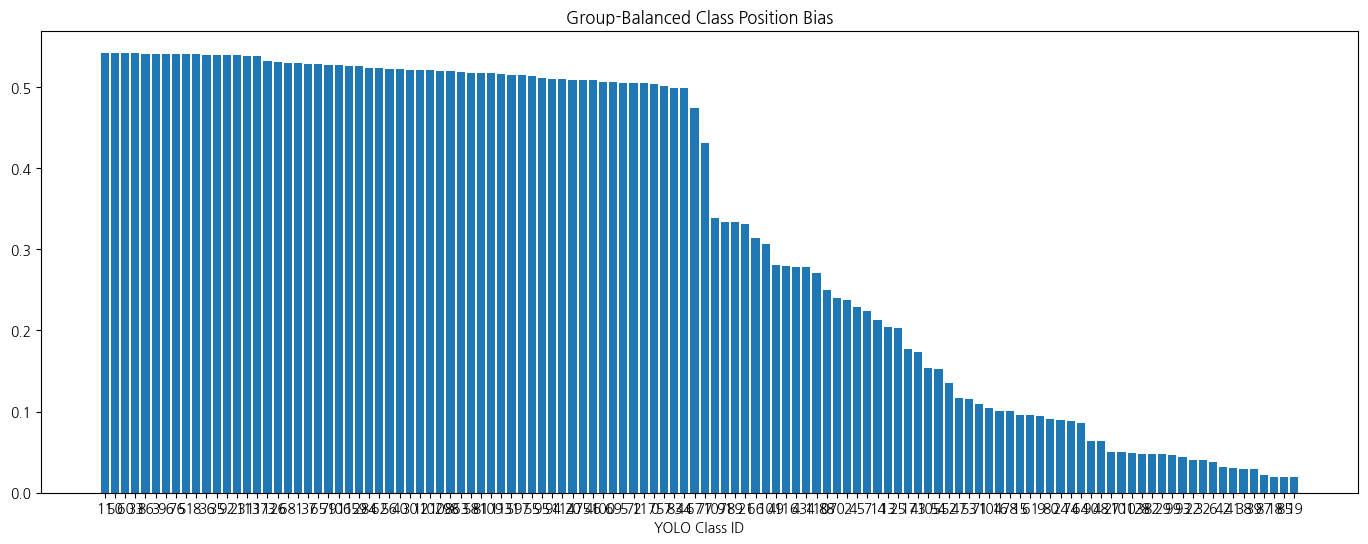

In [51]:
class_group_position_df = pd.DataFrame(class_group_position_rows)
position_rows = []
for category_id, group in class_group_position_df.groupby('category_id'):
    probabilities = np.asarray([group[f'{q}_proportion'].mean() for q in quadrants])
    nonzero = probabilities[probabilities > 0]
    entropy = float(-(nonzero * np.log(nonzero)).sum() / np.log(4)) if len(nonzero) else 0.0
    position_rows.append({
        'category_id': category_id, 'yolo_id': category_id_to_yolo[category_id],
        'class_name': category_names[category_id],
        'object_count': int(category_counter[category_id]),
        'group_count': len(group), 'quadrant_entropy_group_balanced': entropy,
        'position_bias_score_group_balanced': 1 - entropy,
        **{f'{q}_mean_proportion': float(probabilities[i]) for i, q in enumerate(quadrants)},
    })
class_position_bias_df = pd.DataFrame(position_rows).sort_values(
    'position_bias_score_group_balanced', ascending=False
)
class_position_bias_df.to_csv(REPORT_DIR / 'class_position_bias_group_balanced.csv', index=False, encoding='utf-8-sig')
reliable_position_df = class_position_bias_df[
    (class_position_bias_df.object_count >= POSITION_BIAS_MIN_OBJECTS)
    & (class_position_bias_df.group_count >= POSITION_BIAS_MIN_GROUPS)
].copy()

def weighted_cramers_v_from_group_positions(frame):
    if frame.empty:
        return float('nan')
    category_ids = sorted(frame['category_id'].unique())
    category_index = {category_id: index for index, category_id in enumerate(category_ids)}
    observed = np.zeros((len(category_ids), len(quadrants)), dtype=float)
    for row in frame.itertuples():
        for quadrant_index, quadrant in enumerate(quadrants):
            observed[category_index[row.category_id], quadrant_index] += getattr(
                row, f'{quadrant}_proportion'
            )
    if observed.size == 0 or min(observed.shape) < 2 or observed.sum() <= 0:
        return float('nan')
    expected = observed.sum(axis=1, keepdims=True) @ observed.sum(axis=0, keepdims=True) / observed.sum()
    chi2 = float(np.sum((observed - expected) ** 2 / np.maximum(expected, 1e-12)))
    phi2 = chi2 / observed.sum()
    return float(math.sqrt(phi2 / max(1, min(observed.shape[0] - 1, observed.shape[1] - 1))))


reliable_position_category_ids = set(reliable_position_df['category_id'])
reliable_group_position_source = class_group_position_df[
    class_group_position_df.category_id.isin(reliable_position_category_ids)
].copy()
group_balanced_cramers_v = weighted_cramers_v_from_group_positions(
    reliable_group_position_source
)
bootstrap_rng = np.random.default_rng(RANDOM_SEED + 404)
bootstrap_position_values = []
if not reliable_group_position_source.empty:
    rows_by_class = {
        category_id: group.copy()
        for category_id, group in reliable_group_position_source.groupby('category_id')
    }
    for _ in range(1000):
        sampled_parts = []
        for group in rows_by_class.values():
            indices = bootstrap_rng.integers(0, len(group), size=len(group))
            sampled_parts.append(group.iloc[indices])
        bootstrap_position_values.append(
            weighted_cramers_v_from_group_positions(pd.concat(sampled_parts, ignore_index=True))
        )
position_v_ci = (
    [float(value) for value in np.nanquantile(bootstrap_position_values, [0.025, 0.975])]
    if bootstrap_position_values else [None, None]
)
(REPORT_DIR / 'position_bias_summary.json').write_text(json.dumps({
    'group_balanced_cramers_v_reliable_classes': group_balanced_cramers_v,
    'bootstrap_ci95': position_v_ci,
    'reliable_class_count': len(reliable_position_df),
    'high_bias_reliable_class_count_over_0_5': int(
        (reliable_position_df.position_bias_score_group_balanced > 0.5).sum()
    ),
    'unit': 'equal weight per class-capture-group',
}, ensure_ascii=False, indent=2), encoding='utf-8')

fig, ax = plt.subplots(figsize=(17, 6))
ax.bar(
    class_position_bias_df['yolo_id'].astype(str),
    class_position_bias_df['position_bias_score_group_balanced'],
)
ax.set_title('Group-Balanced Class Position Bias')
ax.set_xlabel('YOLO Class ID')


### 검사 실행 및 결과 확인

In [52]:
# 이 셀은 바로 앞 셀에서 만든 fig/ax를 이어받아 마무리한다. 앞 셀을 건너뛰거나
# 다시 실행하면 엉뚱한 figure에 라벨이 붙거나 NameError가 나므로, 이어붙이기 전에
# 앞 셀의 figure가 살아 있는지 명시적으로 확인한다.
if 'fig' not in dir() or 'ax' not in dir():
    raise RuntimeError(
        'This cell continues the figure created in the previous cell. '
        'Run the position-bias cell directly above first.'
    )
ax.set_ylabel('1 - normalized quadrant entropy')
ax.tick_params(axis='x', rotation=90)
save_and_show(fig, '21_class_position_bias_group_balanced.png')

display(class_visual_similarity_df.head(20))

pipeline_cell_finish(16)


,category_id_a,yolo_id_a,class_name_a,group_count_a,category_id_b,yolo_id_b,class_name_b,group_count_b,appearance_distance,features_used,reliability_note
6112,77,77,엘스테인캡슐(에르도스테인),130,107,107,알바스테인캡슐(에르도스테인),128,0.136856,"relative_area,bbox_aspect_ratio,crop_brightnes...",rare/single-group classes require visual confi...
627,5,5,알드린정,156,58,58,알마겔정(알마게이트)(수출명:유한가스트라겔정),179,0.167617,"relative_area,bbox_aspect_ratio,crop_brightnes...",rare/single-group classes require visual confi...
531,4,4,무코스타정(레바미피드)(비매품),86,74,74,자이프렉사정 2.5mg,124,0.182847,"relative_area,bbox_aspect_ratio,crop_brightnes...",rare/single-group classes require visual confi...
5018,56,56,마그밀정(수산화마그네슘),180,63,63,삼남건조수산화알루미늄겔정,96,0.197614,"relative_area,bbox_aspect_ratio,crop_brightnes...",rare/single-group classes require visual confi...
5870,72,72,동화덴스톨캡슐 150mg/PTP,178,75,75,투스딘골드캡슐 150mg/PTP,177,0.205249,"relative_area,bbox_aspect_ratio,crop_brightnes...",rare/single-group classes require visual confi...
464,4,4,무코스타정(레바미피드)(비매품),86,7,7,에어탈정(아세클로페낙),114,0.237722,"relative_area,bbox_aspect_ratio,crop_brightnes...",rare/single-group classes require visual confi...
910,8,8,리렉스펜정 300mg/PTP,118,11,11,써스펜8시간이알서방정 650mg,115,0.241902,"relative_area,bbox_aspect_ratio,crop_brightnes...",rare/single-group classes require visual confi...
5254,60,60,타이레놀정500mg,133,65,65,타이레놀이알서방정(아세트아미노펜)(수출용),115,0.250651,"relative_area,bbox_aspect_ratio,crop_brightnes...",rare/single-group classes require visual confi...
5692,68,68,씨즈날정(세티리진염산염),148,83,83,지르텍정(세티리진염산염),118,0.253786,"relative_area,bbox_aspect_ratio,crop_brightnes...",rare/single-group classes require visual confi...
1285,11,11,써스펜8시간이알서방정 650mg,115,65,65,타이레놀이알서방정(아세트아미노펜)(수출용),115,0.260068,"relative_area,bbox_aspect_ratio,crop_brightnes...",rare/single-group classes require visual confi...


## 11. 그룹 기준 Train/Test domain shift — 효과크기·신뢰구간·FDR

### Train/Test 분포 차이

촬영 그룹을 통계 단위로 사용해 Train과 inference 이미지의 품질 분포 차이를 비교한다.

In [53]:
pipeline_cell_start(17, "11. Group-based Train/Test domain shift — effect size, confidence interval, and FDR")

def quality_group_id(row):
    if row.source_split == 'train':
        return get_group_id(row.file_name)
    try:
        return derive_group_id(row.file_name)
    except Exception:
        return Path(row.file_name).stem


def bootstrap_median_difference_ci(train_values, test_values, iterations=2000, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    train_values = np.asarray(train_values, dtype=float)
    test_values = np.asarray(test_values, dtype=float)
    differences = np.empty(iterations, dtype=float)
    for index in range(iterations):
        train_sample = rng.choice(train_values, size=len(train_values), replace=True)
        test_sample = rng.choice(test_values, size=len(test_values), replace=True)
        differences[index] = np.median(test_sample) - np.median(train_sample)
    return tuple(float(value) for value in np.quantile(differences, [0.025, 0.975]))


def benjamini_hochberg(pvalues):
    values = np.asarray(pvalues, dtype=float)
    adjusted = np.full(len(values), np.nan)
    valid_indices = np.where(np.isfinite(values))[0]
    if not len(valid_indices):
        return adjusted
    order = valid_indices[np.argsort(values[valid_indices])]
    ranked = values[order] * len(order) / np.arange(1, len(order) + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    adjusted[order] = np.clip(ranked, 0, 1)
    return adjusted


def circular_mean_degrees(values, weights=None, period=180.0):
    # hue는 0~180이 순환하는(180 다음이 다시 0인) 값이라 일반 산술평균을 쓰면
    # 경계 부근(예: 2와 178)에서 실제로는 가까운 값인데도 평균이 90 근처로 왜곡된다.
    # 각도로 바꿔 단위벡터로 평균낸 뒤 다시 각도로 되돌리는 순환평균을 사용한다.
    values = np.asarray(values, dtype=float)
    valid = np.isfinite(values)
    values = values[valid]
    if values.size == 0:
        return float('nan')
    angles = values / period * 2 * np.pi
    if weights is None:
        weights = np.ones_like(values)
    else:
        weights = np.asarray(weights, dtype=float)[valid]
        weights = np.clip(weights, 1e-9, None)
    angle = math.atan2(
        float(np.average(np.sin(angles), weights=weights)),
        float(np.average(np.cos(angles), weights=weights)),
    ) % (2 * np.pi)
    return float(angle / (2 * np.pi) * period)


def circular_signed_difference_degrees(angle_b, angle_a, period=180.0):
    return float((angle_b - angle_a + period / 2) % period - period / 2)


Current cell · 17/29 · 11. Group-based Train/Test domain shift — effect size, confidence interval, and FDR:   …

### Hue 분포 차이 검정

In [54]:


def circular_hue_shift_test(train_values, test_values, iterations=5000, seed=RANDOM_SEED + 1701):
    train_values = np.asarray(train_values, dtype=float)
    test_values = np.asarray(test_values, dtype=float)
    train_values = train_values[np.isfinite(train_values)]
    test_values = test_values[np.isfinite(test_values)]
    train_mean = circular_mean_degrees(train_values)
    test_mean = circular_mean_degrees(test_values)
    observed = circular_signed_difference_degrees(test_mean, train_mean)

    rng = np.random.default_rng(seed)
    bootstrap_differences = []
    for _ in range(2000):
        sampled_train = rng.choice(train_values, len(train_values), replace=True)
        sampled_test = rng.choice(test_values, len(test_values), replace=True)
        difference = circular_signed_difference_degrees(
            circular_mean_degrees(sampled_test), circular_mean_degrees(sampled_train)
        )
        bootstrap_differences.append(
            observed + circular_signed_difference_degrees(difference, observed)
        )
    ci_low, ci_high = np.quantile(bootstrap_differences, [0.025, 0.975])

    combined = np.concatenate([train_values, test_values])
    exceedances = 0
    for _ in range(iterations):
        permuted = rng.permutation(combined)
        permuted_difference = abs(circular_signed_difference_degrees(
            circular_mean_degrees(permuted[len(train_values):]),
            circular_mean_degrees(permuted[:len(train_values)]),
        ))
        exceedances += permuted_difference >= abs(observed)
    pvalue = (exceedances + 1) / (iterations + 1)
    return {
        'metric': 'hsv_hue_circular_direction',
        'period_degrees': 180.0,
        'train_group_count': len(train_values),
        'test_group_count': len(test_values),
        'train_circular_mean': train_mean,
        'test_circular_mean': test_mean,
        'circular_difference_test_minus_train': observed,
        'circular_difference_ci95_low': float(ci_low),
        'circular_difference_ci95_high': float(ci_high),
        'permutation_pvalue': float(pvalue),
        'material_shift_candidate': bool(abs(observed) >= 5.0 and pvalue < 0.05),
        'decision_rule': 'absolute circular mean difference >= 5 hue-degrees and permutation p < 0.05',
    }


image_df['quality_group_id'] = image_df.apply(quality_group_id, axis=1)
linear_quality_metrics = [
    'brightness_mean', 'contrast_std', 'blur_score',
    'hsv_h_concentration', 'hsv_s_mean', 'hsv_v_mean',
]
group_quality_rows = []
for (source_split, quality_group_id_value), group in image_df.groupby(
    ['source_split', 'quality_group_id']
):
    row = {
        'source_split': source_split,
        'quality_group_id': quality_group_id_value,
    }
    for metric in linear_quality_metrics:
        row[metric] = float(group[metric].median())
    valid_hue = group[['hsv_h_mean', 'hsv_h_concentration']].dropna()
    row['hsv_h_mean'] = (
        circular_mean_degrees(
            valid_hue['hsv_h_mean'].to_numpy(),
            valid_hue['hsv_h_concentration'].to_numpy(),
        )
        if not valid_hue.empty else np.nan
    )
    group_quality_rows.append(row)
group_quality_df = pd.DataFrame(group_quality_rows)
group_quality_df.to_csv(REPORT_DIR / 'image_quality_by_group.csv', index=False, encoding='utf-8-sig')
train_group_quality = group_quality_df[group_quality_df.source_split.eq('train')]
test_group_quality = group_quality_df[group_quality_df.source_split.eq('test')]

shift_rows = []


### Train/Test 분포 차이 요약

In [55]:
for metric_index, metric in enumerate(linear_quality_metrics):
    train_values = train_group_quality[metric].dropna().to_numpy(dtype=float)
    test_values = test_group_quality[metric].dropna().to_numpy(dtype=float)
    pooled = np.concatenate([train_values, test_values])
    pooled_iqr = float(np.quantile(pooled, 0.75) - np.quantile(pooled, 0.25))
    median_difference = float(np.median(test_values) - np.median(train_values))
    ci_low, ci_high = bootstrap_median_difference_ci(
        train_values, test_values, seed=RANDOM_SEED + metric_index
    )
    ks_statistic = ks_pvalue = np.nan
    if ks_2samp is not None:
        result = ks_2samp(train_values, test_values)
        ks_statistic, ks_pvalue = float(result.statistic), float(result.pvalue)
    shift_rows.append({
        'metric': metric,
        'train_group_count': len(train_values), 'test_group_count': len(test_values),
        'train_group_median': float(np.median(train_values)),
        'test_group_median': float(np.median(test_values)),
        'median_difference_test_minus_train': median_difference,
        'median_difference_ci95_low': ci_low, 'median_difference_ci95_high': ci_high,
        'robust_effect_median_diff_over_pooled_iqr': median_difference / max(pooled_iqr, 1e-9),
        'wasserstein_distance': (
            float(wasserstein_distance(train_values, test_values))
            if wasserstein_distance is not None else np.nan
        ),
        'ks_statistic': ks_statistic, 'ks_pvalue': ks_pvalue,
    })
group_domain_shift_df = pd.DataFrame(shift_rows)
group_domain_shift_df['ks_pvalue_fdr'] = benjamini_hochberg(group_domain_shift_df['ks_pvalue'])
group_domain_shift_df['material_shift_candidate'] = (
    group_domain_shift_df['ks_statistic'].fillna(0).ge(0.20)
    & group_domain_shift_df['ks_pvalue_fdr'].fillna(1).lt(0.05)
    & group_domain_shift_df['robust_effect_median_diff_over_pooled_iqr'].abs().ge(0.20)
)
group_domain_shift_df.to_csv(
    REPORT_DIR / 'train_test_group_aware_domain_shift.csv', index=False, encoding='utf-8-sig'
)

circular_hue_shift_df = pd.DataFrame([
    circular_hue_shift_test(
        train_group_quality['hsv_h_mean'].to_numpy(dtype=float),
        test_group_quality['hsv_h_mean'].to_numpy(dtype=float),
    )
])
circular_hue_shift_df.to_csv(
    REPORT_DIR / 'train_test_circular_hue_shift.csv', index=False, encoding='utf-8-sig'
)

test_grouping_summary = {
    'test_images': int((image_df.source_split == 'test').sum()),
    'derived_test_groups': len(test_group_quality),
    'each_test_image_is_its_own_derived_group': len(test_group_quality) == int((image_df.source_split == 'test').sum()),
    'warning': (
        'Test group independence cannot be proven from filenames alone.'
        if len(test_group_quality) == int((image_df.source_split == 'test').sum()) else None
    ),
}
(REPORT_DIR / 'test_grouping_assumption.json').write_text(
    json.dumps(test_grouping_summary, ensure_ascii=False, indent=2), encoding='utf-8'
)

for metric in linear_quality_metrics:
    fig, ax = plt.subplots(figsize=(9, 5))
    for split, frame in group_quality_df.groupby('source_split'):
        values = frame[metric].dropna()
        ax.hist(values, bins=30, density=True, alpha=0.45, label=split)
    ax.set_title(f'Group-Level {metric}: Train vs Test')
    ax.set_xlabel(metric)
    ax.set_ylabel('Density')
    ax.legend()
    save_and_show(fig, f'group_shift_{metric}.png')

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
bins = np.linspace(0, 2 * np.pi, 25)
for split, frame in group_quality_df.groupby('source_split'):
    angles = frame['hsv_h_mean'].dropna().to_numpy() / 180.0 * 2 * np.pi
    ax.hist(angles, bins=bins, density=True, alpha=0.40, label=split)
ax.set_title('Group-Level Hue Direction — Circular Distribution')
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.10))
save_and_show(fig, 'group_shift_hsv_hue_circular.png')

display(group_domain_shift_df)
display(circular_hue_shift_df)
print(json.dumps(test_grouping_summary, ensure_ascii=False, indent=2))


,metric,train_group_count,test_group_count,train_group_median,test_group_median,median_difference_test_minus_train,median_difference_ci95_low,median_difference_ci95_high,robust_effect_median_diff_over_pooled_iqr,wasserstein_distance,ks_statistic,ks_pvalue,ks_pvalue_fdr,material_shift_candidate
0,brightness_mean,4104,842,124.474767,116.060710,-8.414057,-9.477379,-7.424702,-0.304831,6.603194,0.223297,4.815424e-31,9.630848e-31,True
1,contrast_std,4104,842,19.883753,17.288718,-2.595035,-3.368199,-2.187871,-0.315981,2.017633,0.193599,2.154735e-23,3.232102e-23,False
2,blur_score,4104,842,32.961687,32.093072,-0.868615,-1.403262,0.111521,-0.136500,4.701402,0.232893,9.295168e-34,2.788551e-33,False
3,hsv_h_concentration,4104,842,0.779159,0.802779,0.023620,0.006259,0.039903,0.110381,0.029726,0.086999,4.717242e-05,4.717242e-05,False
4,hsv_s_mean,4104,842,76.998758,78.029592,1.030834,-0.201358,2.156356,0.062426,1.451953,0.098209,2.548058e-06,3.057670e-06,False
5,hsv_v_mean,4104,842,153.980637,148.292147,-5.688489,-6.283416,-4.897688,-0.365886,5.325427,0.262721,5.904308e-43,3.542585e-42,True


,metric,period_degrees,train_group_count,test_group_count,train_circular_mean,test_circular_mean,circular_difference_test_minus_train,circular_difference_ci95_low,circular_difference_ci95_high,permutation_pvalue,material_shift_candidate,decision_rule
0,hsv_hue_circular_direction,180.0,4104,842,107.333837,109.954364,2.620528,1.995024,3.204462,0.0002,False,absolute circular mean difference >= 5 hue-deg...


{
  "test_images": 842,
  "derived_test_groups": 842,
  "each_test_image_is_its_own_derived_group": true,
  "warning": "Test group independence cannot be proven from filenames alone."
}


### 검사 실행 및 결과 확인

In [56]:

pipeline_cell_finish(17)


## 12. BBox 규모·학습 해상도·각인 가독성 진단

### 객체 크기와 입력 해상도

BBox 크기 분포와 640/960 입력에서의 객체 픽셀 크기를 비교한다.

In [57]:
pipeline_cell_start(18, "12. BBox scale, training resolution, and imprint readability")

wh = bbox_df[['relative_width', 'relative_height']].to_numpy(dtype=float)
log_wh = np.log(np.clip(wh, 1e-9, None))
cluster_rows = []
best_k = None
best_silhouette = -np.inf
unique_log_wh_count = len(np.unique(log_wh, axis=0))

for k in progress(KMEANS_K_CANDIDATES, total=len(KMEANS_K_CANDIDATES), desc='Evaluate BBox KMeans candidates', unit='k'):
    if len(log_wh) <= k or unique_log_wh_count < k:
        continue
    model = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=20)
    labels = model.fit_predict(log_wh)
    if len(set(labels)) < 2:
        continue
    sample_size = min(SILHOUETTE_SAMPLE_SIZE, len(log_wh))
    score = silhouette_score(
        log_wh,
        labels,
        sample_size=sample_size if sample_size < len(log_wh) else None,
        random_state=RANDOM_SEED,
    )
    if score > best_silhouette:
        best_silhouette, best_k = score, k

if best_k is None:
    best_k = min(3, unique_log_wh_count)

kmeans_model = KMeans(n_clusters=best_k, random_state=RANDOM_SEED, n_init=30)
cluster_labels = kmeans_model.fit_predict(log_wh)
centers = np.exp(kmeans_model.cluster_centers_)
bbox_df['size_cluster'] = cluster_labels
bbox_df.to_csv(REPORT_DIR / 'bbox_analysis.csv', index=False, encoding='utf-8-sig')

for cluster_id, (relative_width, relative_height) in enumerate(centers):
    mask = cluster_labels == cluster_id
    row = {
        'cluster_id': cluster_id,
        'object_count': int(mask.sum()),
        'relative_width_center': float(relative_width),
        'relative_height_center': float(relative_height),
        'relative_area_center': float(relative_width * relative_height),
        'silhouette_selected_k': float(best_silhouette),
    }
    for imgsz in TARGET_IMAGE_SIZES:
        # 다양한 원본 종횡비를 반영하기 위해 cluster 소속 객체의 letterbox 결과 중앙값을 사용한다.
        row[f'median_width_px_at_{imgsz}'] = float(bbox_df.loc[mask, f'width_px_at_{imgsz}'].median())
        row[f'median_height_px_at_{imgsz}'] = float(bbox_df.loc[mask, f'height_px_at_{imgsz}'].median())
        row[f'median_short_side_px_at_{imgsz}'] = float(bbox_df.loc[mask, f'short_side_px_at_{imgsz}'].median())
    cluster_rows.append(row)
cluster_df = pd.DataFrame(cluster_rows).sort_values('relative_area_center')
cluster_df.to_csv(REPORT_DIR / 'bbox_scale_clusters.csv', index=False, encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(8, 7))
scatter = ax.scatter(wh[:, 0], wh[:, 1], c=cluster_labels, alpha=0.45)
ax.scatter(centers[:, 0], centers[:, 1], marker='X', s=180, edgecolors='black')
ax.set_title(f'BBox Scale Clusters (diagnostic only, k={best_k})')
ax.set_xlabel('Relative Width')
ax.set_ylabel('Relative Height')
fig.colorbar(scatter, ax=ax, label='Cluster ID')
save_and_show(fig, '22_bbox_scale_kmeans.png')

resolution_rows = []
for imgsz in progress(TARGET_IMAGE_SIZES, total=len(TARGET_IMAGE_SIZES), desc='Summarize object size by training resolution', unit='size'):
    short_side = bbox_df[f'short_side_px_at_{imgsz}']
    resolution_rows.append({
        'imgsz': imgsz,
        'calculation': 'YOLO square letterbox scale=min(imgsz/W,imgsz/H)',
        'min_short_side_px': float(short_side.min()),
        'p05_short_side_px': float(short_side.quantile(0.05)),
        'median_short_side_px': float(short_side.median()),
        'objects_under_8px': int((short_side < 8).sum()),
        'objects_under_16px': int((short_side < 16).sum()),
        'ratio_under_16px': float((short_side < 16).mean()),
    })
resolution_df = pd.DataFrame(resolution_rows)
resolution_df.to_csv(REPORT_DIR / 'target_resolution_bbox_diagnostics.csv', index=False, encoding='utf-8-sig')
print(cluster_df.to_string(index=False))
print(resolution_df.to_string(index=False))

pipeline_cell_finish(18)


Current cell · 18/29 · 12. BBox scale, training resolution, and imprint readability:   0%|          | 0/1 [  0…

Evaluate BBox KMeans candidates:   0%|          | 0/7 [00:00<?, ?k/s]

Summarize object size by training resolution:   0%|          | 0/3 [00:00<?, ?size/s]

 cluster_id  object_count  relative_width_center  relative_height_center  relative_area_center  silhouette_selected_k  median_width_px_at_640  median_height_px_at_640  median_short_side_px_at_640  median_width_px_at_960  median_height_px_at_960  median_short_side_px_at_960  median_width_px_at_1280  median_height_px_at_1280  median_short_side_px_at_1280
          0         22155               0.218059                0.161890              0.035302               0.544723              107.500002                105.00000                    99.000000              161.250003                157.50000                   148.500000               215.000005                 210.00000                    198.000000
          1         24239               0.309247                0.314849              0.097366               0.544723              150.500000                212.49984                   144.500001              225.750000                318.74976                   216.750002               30

In [58]:
# v6.0.1: 전체 세션(dill) 대신 가벼운 단계 마커만 기록한다.
if ENABLE_CHECKPOINT:
    checkpoint_payload = {
        'pipeline_version': PIPELINE_VERSION,
        'stage': 'pre_section13',
        'created_at_utc': pd.Timestamp.utcnow().isoformat(),
        'report_dir': str(REPORT_DIR),
        'source_archive_sha256': source_archive_sha256,
    }
    CHECKPOINT_PATH_S13.write_text(
        json.dumps(checkpoint_payload, ensure_ascii=False, indent=2),
        encoding='utf-8',
    )
    print(f'Lightweight checkpoint marker saved: {CHECKPOINT_PATH_S13}')


## 13. 계층화된 시각 QA — 클래스·그룹·오류·각인

### 시각 QA

BBox 위치, 클래스 외형, 그룹 일관성, 각인 가독성을 샘플 이미지로 확인한다.

In [59]:
pipeline_cell_start(19, "13. Stratified visual QA — class, group, error, and imprint")

def draw_bbox_grid(file_names, title, output_name, max_images=12, highlight_annotation_ids=None):
    if not RUN_VISUAL_QA:
        return
    selected = list(dict.fromkeys(file_names))[:max_images]
    if not selected:
        return
    highlights = set(highlight_annotation_ids or [])
    columns = 3
    rows = math.ceil(len(selected) / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(15, rows * 5))
    axes = np.atleast_1d(axes).reshape(-1)
    for ax, file_name in zip(axes, selected):
        with Image.open(train_image_map[file_name]) as image:
            ax.imshow(image_to_srgb(image))
        for annotation in effective_annotations[file_name]:
            x, y, width, height = annotation['effective_bbox']
            yolo_id = category_id_to_yolo[annotation['category_id']]
            linewidth = 4 if annotation['id'] in highlights else 2
            ax.add_patch(Rectangle((x, y), width, height, fill=False, linewidth=linewidth))
            ax.text(
                x, max(0, y - 5),
                f'{yolo_id}:{annotation["id"]} {category_names[annotation["category_id"]]}',
                fontsize=7, backgroundcolor='white',
            )
        ax.set_title(f'{file_name}\nG:{get_group_id(file_name)}', fontsize=8)
        ax.axis('off')
    for ax in axes[len(selected):]:
        ax.axis('off')
    fig.suptitle(title, fontsize=15)
    save_and_show(fig, output_name, directory=REVIEW_DIR)


def crop_with_padding(image, bbox, padding_ratio=0.12):
    x, y, width, height = map(float, bbox)
    pad_x, pad_y = width * padding_ratio, height * padding_ratio
    x1 = max(0, int(math.floor(x - pad_x)))
    y1 = max(0, int(math.floor(y - pad_y)))
    x2 = min(image.width, int(math.ceil(x + width + pad_x)))
    y2 = min(image.height, int(math.ceil(y + height + pad_y)))
    return image.crop((x1, y1, x2, y2))


def select_class_crop_rows(category_id, samples_per_class=CLASS_CROP_SAMPLES_PER_CLASS):
    candidates = bbox_df[bbox_df.category_id.eq(category_id)].sort_values(
        ['group_id', 'file_name', 'annotation_id']
    )
    selected = candidates.drop_duplicates('group_id').head(samples_per_class)
    if len(selected) < samples_per_class:
        remaining = candidates[~candidates.index.isin(selected.index)].head(samples_per_class - len(selected))
        selected = pd.concat([selected, remaining])
    return selected


Current cell · 19/29 · 13. Stratified visual QA — class, group, error, and imprint:   0%|          | 0/1 [  0%…

### 클래스별 crop 검토 시트

In [60]:


def draw_all_class_crop_contact_sheets():
    if not RUN_VISUAL_QA:
        return
    manifest_rows = []
    class_ids = sorted(original_category_ids, key=lambda c: category_id_to_yolo[c])
    for page_number, start in enumerate(range(0, len(class_ids), CLASS_CROP_CLASSES_PER_PAGE), start=1):
        page_classes = class_ids[start:start + CLASS_CROP_CLASSES_PER_PAGE]
        rows, columns = len(page_classes), CLASS_CROP_SAMPLES_PER_CLASS
        fig, axes = plt.subplots(rows, columns, figsize=(4 * columns, 3.6 * rows))
        axes = np.asarray(axes, dtype=object).reshape(rows, columns)
        for row_index, category_id in enumerate(page_classes):
            selected = select_class_crop_rows(category_id)
            for col_index in range(columns):
                ax = axes[row_index, col_index]
                if col_index >= len(selected):
                    ax.axis('off')
                    continue
                item = selected.iloc[col_index]
                with Image.open(train_image_map[item.file_name]) as image:
                    normalized = image_to_srgb(image)
                    crop = crop_with_padding(
                        normalized,
                        [item.bbox_x, item.bbox_y, item.bbox_width, item.bbox_height],
                    )
                    ax.imshow(crop)
                ax.set_title(
                    f'YOLO {int(item.yolo_id)} | cat {int(item.category_id)}\n'
                    f'{item.class_name}\n{item.file_name}\nG:{item.group_id}', fontsize=7,
                )
                ax.axis('off')
                manifest_rows.append({
                    'page': page_number, 'category_id': int(item.category_id),
                    'yolo_id': int(item.yolo_id), 'class_name': item.class_name,
                    'file_name': item.file_name, 'annotation_id': int(item.annotation_id),
                    'group_id': item.group_id,
                })
        fig.suptitle(f'All-Class Group-Diverse Crop QA — Page {page_number}', fontsize=15)
        save_and_show(fig, f'01_all_class_crops_page_{page_number:02d}.png', directory=REVIEW_DIR)
    pd.DataFrame(manifest_rows).to_csv(
        REPORT_DIR / 'all_class_crop_contact_sheet_manifest.csv', index=False, encoding='utf-8-sig'
    )


def draw_all_group_representatives(max_groups=300):
    if not RUN_VISUAL_QA:
        return
    representatives = [sorted(files)[0] for _, files in sorted(group_to_images.items())]
    # 4,104개 그룹을 전부 그리면 342페이지라 이 규모에선 사람이 다 볼 수도 없고 런타임 부담만 크다.
    # suspicious_group_ids는 별도 시트에서 확인하므로 여기서는 표본만 표시한다.
    if len(representatives) > max_groups:
        sample_rng = random.Random(RANDOM_SEED + 77)
        representatives = sorted(sample_rng.sample(representatives, max_groups))
    page_size = 12
    for page_number, start in enumerate(range(0, len(representatives), page_size), start=1):
        draw_bbox_grid(
            representatives[start:start + page_size],
            f'One Representative per Capture Group — Page {page_number}',
            f'02_all_group_representatives_page_{page_number:02d}.png',
            max_images=page_size,
        )


def simulate_target_crop(row, imgsz, display_size=240):
    with Image.open(train_image_map[row.file_name]) as image:
        normalized = image_to_srgb(image)
        crop = crop_with_padding(
            normalized, [row.bbox_x, row.bbox_y, row.bbox_width, row.bbox_height],
            padding_ratio=0.04,
        )
    scale = min(imgsz / row.image_width, imgsz / row.image_height)
    target_width = max(1, int(round(crop.width * scale)))
    target_height = max(1, int(round(crop.height * scale)))
    downscaled = crop.resize((target_width, target_height), Image.Resampling.LANCZOS)
    preview = downscaled.resize((display_size, display_size), Image.Resampling.NEAREST)
    gray = np.asarray(downscaled.convert('L'))
    edge_density = float((cv2.Canny(gray, 50, 150) > 0).mean()) if min(gray.shape) >= 3 else 0.0
    return preview, target_width, target_height, edge_density


### 각인 해상도 검토 시트

In [61]:


def draw_imprint_resolution_sheets():
    if not RUN_VISUAL_QA:
        return
    samples = [select_class_crop_rows(category_id, samples_per_class=1).iloc[0]
               for category_id in original_category_ids]
    page_size = 8
    report_rows = []
    for page_number, start in enumerate(range(0, len(samples), page_size), start=1):
        selected = samples[start:start + page_size]
        fig, axes = plt.subplots(len(selected), 2, figsize=(10, 4 * len(selected)))
        axes = np.atleast_2d(axes)
        for row_index, item in enumerate(selected):
            for col_index, imgsz in enumerate([640, 960]):
                preview, width, height, edge_density = simulate_target_crop(item, imgsz)
                axes[row_index, col_index].imshow(preview)
                axes[row_index, col_index].set_title(
                    f'YOLO {int(item.yolo_id)} {item.class_name}\n'
                    f'imgsz={imgsz}, crop≈{width}×{height}px, edge={edge_density:.3f}',
                    fontsize=8,
                )
                axes[row_index, col_index].axis('off')
                report_rows.append({
                    'category_id': int(item.category_id), 'yolo_id': int(item.yolo_id),
                    'class_name': item.class_name, 'file_name': item.file_name,
                    'annotation_id': int(item.annotation_id), 'imgsz': imgsz,
                    'simulated_crop_width': width, 'simulated_crop_height': height,
                    'edge_density': edge_density,
                })
        fig.suptitle(f'Imprint Readability: 640 vs 960 — Page {page_number}', fontsize=15)
        save_and_show(fig, f'03_imprint_resolution_page_{page_number:02d}.png', directory=REVIEW_DIR)
    pd.DataFrame(report_rows).to_csv(
        REPORT_DIR / 'imprint_resolution_diagnostics.csv', index=False, encoding='utf-8-sig'
    )


rng = random.Random(RANDOM_SEED)
annotated_names = [name for name in all_names if effective_annotations[name]]
draw_bbox_grid(
    rng.sample(annotated_names, min(SAMPLE_GRID_SIZE, len(annotated_names))),
    'Random Full-Dataset BBox Samples', '00_random_bbox_samples.png',
)
draw_all_class_crop_contact_sheets()
draw_all_group_representatives()
draw_imprint_resolution_sheets()

if applied_fix_rows:
    draw_bbox_grid(
        [row['file_name'] for row in applied_fix_rows],
        'Curated BBox Fixes Applied', '04_curated_bbox_fixes.png',
        highlight_annotation_ids=[row['annotation_id'] for row in applied_fix_rows],
    )
if not cross_class_conflict_df.empty:
    conflict_ids = set(cross_class_conflict_df.annotation_id_a) | set(cross_class_conflict_df.annotation_id_b)
    draw_bbox_grid(
        cross_class_conflict_df.file_name.tolist(),
        'Cross-Class High-IoU Conflicts', '05_cross_class_conflicts.png',
        max_images=24, highlight_annotation_ids=conflict_ids,
    )
shape_candidates = bbox_df[bbox_df.group_shape_outlier]
draw_bbox_grid(
    shape_candidates.file_name.tolist(),
    'Class-Group Shape Outliers', '06_group_shape_outliers.png',
    max_images=24, highlight_annotation_ids=shape_candidates.annotation_id.tolist(),
)
for group_id in suspicious_group_ids:
    draw_bbox_grid(
        group_to_images[group_id], f'Suspicious Capture Group: {group_id}',
        f'07_suspicious_group_{group_id}.png', max_images=12,
    )

pipeline_cell_finish(19)


### 중복 후보 검토 현황

중복 의심 이미지 쌍과 미해결 검토 항목을 함께 확인한다.

In [62]:
pipeline_cell_start(20, "13. Stratified visual QA — class, group, error, and imprint")

def draw_duplicate_pair_pages(candidate_df, output_stem, exact=False, max_pairs_per_page=12):
    # "정상 동작 확인"용 실행에서는 그림을 그리지 않는다 (manual_review_df 계산에는 영향 없음).
    if not RUN_VISUAL_QA:
        return
    if candidate_df.empty:
        return
    for page_index, start in enumerate(range(0, len(candidate_df), max_pairs_per_page), start=1):
        selected = candidate_df.iloc[start:start + max_pairs_per_page]
        fig, axes = plt.subplots(len(selected), 2, figsize=(12, len(selected) * 4))
        axes = np.atleast_2d(axes)
        for row_index, row in enumerate(selected.itertuples()):
            for col_index, (path_value, source_value, file_value) in enumerate([
                (row.path_a, row.source_a, row.file_a),
                (row.path_b, row.source_b, row.file_b),
            ]):
                with Image.open(path_value) as image:
                    axes[row_index, col_index].imshow(image_to_srgb(image))
                axes[row_index, col_index].set_title(f'{source_value}: {file_value}', fontsize=8)
                axes[row_index, col_index].axis('off')
            if exact:
                label = f'exact SHA-256\n{row.pair_scope}'
            else:
                label = (
                    f'dHash={row.dhash_distance} pHash={row.phash_distance}\n'
                    f'SSIM={row.local_ssim:.3f} focus={row.focus_ssim:.3f}\n'
                    f'ORB={row.orb_match_ratio:.3f} {row.pair_scope}'
                )
            axes[row_index, 0].set_ylabel(label, fontsize=8)
        fig.suptitle(f'Duplicate Review — Page {page_index}', fontsize=15)
        save_and_show(fig, f'{output_stem}_page_{page_index:02d}.png', directory=REVIEW_DIR)


draw_duplicate_pair_pages(
    selected_review_df.sort_values(['pair_scope', 'local_ssim'], ascending=[True, False]),
    '08_near_duplicate_review', exact=False,
)
draw_duplicate_pair_pages(
    exact_duplicate_df.loc[exact_duplicate_df.requires_manual_review.astype(bool)],
    '09_exact_duplicate_review', exact=True,
)

manual_review_df = flush_review_items()

# 규칙 기반 판정 결과와 검토 방식을 note에 기록한다.
if AUTO_REVIEW_POLICY_ENABLED:
    auto_review_timestamp = pd.Timestamp.utcnow().isoformat()
    auto_review_notes = {
        'class_group_shape_outlier': (
            'auto-policy: bbox/class-id/coordinate validation passed; shape z-score outlier kept '
            'to preserve rare and edge-case samples; no visual review'
        ),
        'suspicious_group': (
            'auto-policy: group_id sourced from split_manifest.csv; train/val group leakage is '
            'verified separately by the export gate; not a blocker under the preserved pre-split '
            'structure; no visual review'
        ),
        'cross_class_bbox_conflict': (
            'auto-policy: NOT visually reviewed; label-noise risk retained in the dataset and '
            'listed in training_exclusion_candidates.csv for downstream filtering'
        ),
    }
    pending_mask = manual_review_df['decision'].isin(['', 'pending'])
    for issue_type, auto_note in auto_review_notes.items():
        target_mask = pending_mask & manual_review_df['issue_type'].eq(issue_type)
        manual_review_df.loc[target_mask, 'decision'] = 'acceptable'
        manual_review_df.loc[target_mask, 'reviewer'] = AUTO_REVIEW_REVIEWER
        manual_review_df.loc[target_mask, 'reviewed_at'] = auto_review_timestamp
        manual_review_df.loc[target_mask, 'note'] = auto_note
    manual_review_df.to_csv(MANUAL_REVIEW_DECISIONS_PATH, index=False, encoding='utf-8-sig')
    manual_review_df.to_csv(
        REPORT_DIR / 'manual_review_decisions_snapshot.csv', index=False, encoding='utf-8-sig'
    )

# cross_class_bbox_conflict 이미지는 계약(12,196/46,394/4,104)을 지키기 위해 export에 그대로 포함한다.
# 대신 학습팀이 loader 단계에서 제외할 수 있도록 대상 목록만 별도 파일로 전달한다.
auto_approved_review_count = int(manual_review_df['reviewer'].eq(AUTO_REVIEW_REVIEWER).sum())
conflict_review_df = manual_review_df[manual_review_df['issue_type'].eq('cross_class_bbox_conflict')]
exclusion_file_names = sorted({
    str(name) for name in conflict_review_df['file_a'] if str(name).strip()
})
training_exclusion_df = pd.DataFrame({
    'file_name': exclusion_file_names,
    'reason': ['cross_class_bbox_conflict'] * len(exclusion_file_names),
    'split': [file_split_lookup.get(name, '') for name in exclusion_file_names],
})
training_exclusion_df.to_csv(
    REPORT_DIR / 'training_exclusion_candidates.csv', index=False, encoding='utf-8-sig'
)
manual_review_df['resolved'] = manual_review_df.apply(
    lambda row: review_resolution(row.to_dict()), axis=1
)
blocking_mask = manual_review_df['blocking'].astype(str).str.lower().isin({'true', '1'})
blocking_unresolved_df = manual_review_df[blocking_mask & ~manual_review_df['resolved']].copy()
all_unresolved_df = manual_review_df[~manual_review_df['resolved']].copy()
blocking_unresolved_df.to_csv(
    REPORT_DIR / 'blocking_manual_reviews_unresolved.csv', index=False, encoding='utf-8-sig'
)
all_unresolved_df.to_csv(
    REPORT_DIR / 'all_manual_reviews_unresolved.csv', index=False, encoding='utf-8-sig'
)
review_summary_df = (
    manual_review_df.groupby(['issue_type', 'blocking', 'decision', 'resolved'])
    .size().reset_index(name='count')
)
review_summary_df.to_csv(REPORT_DIR / 'manual_review_summary.csv', index=False, encoding='utf-8-sig')

print(f'Manual review rows: {len(manual_review_df):,}')
print(f'Blocking unresolved: {len(blocking_unresolved_df):,}')
display(review_summary_df)
print(f'Auto-approved review items: {auto_approved_review_count:,}')
print(f'Training exclusion candidates: {len(training_exclusion_df):,}')
print(f'Edit decisions: {MANUAL_REVIEW_DECISIONS_PATH}')

pipeline_cell_finish(20)


Current cell · 20/29 · 13. Stratified visual QA — class, group, error, and imprint:   0%|          | 0/1 [  0%…

Manual review rows: 1,061
Blocking unresolved: 0


,issue_type,blocking,decision,resolved,count
0,class_group_shape_outlier,False,acceptable,True,281
1,class_group_shape_outlier,True,acceptable,True,262
2,cross_class_bbox_conflict,True,acceptable,True,74
3,suspicious_group,True,acceptable,True,152
4,train_cross_group_near_duplicate,False,pending,False,292


Auto-approved review items: 769
Training exclusion candidates: 74
Edit decisions: /content/drive/.shortcut-targets-by-id/1-q0vCVWkBCyN2b_GXl4ViaIWoPix1-Mv/baby_kangaroo/week2/데이터전처리/yolo_전처리/manual_review_decisions_v6_0.csv


## 수동 검토 도우미

자동 검토 정책을 사용하지 않는 경우 Audit 결과를 확인하고 `manual_review_decisions_v6_0.csv`에 개별 판정을 기록할 수 있다.

사용 함수:
- `show_remaining_blocking_reviews()`: 미해결 항목 확인
- `save_review_decision(...)`: 검토 결과 기록

`approved`와 `acceptable`만 해결된 항목으로 처리한다.

### 검토 이미지 경로 정리

노트북 안에서 검토 이미지를 보고 승인·수정·제외 결정을 기록할 수 있게 한다.

In [63]:
from datetime import datetime
from zoneinfo import ZoneInfo


def _review_paths():
    review_csv = WORKSPACE_ROOT / "manual_review_decisions_v6_0.csv"
    audit_root = WORKSPACE_ROOT / "pill_yolo_full_v6_0_preprocessed_audit"
    review_dir = audit_root / "review_montages"
    report_dir = audit_root / "reports"
    return review_csv, review_dir, report_dir


def show_audit_review():
    """Show current Audit blockers and key BBox review images."""
    review_csv, review_dir, report_dir = _review_paths()
    unresolved_path = report_dir / "blocking_manual_reviews_unresolved.csv"

    if not review_csv.exists():
        print("manual_review_decisions_v6_0.csv was not found. Run the notebook in audit mode first.")
        return pd.DataFrame()

    if unresolved_path.exists():
        blocking_df = pd.read_csv(unresolved_path, dtype=str).fillna("")
    else:
        review_df = pd.read_csv(review_csv, dtype=str).fillna("")
        blocking_mask = review_df["blocking"].str.lower().isin({"true", "1"})
        blocking_df = review_df.loc[blocking_mask].copy()

    display_columns = [
        column for column in [
            "issue_type", "issue_id", "file_a", "file_b",
            "annotation_id_a", "annotation_id_b", "suggested_action",
            "decision", "reviewer", "reviewed_at", "note", "evidence",
        ]
        if column in blocking_df.columns
    ]

    print(f"Blocking review items: {len(blocking_df)} item(s)")
    if len(blocking_df):
        display(blocking_df[display_columns])

    primary_montages = [
        review_dir / "04_curated_bbox_fixes.png",
        review_dir / "05_cross_class_conflicts.png",
    ]
    for montage_path in primary_montages:
        if montage_path.exists():
            print(f"\nReview image: {montage_path}")
            with Image.open(montage_path) as image:
                display(image.copy())

    extra_patterns = [
        "06_group_shape_outliers*.png",
        "07_suspicious_group_*.png",
        "09_exact_duplicate_review_*.png",
    ]
    extra_paths = sorted({
        path
        for pattern in extra_patterns
        for path in review_dir.glob(pattern)
    })
    if extra_paths:
        print("\nAdditional review images:")
        for path in extra_paths:
            print(" -", path)

    print("\nDecision file:", review_csv)
    return blocking_df


### 미해결 검토 항목 확인

In [64]:


def show_remaining_blocking_reviews():
    """Show blocking items that remain after decisions and review metadata are recorded."""
    review_csv, _, _ = _review_paths()
    if not review_csv.exists():
        raise FileNotFoundError(f"Review CSV not found: {review_csv}")

    review_df = pd.read_csv(review_csv, dtype=str).fillna("")
    blocking_mask = review_df["blocking"].str.lower().isin({"true", "1"})
    resolved_mask = (
        review_df["decision"].isin({"approved", "acceptable"})
        & review_df["reviewer"].str.strip().ne("")
        & review_df["reviewed_at"].str.strip().ne("")
        & review_df["note"].str.strip().ne("")
    )
    remaining_df = review_df.loc[blocking_mask & ~resolved_mask].copy()

    print(f"Remaining blocking items: {len(remaining_df)} item(s)")
    if len(remaining_df):
        columns = [
            column for column in [
                "issue_type", "issue_id", "file_a", "annotation_id_a",
                "annotation_id_b", "decision", "suggested_action", "note",
            ]
            if column in remaining_df.columns
        ]
        display(remaining_df[columns])
    else:
        print("Manual review is complete. Restart the runtime and run all cells in release mode.")
    return remaining_df


def save_review_decision(issue_type, issue_id, decision, note, reviewer):
    """Find exactly one item by issue_type and issue_id, then save the reviewer decision."""
    valid_decisions = {
        "approved", "acceptable", "needs_relabel",
        "needs_regroup", "rejected", "confirmed_duplicate",
    }
    if decision not in valid_decisions:
        raise ValueError(f"Unsupported decision: {decision}")
    if not str(reviewer).strip():
        raise ValueError("Enter reviewer.")
    if not str(note).strip():
        raise ValueError("Enter a note explaining the decision.")

    review_csv, _, _ = _review_paths()
    if not review_csv.exists():
        raise FileNotFoundError(f"Review CSV not found: {review_csv}")

    review_df = pd.read_csv(review_csv, dtype=str).fillna("")
    mask = (
        review_df["issue_type"].eq(str(issue_type))
        & review_df["issue_id"].eq(str(issue_id))
    )
    if int(mask.sum()) != 1:
        raise ValueError(
            "Expected exactly one matching review item: "
            f"{issue_type!r}, {issue_id!r}"
        )

    review_df.loc[mask, "decision"] = decision
    review_df.loc[mask, "reviewer"] = str(reviewer).strip()
    review_df.loc[mask, "reviewed_at"] = datetime.now(
        ZoneInfo("Asia/Seoul")
    ).isoformat()
    review_df.loc[mask, "note"] = str(note).strip()
    review_df.to_csv(review_csv, index=False, encoding="utf-8-sig")

    print(f"Saved: {issue_type} / {issue_id} -> {decision}")
    return show_remaining_blocking_reviews()


### 검사 실행 및 결과 확인

In [65]:


# 수동 검토가 필요한 경우 아래 형식으로 결과를 기록한다.
# save_review_decision(
#     issue_type="cross_class_bbox_conflict",
#     issue_id="issue_id",
#     decision="acceptable",
#     note="검토 근거",
#     reviewer="reviewer_name",
# )

if BUILD_MODE == "audit":
    show_audit_review()
else:
    print("Release mode is active. The review helper does not change decisions automatically.")


Release mode is active. The review helper does not change decisions automatically.


## 14. YOLO 좌표·반올림 경계 검증

### YOLO 좌표 정밀도 확인

YOLO 텍스트 라벨로 저장한 뒤 좌표 범위와 COCO↔YOLO 왕복 오차를 다시 확인한다.

In [66]:
pipeline_cell_start(21, "14. YOLO coordinate and rounding-boundary validation")

max_round_trip_error = float(pd.DataFrame(round_trip_rows).max_abs_error.max())
rounded_edge_failures = []
for file_name, annotations in effective_annotations.items():
    width, height = actual_image_sizes[file_name]
    for annotation in annotations:
        coordinates = convert_bbox_to_yolo(annotation['effective_bbox'], width, height)
        rounded = tuple(float(f'{value:.6f}') for value in coordinates)
        try:
            validate_yolo_coordinates(rounded, f'rounded:{file_name}:{annotation["id"]}')
        except Exception as exc:
            rounded_edge_failures.append({
                'file_name': file_name, 'annotation_id': annotation['id'], 'error': repr(exc),
            })
write_csv_with_schema(
    rounded_edge_failures, ['file_name', 'annotation_id', 'error'],
    REPORT_DIR / 'rounded_yolo_edge_failures.csv',
)
if rounded_edge_failures:
    raise ValueError(f'Rounded YOLO edge failures: {len(rounded_edge_failures)}')
print(f'YOLO coordinate checks passed. max round-trip error={max_round_trip_error:.3e}')

pipeline_cell_finish(21)


Current cell · 21/29 · 14. YOLO coordinate and rounding-boundary validation:   0%|          | 0/1 [  0%]

YOLO coordinate checks passed. max round-trip error=1.137e-13


## 15. Sample submission·export 사전 품질 게이트

### export 사전 점검

데이터 계약, 검토 상태, 이미지 방향, sample submission 형식을 확인한 뒤 export 단계로 넘어간다.

In [67]:
pipeline_cell_start(22, "15. Sample submission and final pre-export quality gate")

# Drive 전체를 rglob으로 훑으면 셀이 멈춘 것처럼 오래 걸린다.
# 로컬 캐시(PROJECT_ROOT)만 재귀 탐색하고, Drive 경로는 한 단계만 확인한다.
if SAMPLE_SUBMISSION_PATH is not None:
    sample_submission_candidates = [Path(SAMPLE_SUBMISSION_PATH)]
else:
    def _is_sample_submission(path):
        name = path.name.lower()
        return 'sample' in name and 'submission' in name

    sample_submission_candidates = sorted({
        path.resolve()
        for path in list(Path(PROJECT_ROOT).rglob('*.csv')) + list(Path(WORKSPACE_ROOT).glob('*.csv'))
        if _is_sample_submission(path)
    }) if Path(PROJECT_ROOT).exists() else []

submission_report = {
    'candidate_files': [str(path) for path in sample_submission_candidates],
    'test_image_count': len(test_image_files),
    'mapping_round_trip_valid': all(
        yolo_to_category_id[category_id_to_yolo[c]] == c for c in original_category_ids
    ),
}
if sample_submission_candidates:
    sample_path = sample_submission_candidates[0]
    sample_df = pd.read_csv(sample_path)
    test_names = set(test_image_map)
    candidate_image_columns = []
    for column in sample_df.columns:
        values = set(sample_df[column].dropna().astype(str))
        overlap = len(values & test_names)
        if overlap:
            candidate_image_columns.append({
                'column': column, 'matching_test_file_names': overlap,
                'match_ratio_vs_test': overlap / max(1, len(test_names)),
            })
    submission_report.update({
        'selected_file': str(sample_path), 'row_count': len(sample_df),
        'columns': sample_df.columns.tolist(),
        'dtypes': {column: str(dtype) for column, dtype in sample_df.dtypes.items()},
        'duplicate_full_rows': int(sample_df.duplicated().sum()),
        'null_count_by_column': sample_df.isna().sum().astype(int).to_dict(),
        'row_count_equals_test_image_count': len(sample_df) == len(test_image_files),
        'candidate_image_columns': candidate_image_columns,
    })
    sample_df.head(20).to_csv(REPORT_DIR / 'sample_submission_preview.csv', index=False, encoding='utf-8-sig')
else:
    submission_report['note'] = 'Sample submission CSV not found; no output schema was guessed.'
(REPORT_DIR / 'sample_submission_report.json').write_text(
    json.dumps(submission_report, ensure_ascii=False, indent=2), encoding='utf-8'
)
sample_found = bool(submission_report.get('selected_file'))

raw_copy_orientation_blockers = train_image_df[
    train_image_df['orientation_changed'].astype(bool)
].copy()


Current cell · 22/29 · 15. Sample submission and final pre-export quality gate:   0%|          | 0/1 [  0%]

### export 사전 점검 결과

In [68]:
# 기존 Train/Validation split이 실제 capture group 경계를 지키는지 명시적으로 검증한다.
cross_source_duplicate_unresolved = int(
    all_unresolved_df['issue_type'].isin(
        {'cross_source_exact_duplicate', 'cross_source_near_duplicate'}
    ).sum()
) if not all_unresolved_df.empty else 0

group_split_leak_rows = []
for group_id, files in group_to_images.items():
    splits = sorted({file_split_lookup[file_name] for file_name in files})
    if len(splits) > 1:
        group_split_leak_rows.append({
            'group_id': group_id,
            'splits': ','.join(splits),
            'image_count': len(files),
            'sample_files': ' | '.join(sorted(files)[:10]),
        })
group_split_leak_df = pd.DataFrame(
    group_split_leak_rows,
    columns=['group_id', 'splits', 'image_count', 'sample_files'],
)
group_split_leak_df.to_csv(
    REPORT_DIR / 'train_val_group_leakage.csv',
    index=False,
    encoding='utf-8-sig',
)


prebuild_rows = [
    {'check': 'Source and annotation files exist', 'status': 'PASS', 'value': len(required_dirs)},
    {'check': 'Expected labeled image count', 'status': 'PASS' if len(all_names) == EXPECTED_LABELED_IMAGE_COUNT else 'FAIL', 'value': len(all_names)},
    {'check': 'Expected object count', 'status': 'PASS' if len(bbox_df) == EXPECTED_OBJECT_COUNT else 'FAIL', 'value': len(bbox_df)},
    {'check': 'Expected capture group count', 'status': 'PASS' if len(group_to_images) == EXPECTED_CAPTURE_GROUP_COUNT else 'FAIL', 'value': len(group_to_images)},
    # preprocess_image_for_export()가 ImageOps.exif_transpose로 방향을 정규화한 뒤 960x960으로
    # 다시 인코딩하므로 EXIF orientation>1 이미지도 좌표계가 이미 일치한다. 실제 문제가 아니므로
    # release를 막는 FAIL 대신 진단용 REVIEW로 표시한다.
    {'check': 'Source images with EXIF orientation (normalized during export)', 'status': 'PASS' if raw_copy_orientation_blockers.empty else 'REVIEW', 'value': len(raw_copy_orientation_blockers)},
    {'check': 'Corrupt/color-profile-invalid images', 'status': 'PASS' if corrupt_df.empty else 'FAIL', 'value': len(corrupt_df)},
    {'check': 'Image metadata size mismatches', 'status': 'PASS' if not size_mismatch_rows else 'FAIL', 'value': len(size_mismatch_rows)},
    {'check': 'Uncurated invalid BBoxes', 'status': 'PASS' if not uncurated_invalid_rows else 'FAIL', 'value': len(uncurated_invalid_rows)},
    # 763 결정: IntegratedDataset은 base 232장을 curated fix 적용 전 원본으로 병합했고
    # 파일명에도 base__ 접두사가 붙어 legacy fix가 구조적으로 매칭 불가하다. REQUIRE_ALL_CURATED_FIXES와 판정을 일치시킨다.
    {'check': 'Curated known BBox fixes applied (N/A for pre-curation base data)', 'status': 'PASS' if (not missing_curated_fix_ids or not REQUIRE_ALL_CURATED_FIXES) else 'FAIL', 'value': len(applied_fix_rows)},
    {'check': 'All expected classes preserved', 'status': 'PASS' if len(original_category_ids) == EXPECTED_CLASS_COUNT else 'FAIL', 'value': len(original_category_ids)},
    {'check': 'Original filenames preserved', 'status': 'PASS' if full_dataset_contract_df.original_name_preserved.all() else 'FAIL', 'value': int(full_dataset_contract_df.original_name_preserved.sum())},
    {
        'check': 'No manual group overrides in release',
        'status': (
            'PASS' if group_override_df.empty
            else ('REVIEW' if BUILD_MODE == 'audit' else 'FAIL')
        ),
        'value': len(group_override_df),
    },
    {'check': 'Existing Train/Validation split preserved', 'status': 'PASS', 'value': True},
    {'check': 'No capture group crosses Train/Validation', 'status': 'PASS' if group_split_leak_df.empty else 'FAIL', 'value': len(group_split_leak_df)},
    {'check': 'Near-duplicate candidate enumeration complete', 'status': 'PASS' if near_duplicate_scan_complete else 'REVIEW', 'value': near_duplicate_scan_complete},
    {'check': 'Relevant high-priority duplicates omitted from review', 'status': 'PASS' if unregistered_relevant_high_priority == 0 else 'REVIEW', 'value': unregistered_relevant_high_priority},
    {'check': 'Low-priority cross-source duplicate candidates documented', 'status': 'REVIEW' if len(low_priority_cross_source_df) else 'PASS', 'value': len(low_priority_cross_source_df)},
    {
        'check': 'Blocking manual reviews resolved with reviewer/time/note',
        'status': 'PASS' if blocking_unresolved_df.empty else ('REVIEW' if BUILD_MODE == 'audit' else 'FAIL'),
        'value': len(blocking_unresolved_df),
    },
    {
        'check': 'Sample submission schema inspected',
        'status': (
            'PASS' if sample_found
            else ('FAIL' if (REQUIRE_SAMPLE_SUBMISSION_FOR_RELEASE and BUILD_MODE == 'release') else 'REVIEW')
        ),
        'value': sample_found,
    },
    {
        'check': 'Cross-source duplicate reviews resolved',
        'status': (
            'PASS' if cross_source_duplicate_unresolved == 0
            else ('FAIL' if (REQUIRE_CROSS_SOURCE_DUPLICATE_REVIEW_FOR_RELEASE and BUILD_MODE == 'release') else 'REVIEW')
        ),
        'value': cross_source_duplicate_unresolved,
    },
]
prebuild_gate_df = pd.DataFrame(prebuild_rows)
prebuild_gate_df.to_csv(REPORT_DIR / 'prebuild_quality_gate.csv', index=False, encoding='utf-8-sig')
fatal_prebuild_failures = prebuild_gate_df[prebuild_gate_df.status.eq('FAIL')]
export_allowed = BUILD_MODE == 'release' and fatal_prebuild_failures.empty

print(prebuild_gate_df.to_string(index=False))
if BUILD_MODE == 'audit':
    print('\n[AUDIT MODE] Review artifacts created. The final training directory was not created.')
elif not fatal_prebuild_failures.empty:
    raise RuntimeError(
        'Release export blocked. Check prebuild_quality_gate.csv and manual_review_decisions_v6_0.csv.\n'
        + fatal_prebuild_failures.to_string(index=False)
    )
else:
    print('Release prebuild gate passed. Pre-split dataset export is allowed.')

pipeline_cell_finish(22)


                                                            check status value
                                Source and annotation files exist   PASS     8
                                     Expected labeled image count   PASS 12196
                                            Expected object count   PASS 46394
                                     Expected capture group count   PASS  4104
   Source images with EXIF orientation (normalized during export)   PASS     0
                             Corrupt/color-profile-invalid images   PASS     0
                                   Image metadata size mismatches   PASS     0
                                         Uncurated invalid BBoxes   PASS     0
Curated known BBox fixes applied (N/A for pre-curation base data)   PASS     0
                                   All expected classes preserved   PASS   118
                                     Original filenames preserved   PASS 12196
                             No manual group overrid

## 16. 사전 분할 YOLO 데이터셋 생성 — `images/{train,val}`, `labels/{train,val}`

### YOLO 데이터셋 staging

검증된 이미지와 라벨을 staging 경로에 만들고 기존 Train/Validation 하위 구조를 유지한다.

In [69]:
pipeline_cell_start(23, "16. Create the pre-split YOLO dataset — preserve `train/val` structure")

# 공통 실제 이미지 전처리 정책
PREPROCESS_TARGET_SIZE = int(os.getenv('PILL_PREPROCESS_TARGET_SIZE', '960'))
PREPROCESS_DENOISE_DIAMETER = int(os.getenv('PILL_DENOISE_DIAMETER', '5'))
PREPROCESS_DENOISE_SIGMA_COLOR = float(os.getenv('PILL_DENOISE_SIGMA_COLOR', '20'))
PREPROCESS_DENOISE_SIGMA_SPACE = float(os.getenv('PILL_DENOISE_SIGMA_SPACE', '20'))
PREPROCESS_WHITE_BALANCE_GAIN_LIMIT = float(os.getenv('PILL_WB_GAIN_LIMIT', '0.05'))
PREPROCESS_CLAHE_CLIP_LIMIT = float(os.getenv('PILL_CLAHE_CLIP_LIMIT', '1.5'))
PREPROCESS_CLAHE_GRID = (8, 8)

if PREPROCESS_TARGET_SIZE < 512 or PREPROCESS_TARGET_SIZE % 32:
    raise ValueError('PILL_PREPROCESS_TARGET_SIZE must be >=512 and divisible by 32.')
if PREPROCESS_DENOISE_DIAMETER <= 0 or PREPROCESS_DENOISE_DIAMETER % 2 == 0:
    raise ValueError('PILL_DENOISE_DIAMETER must be a positive odd integer.')
if not 0.0 <= PREPROCESS_WHITE_BALANCE_GAIN_LIMIT <= 0.15:
    raise ValueError('PILL_WB_GAIN_LIMIT must be between 0.0 and 0.15.')

PREPROCESSING_CONFIG = {
    'order': [
        'EXIF orientation normalization',
        'ICC-aware sRGB conversion',
        'edge-preserving bilateral denoising',
        'clipped gray-world white balance',
        'LAB luminance CLAHE',
        'aspect-ratio-preserving letterbox resize',
    ],
    'target_size': [PREPROCESS_TARGET_SIZE, PREPROCESS_TARGET_SIZE],
    'denoise': {
        'method': 'cv2.bilateralFilter',
        'diameter': PREPROCESS_DENOISE_DIAMETER,
        'sigma_color': PREPROCESS_DENOISE_SIGMA_COLOR,
        'sigma_space': PREPROCESS_DENOISE_SIGMA_SPACE,
    },
    'color_correction': {
        'white_balance': 'gray_world_with_clipped_channel_gains',
        'gain_limit': PREPROCESS_WHITE_BALANCE_GAIN_LIMIT,
        'luminance_equalization': 'CLAHE_on_LAB_L_only',
        'clahe_clip_limit': PREPROCESS_CLAHE_CLIP_LIMIT,
        'clahe_grid': list(PREPROCESS_CLAHE_GRID),
    },
    'letterbox_padding': 'median RGB of the corrected image border',
    'bbox_policy': 'scale and pad xywh; validate inside 960x960 canvas',
}

AUGMENTATION_POLICY = {
    'scope': 'Train split only; never Validation/Test',
    'offline_augmented_copies_per_train_image': 2,
    'geometric': {
        'affine_probability': 0.85,
        'rotation_degrees': [-15, 15],
        'translate_percent': [-0.08, 0.08],
        'scale': [0.90, 1.10],
        'shear_degrees': [-3, 3],
        'horizontal_flip_probability': 0.50,
        'vertical_flip_probability': 0.50,
    },
    'photometric': {
        'brightness_contrast_probability': 0.35,
        'brightness_limit': 0.10,
        'contrast_limit': 0.10,
        'hsv_probability': 0.25,
        'hue_shift_limit': 3,
        'saturation_shift_limit': 10,
        'value_shift_limit': 10,
        'gaussian_noise_probability': 0.12,
        'gaussian_blur_probability': 0.08,
    },
    'bbox_safety': {'format': 'pascal_voc', 'min_visibility': 0.40, 'min_area_px': 16},
    'reproducibility': {'seed': int(RANDOM_SEED)},
}


def _border_median_rgb(rgb_array, border_fraction=0.04):
    height, width = rgb_array.shape[:2]
    thickness = max(1, int(round(min(height, width) * border_fraction)))
    border_pixels = np.concatenate([
        rgb_array[:thickness].reshape(-1, 3),
        rgb_array[-thickness:].reshape(-1, 3),
        rgb_array[:, :thickness].reshape(-1, 3),
        rgb_array[:, -thickness:].reshape(-1, 3),
    ], axis=0)
    return np.median(border_pixels, axis=0).round().clip(0, 255).astype(np.uint8)


def _clipped_gray_world_white_balance(rgb_array):
    work = rgb_array.astype(np.float32)
    channel_means = work.reshape(-1, 3).mean(axis=0)
    gray_mean = float(channel_means.mean())
    raw_gains = gray_mean / np.maximum(channel_means, 1.0)
    low, high = 1.0 - PREPROCESS_WHITE_BALANCE_GAIN_LIMIT, 1.0 + PREPROCESS_WHITE_BALANCE_GAIN_LIMIT
    gains = np.clip(raw_gains, low, high)
    balanced = np.clip(work * gains.reshape(1, 1, 3), 0, 255).astype(np.uint8)
    return balanced, gains


def _clahe_luminance_only(rgb_array):
    lab = cv2.cvtColor(rgb_array, cv2.COLOR_RGB2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)
    clahe = cv2.createCLAHE(
        clipLimit=PREPROCESS_CLAHE_CLIP_LIMIT,
        tileGridSize=PREPROCESS_CLAHE_GRID,
    )
    enhanced_l = clahe.apply(l_channel)
    return cv2.cvtColor(cv2.merge((enhanced_l, a_channel, b_channel)), cv2.COLOR_LAB2RGB)


def _save_rgb_image(rgb_array, destination):
    destination = Path(destination)
    image = Image.fromarray(rgb_array, mode='RGB')
    suffix = destination.suffix.lower()
    if suffix in {'.jpg', '.jpeg'}:
        image.save(destination, format='JPEG', quality=95, subsampling=0)
    elif suffix == '.png':
        image.save(destination, format='PNG', compress_level=3)
    else:
        image.save(destination)


def preprocess_image_for_export(source, destination):
    source, destination = Path(source), Path(destination)
    with Image.open(source) as raw_image:
        rgb_image = image_to_srgb(raw_image)
        rgb = np.asarray(rgb_image, dtype=np.uint8)

    source_height, source_width = rgb.shape[:2]
    denoised = cv2.bilateralFilter(
        rgb,
        d=PREPROCESS_DENOISE_DIAMETER,
        sigmaColor=PREPROCESS_DENOISE_SIGMA_COLOR,
        sigmaSpace=PREPROCESS_DENOISE_SIGMA_SPACE,
    )
    white_balanced, wb_gains = _clipped_gray_world_white_balance(denoised)
    corrected = _clahe_luminance_only(white_balanced)

    nominal_scale = min(
        PREPROCESS_TARGET_SIZE / source_width,
        PREPROCESS_TARGET_SIZE / source_height,
    )
    resized_width = max(1, int(round(source_width * nominal_scale)))
    resized_height = max(1, int(round(source_height * nominal_scale)))
    interpolation = cv2.INTER_AREA if nominal_scale < 1.0 else cv2.INTER_LANCZOS4
    resized = cv2.resize(corrected, (resized_width, resized_height), interpolation=interpolation)

    pad_left = (PREPROCESS_TARGET_SIZE - resized_width) // 2
    pad_top = (PREPROCESS_TARGET_SIZE - resized_height) // 2
    padding_rgb = _border_median_rgb(corrected)
    canvas = np.empty((PREPROCESS_TARGET_SIZE, PREPROCESS_TARGET_SIZE, 3), dtype=np.uint8)
    canvas[...] = padding_rgb
    canvas[pad_top:pad_top + resized_height, pad_left:pad_left + resized_width] = resized
    _save_rgb_image(canvas, destination)

    transform = {
        'source_width': int(source_width),
        'source_height': int(source_height),
        'output_width': PREPROCESS_TARGET_SIZE,
        'output_height': PREPROCESS_TARGET_SIZE,
        'resized_width': int(resized_width),
        'resized_height': int(resized_height),
        'scale_x': float(resized_width / source_width),
        'scale_y': float(resized_height / source_height),
        'pad_left': int(pad_left),
        'pad_top': int(pad_top),
        'padding_r': int(padding_rgb[0]),
        'padding_g': int(padding_rgb[1]),
        'padding_b': int(padding_rgb[2]),
        'wb_gain_r': float(wb_gains[0]),
        'wb_gain_g': float(wb_gains[1]),
        'wb_gain_b': float(wb_gains[2]),
        'mean_abs_correction_before_resize': float(
            np.abs(corrected.astype(np.int16) - rgb.astype(np.int16)).mean()
        ),
    }
    return transform


def transform_bbox_for_preprocessed_image(bbox_xywh, transform):
    x, y, width, height = map(float, bbox_xywh)
    transformed = [
        x * transform['scale_x'] + transform['pad_left'],
        y * transform['scale_y'] + transform['pad_top'],
        width * transform['scale_x'],
        height * transform['scale_y'],
    ]
    tx, ty, tw, th = transformed
    output_width, output_height = transform['output_width'], transform['output_height']
    if not (0 <= tx < output_width and 0 <= ty < output_height):
        raise AssertionError(f'Transformed BBox origin out of range: {transformed}')
    if tw <= 0 or th <= 0 or tx + tw > output_width + 1e-6 or ty + th > output_height + 1e-6:
        raise AssertionError(f'Transformed BBox extent out of range: {transformed}')
    return transformed


def write_preprocessing_contract_files(root, label_contract_rows):
    root = Path(root)
    (root / 'preprocessing_config.json').write_text(
        json.dumps(PREPROCESSING_CONFIG, ensure_ascii=False, indent=2), encoding='utf-8'
    )
    (root / 'augmentation_policy.json').write_text(
        json.dumps(AUGMENTATION_POLICY, ensure_ascii=False, indent=2), encoding='utf-8'
    )
    contract_df = pd.DataFrame(label_contract_rows).sort_values(
        ['file_name', 'annotation_id', 'yolo_class_id']
    )
    contract_path = root / 'label_contract.csv'
    contract_df.to_csv(contract_path, index=False, encoding='utf-8', float_format='%.6f', lineterminator='\n')
    return sha256_file(contract_path)


# 앞 단계에서 계산해 둔 원본 이미지 해시 조회표(재해싱 방지).
staging_source_sha256 = dict(
    hash_df.loc[hash_df['source_split'].eq('train'), ['file_name', 'sha256']]
    .itertuples(index=False, name=None)
)


def create_full_labeled_dataset_stage():
    safe_recreate_directory(
        STAGING_ROOT, allowed_parent=STAGING_ROOT.parent, required_token=FINAL_WRAPPER_NAME
    )
    image_dir = STAGING_ROOT / 'images'
    label_dir = STAGING_ROOT / 'labels'
    # IntegratedDataset에서 검증된 train/val split을 그대로 보존한다 (평면 구조로 되돌리지 않음).
    for split_name in ('train', 'val'):
        (image_dir / split_name).mkdir(parents=True, exist_ok=True)
        (label_dir / split_name).mkdir(parents=True, exist_ok=True)
    # 출력 라벨·전처리 메타데이터·공통 라벨 계약을 함께 만든다.
    expected_records = {}
    preprocessing_rows = []
    label_contract_rows = []
    for file_name in progress(all_names, total=len(all_names), desc='Create all images and labels', unit='image'):
        source_path = train_image_map[file_name]
        split_name = file_split_lookup[file_name]
        destination = image_dir / split_name / file_name
        transform_meta = preprocess_image_for_export(source_path, destination)
        image_width = image_height = PREPROCESS_TARGET_SIZE
        preprocessing_rows.append({
            'file_name': file_name,
            **transform_meta,
            # 원본 SHA-256은 Section 7 해시 단계에서 이미 12,196장 전부 계산해
            # SHA-256은 hash_df에 있는 기존 값을 재사용한다.
            # 한 번 더 통째로 읽는 것이라 staging 시간이 두 배 가까이 늘어난다.
            'source_image_sha256': staging_source_sha256.get(file_name) or sha256_file(source_path),
            'output_image_sha256': sha256_file(destination),
        })
        lines, records = [], []
        for annotation in effective_annotations[file_name]:
            processed_bbox = transform_bbox_for_preprocessed_image(
                annotation['effective_bbox'], transform_meta
            )
            coordinates = convert_bbox_to_yolo(processed_bbox, image_width, image_height)
            rounded = tuple(float(f'{value:.6f}') for value in coordinates)
            validate_yolo_coordinates(rounded, f'export:{file_name}:{annotation["id"]}')
            class_id = category_id_to_yolo[annotation['category_id']]
            lines.append(f'{class_id} ' + ' '.join(f'{value:.6f}' for value in coordinates))
            records.append((class_id, rounded, int(annotation['id'])))
            label_contract_rows.append({
                'file_name': file_name,
                'annotation_id': int(annotation['id']),
                # 여기만 매핑을 거치지 않고 category_id를 그대로 YOLO ID로 썼다.
                # 지금은 두 값이 같지만, class_mapping이 바뀌는 순간 label_contract.csv만
                # 조용히 틀린 ID를 갖게 된다. 바로 위에서 만든 class_id를 그대로 쓴다.
                'yolo_class_id': int(class_id),
                'original_category_id': category_original_names[annotation['category_id']],
                'x': processed_bbox[0], 'y': processed_bbox[1],
                'width': processed_bbox[2], 'height': processed_bbox[3],
            })
        label_path = label_dir / split_name / f'{Path(file_name).stem}.txt'
        label_path.write_text(('\n'.join(lines) + '\n') if lines else '', encoding='utf-8')
        expected_records[file_name] = records
    preprocessing_df = pd.DataFrame(preprocessing_rows).sort_values('file_name')
    preprocessing_df.to_csv(
        STAGING_ROOT / 'preprocessing_transform_manifest.csv', index=False, encoding='utf-8-sig'
    )
    label_contract_sha256 = write_preprocessing_contract_files(STAGING_ROOT, label_contract_rows)
    return expected_records, preprocessing_df, label_contract_sha256


if export_allowed:
    expected_export_records, preprocessing_export_df, label_contract_sha256 = create_full_labeled_dataset_stage()
else:
    expected_export_records, preprocessing_export_df, label_contract_sha256 = {}, pd.DataFrame(), None
if export_allowed:
    print(f'Staged full dataset: {STAGING_ROOT}')
    print(f'Images/labels: {len(all_names):,} / {len(all_names):,}')
    print('Images preprocessed: bilateral denoise + clipped white balance + LAB-CLAHE + 960x960 letterbox.')
    print(f'Canonical label contract SHA-256: {label_contract_sha256}')
else:
    print('Export skipped by mode/gate.')

pipeline_cell_finish(23)


Current cell · 23/29 · 16. Create the pre-split YOLO dataset — preserve `train/val` structure:   0%|          …

Create all images and labels:   0%|          | 0/12196 [00:00<?, ?image/s]

/tmp/ipykernel_1411/841455143.py:110: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(rgb_array, mode='RGB')


Staged full dataset: /content/pill_yolo_full_v6_0_preprocessed_staging
Images/labels: 12,196 / 12,196
Images preprocessed: bilateral denoise + clipped white balance + LAB-CLAHE + 960x960 letterbox.
Canonical label contract SHA-256: 8357b268132202a81b1373d230346ebb8a24419b914a878201b09f8f6b820087


## 17. Class mapping·사전 분할 data.yaml·버전 메타데이터

### 클래스 매핑과 메타데이터

`class_mapping`, `data.yaml`, 버전 메타데이터를 생성해 학습 단계에서 동일한 클래스와 split을 재사용할 수 있게 한다.

In [70]:
pipeline_cell_start(24, "17. Class mapping, pre-split data.yaml, and version metadata")

mapping_data = [
    {
        'yolo_class_id': category_id_to_yolo[c],
        # 원본 category_id는 class_mapping.csv에서 읽어온 실제 값이다. YOLO ID와 혼동하면 안 된다.
        'original_category_id': category_original_names[c],
        'original_class_name': category_names[c],
        'normalized_class_name': category_names[c],
    }
    for c in original_category_ids
]

if export_allowed:
    pd.DataFrame(mapping_data).to_csv(
        STAGING_ROOT / 'class_mapping.csv', index=False, encoding='utf-8-sig'
    )
    (STAGING_ROOT / 'class_mapping.json').write_text(
        json.dumps(mapping_data, ensure_ascii=False, indent=2), encoding='utf-8'
    )
    class_split_feasibility_df.to_csv(
        STAGING_ROOT / 'class_split_feasibility.csv', index=False, encoding='utf-8-sig'
    )
    write_csv_with_schema(
        applied_fix_rows,
        ['annotation_id', 'file_name', 'before', 'after', 'reason', 'approval_basis'],
        STAGING_ROOT / 'bbox_fixes_applied.csv',
    )
    bbox_visual_review_df = manual_review_df[
        manual_review_df['issue_type'].isin([
            'curated_bbox_fix_confirmation', 'cross_class_bbox_conflict'
        ])
    ].copy()
    bbox_visual_review_df.to_csv(
        STAGING_ROOT / 'bbox_visual_review_decisions.csv', index=False, encoding='utf-8-sig'
    )
    data_yaml = {
        'train': 'images/train',
        'val': 'images/val',
        'nc': len(mapping_data),
        'names': {item['yolo_class_id']: item['normalized_class_name'] for item in mapping_data},
        'dataset_state': 'presplit_train_val_labeled_dataset',
        'split_source': 'IntegratedDataset.tar (pre-verified group-safe split, preserved as-is)',
        'external_group_split_required': False,
        'group_rule': {'source': 'split_manifest.csv', 'key': 'group_id'},
        'warning': 'Train/Val split is already group-safe. Do not merge or re-split images/labels.',
    }
    with (STAGING_ROOT / 'data.yaml').open('w', encoding='utf-8') as file:
        yaml.safe_dump(data_yaml, file, allow_unicode=True, sort_keys=False)

    run_config = {
        'pipeline_version': PIPELINE_VERSION,
        'pipeline_source_sha256': PIPELINE_SOURCE_SHA256,
        'build_mode': BUILD_MODE,
        'expected_class_count': EXPECTED_CLASS_COUNT,
        'group_source': 'split_manifest.csv', 'group_key': 'group_id',
        'group_overrides_allowed_in_release': False,
        'target_image_sizes': TARGET_IMAGE_SIZES,
        'preprocessing': PREPROCESSING_CONFIG,
        'augmentation': AUGMENTATION_POLICY,
        'duplicate_thresholds': {
            'dhash': DHASH_DISTANCE_THRESHOLD, 'phash': PHASH_DISTANCE_THRESHOLD,
            'ssim': LOCAL_SSIM_REVIEW_THRESHOLD, 'focus_ssim': FOCUS_SSIM_REVIEW_THRESHOLD,
            'orb': ORB_MATCH_REVIEW_THRESHOLD,
        },
        'curated_bbox_fixes': CURATED_BBOX_FIXES,
        'curated_missing_annotations': CURATED_MISSING_ANNOTATIONS,
    }
    run_config_json = json.dumps(run_config, ensure_ascii=False, sort_keys=True)
    config_sha256 = hashlib.sha256(run_config_json.encode('utf-8')).hexdigest()
    version_metadata = {
        # 다운스트림 통합 노트북은 dataset_version.json에서 순수 버전 문자열
        # ("6.0.5")을 찾는다. 'presplit-preprocessing-eda-v6.0.5' 한 개만 있으면
        # 버전 대조 실패 시 학습 단계로 넘어가지 않는다.
        # 사람이 읽는 이름(dataset_version)과 기계가 읽는 버전(pipeline_version)을 분리한다.
        'pipeline_version': PIPELINE_VERSION,
        'dataset_version': f'presplit-preprocessing-eda-v{PIPELINE_VERSION}',
        'created_at_utc': pd.Timestamp.utcnow().isoformat(),
        'release_status': 'STAGED_PENDING_FINAL_INTEGRITY_CHECK',
        'source_archive_sha256': source_archive_sha256,
        'pipeline_source_sha256': PIPELINE_SOURCE_SHA256,
        'config_sha256': config_sha256,
        'group_contract_sha256': group_contract_sha256,
        'group_overrides_applied': len(group_override_df),
        'manual_review_decisions_sha256': sha256_file(MANUAL_REVIEW_DECISIONS_PATH),
        'group_overrides_sha256': sha256_file(GROUP_OVERRIDES_PATH),
        'dataset_state': 'presplit_train_val_labeled_dataset',
        'split_seed': None,
        'split_owner': 'IntegratedDataset (pre-verified, preserved as-is)',
        'image_count': len(all_names),
        'object_count': int(sum(len(effective_annotations[name]) for name in all_names)),
        'class_count': len(mapping_data), 'capture_group_count': len(group_to_images),
        'single_group_class_count': len(single_group_classes),
        'original_filenames_preserved': True,
        'original_image_bytes_preserved': False,
        'image_preprocessing_applied': True,
        'preprocessing_target_size': PREPROCESS_TARGET_SIZE,
        'label_contract_sha256': label_contract_sha256,
        'curated_bbox_fixes_applied': len(applied_fix_rows),
        'uncurated_invalid_bboxes': len(uncurated_invalid_rows),
        'packages': package_versions,
    }
    (STAGING_ROOT / 'dataset_version.json').write_text(
        json.dumps(version_metadata, ensure_ascii=False, indent=2), encoding='utf-8'
    )
else:
    config_sha256 = None
    version_metadata = {}

pipeline_cell_finish(24)


Current cell · 24/29 · 17. Class mapping, pre-split data.yaml, and version metadata:   0%|          | 0/1 [  0…

## 18. 전체 export 무결성·manifest·게시

### export 무결성 검사와 게시

staging 산출물의 이미지·라벨·manifest를 전수 검사한 뒤 게시 폴더로 교체한다.

In [71]:
pipeline_cell_start(25, "18. Full export integrity, manifest, and safe final publication")

def read_label_file(label_path):
    records = []
    for line_number, line in enumerate(Path(label_path).read_text(encoding='utf-8').splitlines(), start=1):
        if not line.strip():
            continue
        values = line.split()
        if len(values) != 5:
            raise ValueError(f'Invalid YOLO field count: {label_path}:{line_number}')
        class_id = int(values[0])
        coordinates = tuple(map(float, values[1:]))
        validate_yolo_coordinates(coordinates, f'{label_path}:{line_number}')
        if not 0 <= class_id < EXPECTED_CLASS_COUNT:
            raise ValueError(f'Class ID out of range: {label_path}:{line_number}')
        records.append((class_id, coordinates))
    return records


def publish_verified_stage(stage, destination):
    stage, destination = Path(stage).resolve(), Path(destination).resolve()
    workspace = WORKSPACE_ROOT.resolve()
    if workspace not in destination.parents or destination.name != FINAL_WRAPPER_NAME:
        raise RuntimeError(f'Unsafe final destination: {destination}')
    publishing = destination.with_name(destination.name + '__publishing')
    if publishing.exists():
        if workspace not in publishing.parents or publishing.name != FINAL_WRAPPER_NAME + '__publishing':
            raise RuntimeError(f'Unsafe publishing path: {publishing}')
        shutil.rmtree(publishing)
    shutil.copytree(stage, publishing)
    # 기존 게시본은 새 staging 디렉터리 검증이 끝난 뒤 교체한다.
    # backup으로 옮겨두고 교체가 끝난 뒤에만 삭제한다.
    backup = destination.with_name(destination.name + '__previous')
    if backup.exists():
        if workspace not in backup.parents or backup.name != FINAL_WRAPPER_NAME + '__previous':
            raise RuntimeError(f'Unsafe backup path: {backup}')
        shutil.rmtree(backup)
    had_previous = destination.exists()
    if had_previous:
        destination.rename(backup)
    try:
        publishing.rename(destination)
    except Exception:
        if had_previous and not destination.exists():
            backup.rename(destination)
        raise
    if had_previous and backup.exists():
        shutil.rmtree(backup)


manifest_rows = []
output_object_count = 0
observed_class_ids = set()
export_integrity_passed = False
export_created = False


Current cell · 25/29 · 18. Full export integrity, manifest, and safe final publication:   0%|          | 0/1 […

### 검사 실행 및 결과 확인

In [72]:
if export_allowed:
    image_dir, label_dir = STAGING_ROOT / 'images', STAGING_ROOT / 'labels'
    # 앞 단계에서 이미 계산한 source SHA-256을 재사용해 전체 원본을 다시 해시하지 않는다.
    source_sha256_by_file = dict(
        hash_df.loc[hash_df['source_split'].eq('train'), ['file_name', 'sha256']].itertuples(index=False, name=None)
    )
    # IntegratedDataset의 검증된 split을 보존하므로 train/val 하위 폴더만 허용한다.
    if sorted(p.name for p in image_dir.iterdir() if p.is_dir()) != ['train', 'val']:
        raise AssertionError("images/ must contain exactly 'train' and 'val' subdirectories.")
    if sorted(p.name for p in label_dir.iterdir() if p.is_dir()) != ['train', 'val']:
        raise AssertionError("labels/ must contain exactly 'train' and 'val' subdirectories.")
    output_images = sorted(
        (path for path in image_dir.rglob('*') if path.is_file()), key=lambda p: p.name
    )
    output_labels = sorted(
        (path for path in label_dir.rglob('*') if path.is_file()), key=lambda p: p.name
    )
    if [path.name for path in output_images] != sorted(all_names):
        raise AssertionError('Exported image filenames differ from original filenames.')
    expected_label_names = sorted(f'{Path(name).stem}.txt' for name in all_names)
    if [path.name for path in output_labels] != expected_label_names:
        raise AssertionError('Exported label filenames are incomplete or renamed.')
    # 각 파일이 file_split_lookup이 정한 split 폴더에 정확히 들어갔는지 확인한다.
    for file_name in all_names:
        split_name = file_split_lookup[file_name]
        if not (image_dir / split_name / file_name).is_file():
            raise AssertionError(f'{file_name} is not staged under images/{split_name}/.')
        if not (label_dir / split_name / f'{Path(file_name).stem}.txt').is_file():
            raise AssertionError(f'{file_name} label is not staged under labels/{split_name}/.')

    for file_name in progress(all_names, total=len(all_names), desc='Full export integrity', unit='image'):
        split_name = file_split_lookup[file_name]
        image_path = image_dir / split_name / file_name
        label_path = label_dir / split_name / f'{Path(file_name).stem}.txt'
        records = read_label_file(label_path)
        expected = expected_export_records[file_name]
        if len(records) != len(expected):
            raise AssertionError(f'Object count mismatch: {file_name}')
        for actual, target in zip(records, expected):
            if actual[0] != target[0] or not np.allclose(actual[1], target[1], atol=1e-6, rtol=0):
                raise AssertionError(f'Label content mismatch: {file_name}')
        output_object_count += len(records)
        observed_class_ids.update(record[0] for record in records)
        with Image.open(image_path) as image:
            image.verify()
        source_image_sha256 = source_sha256_by_file.get(file_name) or sha256_file(train_image_map[file_name])
        output_image_sha256 = sha256_file(image_path)
        source_bytes_preserved = source_image_sha256 == output_image_sha256
        with Image.open(image_path) as processed_image:
            processed_size = processed_image.size
        if processed_size != (PREPROCESS_TARGET_SIZE, PREPROCESS_TARGET_SIZE):
            raise AssertionError(f'Preprocessed image size mismatch: {file_name} -> {processed_size}')
        preprocessing_applied = not source_bytes_preserved
        if not preprocessing_applied:
            raise AssertionError(f'Preprocessing did not change image bytes: {file_name}')
        manifest_rows.append({
            'file_name': file_name, 'split': split_name, 'group_id': get_group_id(file_name),
            'is_negative': len(records) == 0, 'object_count': len(records),
            'source_image_sha256': source_image_sha256,
            'image_sha256': output_image_sha256,
            'label_sha256': sha256_file(label_path),
            'original_filename_preserved': image_path.name == train_image_map[file_name].name,
            'source_bytes_preserved': source_bytes_preserved,
            'preprocessing_applied': preprocessing_applied,
            'output_width': processed_size[0], 'output_height': processed_size[1],
        })

    if len(output_images) != EXPECTED_LABELED_IMAGE_COUNT:
        raise AssertionError(f'Expected {EXPECTED_LABELED_IMAGE_COUNT} images, found {len(output_images)}')
    if output_object_count != EXPECTED_OBJECT_COUNT:
        raise AssertionError(f'Expected {EXPECTED_OBJECT_COUNT} objects, found {output_object_count}')
    if len(group_to_images) != EXPECTED_CAPTURE_GROUP_COUNT:
        raise AssertionError(f'Expected {EXPECTED_CAPTURE_GROUP_COUNT} groups, found {len(group_to_images)}')
    if output_object_count != len(bbox_df):
        raise AssertionError(f'Object count mismatch: {output_object_count} != {len(bbox_df)}')
    if observed_class_ids != set(range(EXPECTED_CLASS_COUNT)):
        raise AssertionError(f'Exported class IDs are incomplete: {sorted(observed_class_ids)}')
    manifest_df = pd.DataFrame(manifest_rows).sort_values('file_name')
    manifest_df.to_csv(STAGING_ROOT / 'dataset_manifest.csv', index=False, encoding='utf-8-sig')
    training_exclusion_df.to_csv(
        STAGING_ROOT / 'training_exclusion_candidates.csv', index=False, encoding='utf-8-sig'
    )

    final_preprocessing_report = {
        'release_status': 'READY_FOR_TRAINING_PRESPLIT',
        'final_dataset_root': str(FINAL_DATASET_ROOT),
        'dataset_state': 'presplit_train_val_labeled_dataset',
        'split_source': 'IntegratedDataset (pre-verified group-safe split, preserved as-is)',
        'images': len(output_images), 'labels': len(output_labels),
        'objects': output_object_count, 'classes': len(observed_class_ids),
        'groups': len(group_to_images), 'train_val_split_created': False,
        'original_filenames_preserved': bool(manifest_df.original_filename_preserved.all()),
        'original_image_bytes_preserved': False,
        'image_preprocessing_applied': bool(manifest_df.preprocessing_applied.all()),
        'preprocessing_target_size': PREPROCESS_TARGET_SIZE,
        'label_contract_sha256': label_contract_sha256,
        'single_group_class_count': len(single_group_classes),
        'curated_bbox_fixes_applied': len(applied_fix_rows),
        'uncurated_invalid_bboxes': len(uncurated_invalid_rows),
        'blocking_manual_reviews_unresolved': len(blocking_unresolved_df),
        'manual_visual_review': 'waived_by_team_decision',
        'auto_approved_review_items': auto_approved_review_count,
        'training_exclusion_candidates': len(training_exclusion_df),
        'training_exclusion_reason': 'cross_class_bbox_conflict',
        'training_exclusion_file': 'training_exclusion_candidates.csv',
        'near_duplicate_scan_enabled': bool(RUN_NEAR_DUPLICATE_SCAN),
        'near_duplicate_scan_complete': bool(RUN_NEAR_DUPLICATE_SCAN and near_duplicate_scan_complete),
        'near_duplicate_candidate_limit': int(MAX_NEAR_DUPLICATE_CANDIDATES),
        'near_duplicate_orb_fallback_enabled': bool(RUN_ORB_FALLBACK),
        'sample_submission_found': sample_found,
        'group_contract_sha256': group_contract_sha256,
    }
    (STAGING_ROOT / 'preprocessing_report.json').write_text(
        json.dumps(final_preprocessing_report, ensure_ascii=False, indent=2), encoding='utf-8'
    )
    dataset_card = f"""# Pre-split Pill Detection Dataset v{PIPELINE_VERSION}

- State: `presplit_train_val_labeled_dataset`
- Images: {len(output_images)}
- Objects: {output_object_count}
- Classes: {len(observed_class_ids)}
- Capture groups: {len(group_to_images)}
- Known curated BBox fixes: {len(applied_fix_rows)}
- Original filenames: preserved
- Export image pixels: denoised, color-corrected, and letterboxed to 960×960
- Single-group classes: {len(single_group_classes)} (see `class_split_feasibility.csv`)
- Split: images/labels already contain train/ and val/ (pre-verified group-safe, do not re-split)
- Manual visual review: waived by team decision; {auto_approved_review_count} items auto-approved with recorded rationale
- Training exclusion candidates: {len(training_exclusion_df)} images (cross-class BBox conflict)
- Near-duplicate scan: {'complete' if near_duplicate_scan_complete else f'stopped at the {MAX_NEAR_DUPLICATE_CANDIDATES} candidate limit'}

## Known limitations

1. Manual visual review was waived. Every flagged item was auto-approved by policy; see the
   `note` column of `manual_review_decisions_v6_0.csv` for the rationale recorded per issue type.
2. `training_exclusion_candidates.csv` lists images where two different classes share an almost
   identical BBox. These images are still included here so that the image/object/group contract
   stays intact. Filter them in the data loader if label noise affects training.
3. The near-duplicate scan stops at `{MAX_NEAR_DUPLICATE_CANDIDATES}` candidates and ORB fallback is
   disabled by default, so Train/Test leakage detection is not exhaustive.

## Required use

`images/`, `labels/` already contain `train/` and `val/` subfolders with a group-safe split.
Do not merge train/val together or re-derive a new split from this data.
Use `dataset_manifest.csv`'s `split` and `group_id` columns to verify the split contract.
Use `class_mapping.csv` to convert YOLO class IDs back to original category IDs.
Use `class_split_feasibility.csv` to keep single-group classes in Train and report their absence from Val.
Review `bbox_fixes_applied.csv` and `bbox_visual_review_decisions.csv` for label-change provenance.
"""
    (STAGING_ROOT / 'DATASET_CARD.md').write_text(dataset_card, encoding='utf-8')

    export_integrity_passed = True
    publish_verified_stage(STAGING_ROOT, FINAL_DATASET_ROOT)
    export_created = True
    print(f'Published verified dataset: {FINAL_DATASET_ROOT}')
else:
    manifest_df = pd.DataFrame()
    final_preprocessing_report = {
        'release_status': 'AUDIT_REVIEW_REQUIRED',
        'final_dataset_root': str(FINAL_DATASET_ROOT),
        'export_created': False,
    }


Full export integrity:   0%|          | 0/12196 [00:00<?, ?image/s]

Published verified dataset: /content/drive/.shortcut-targets-by-id/1-q0vCVWkBCyN2b_GXl4ViaIWoPix1-Mv/baby_kangaroo/week2/데이터전처리/yolo_전처리/pill_yolo_full_v6_0_preprocessed


In [73]:

pipeline_cell_finish(25)


## 19. 게시된 YOLO 라벨 시각 검증

### 게시 데이터 시각 확인

게시된 YOLO txt 라벨을 다시 읽어 이미지 위 BBox로 복원하고 샘플을 확인한다.

In [74]:
pipeline_cell_start(26, "19. Visual validation of published pre-split YOLO labels")

def draw_exported_yolo_sanity(root, samples=EXPORT_SANITY_SAMPLE_SIZE):
    candidates = []
    for file_name in all_names:
        label_path = root / 'labels' / file_split_lookup[file_name] / f'{Path(file_name).stem}.txt'
        if read_label_file(label_path):
            candidates.append(file_name)
    rng = random.Random(RANDOM_SEED + 2024)
    selected = rng.sample(candidates, min(samples, len(candidates)))
    columns, rows = 2, math.ceil(len(selected) / 2)
    fig, axes = plt.subplots(rows, columns, figsize=(14, rows * 6))
    axes = np.atleast_1d(axes).reshape(-1)
    report_rows = []
    for ax, file_name in zip(axes, selected):
        split_name = file_split_lookup[file_name]
        image_path = root / 'images' / split_name / file_name
        label_path = root / 'labels' / split_name / f'{Path(file_name).stem}.txt'
        with Image.open(image_path) as image:
            rgb = image.convert('RGB')
            width, height = rgb.size
            ax.imshow(rgb)
        records = read_label_file(label_path)
        for class_id, (center_x, center_y, box_w, box_h) in records:
            pixel_w, pixel_h = box_w * width, box_h * height
            x, y = center_x * width - pixel_w / 2, center_y * height - pixel_h / 2
            ax.add_patch(Rectangle((x, y), pixel_w, pixel_h, fill=False, linewidth=2))
            ax.text(x, max(0, y - 4), str(class_id), fontsize=8, backgroundcolor='white')
        ax.set_title(f'{file_name} | objects={len(records)}', fontsize=9)
        ax.axis('off')
        report_rows.append({'file_name': file_name, 'object_count': len(records)})
    for ax in axes[len(selected):]:
        ax.axis('off')
    fig.suptitle('Published Pre-split YOLO Export Sanity Check', fontsize=15)
    save_and_show(fig, '10_published_yolo_sanity.png', directory=REVIEW_DIR)
    return pd.DataFrame(report_rows)


if export_created:
    yolo_export_sanity_df = draw_exported_yolo_sanity(FINAL_DATASET_ROOT)
    yolo_export_sanity_df.to_csv(
        REPORT_DIR / 'yolo_export_sanity_samples.csv', index=False, encoding='utf-8-sig'
    )
    display(yolo_export_sanity_df)
else:
    yolo_export_sanity_df = pd.DataFrame()
    print('Published export sanity check skipped in audit mode.')

pipeline_cell_finish(26)


Current cell · 26/29 · 19. Visual validation of published pre-split YOLO labels:   0%|          | 0/1 [  0%]

,file_name,object_count
0,extra__K-016551-023203-024850-029345_0_2_0_2_9...,4
1,extra__K-003544-016551-029871-033009_0_2_0_2_9...,4
2,extra__K-006697-010487-025200-038927_0_2_0_2_9...,4
3,extra__K-003832-016262-028424_0_2_0_2_90_000_2...,3
4,extra__K-010487-023319-024941-038927_0_2_0_2_7...,4
5,extra__K-000573-001866-005002-022627_0_2_0_2_9...,4
6,extra__K-011220-027653-028763-029667_0_2_0_2_7...,4
7,extra__K-012081-022627-025438-038954_0_2_0_2_7...,4
8,extra__K-010221-016548-031705-033208_0_2_0_2_7...,4
9,extra__K-015710-020877-022347-035206_0_2_0_2_7...,4


## 20. Sample submission 검사 결과

### export 사전 점검

데이터 계약, 검토 상태, 이미지 방향, sample submission 형식을 확인한 뒤 export 단계로 넘어간다.

In [75]:
pipeline_cell_start(27, "20. Sample submission check results")

print(json.dumps(submission_report, ensure_ascii=False, indent=2))
if sample_submission_candidates:
    display(pd.DataFrame(submission_report.get('candidate_image_columns', [])))

pipeline_cell_finish(27)


Current cell · 27/29 · 20. Sample submission check results:   0%|          | 0/1 [  0%]

{
  "candidate_files": [],
  "test_image_count": 842,
  "mapping_round_trip_valid": true,
  "note": "Sample submission CSV not found; no output schema was guessed."
}


## 21. EDA 근거 기반 전달 메모·후속 실험 제안

### 학습 단계 전달 메모

EDA에서 확인한 클래스 불균형, 객체 크기, domain shift 결과를 후속 학습 실험 참고사항으로 정리한다.

In [76]:
pipeline_cell_start(28, "21. EDA-based handoff notes and follow-up experiments")

imbalance_ratio = float(class_summary_df.object_count.max() / class_summary_df.object_count.min())
resolution_640 = resolution_df.loc[resolution_df.imgsz.eq(640)].iloc[0]
high_position_classes = int(
    (reliable_position_df.position_bias_score_group_balanced > 0.5).sum()
) if not reliable_position_df.empty else 0
material_shift_count = int(group_domain_shift_df.material_shift_candidate.sum()) + int(circular_hue_shift_df.material_shift_candidate.iloc[0])
high_cross_source_count = int(
    (near_duplicate_df.high_priority & near_duplicate_df.pair_scope.eq('test_train')).sum()
) if not near_duplicate_df.empty else 0
high_train_cross_group_count = int(
    (
        near_duplicate_df.high_priority
        & near_duplicate_df.pair_scope.eq('train_train')
        & ~near_duplicate_df.same_train_group
    ).sum()
) if not near_duplicate_df.empty else 0

action_rows = [
    {
        'priority': 'P0', 'area': 'external_split_contract',
        'finding': f'{len(all_names)} images / {len(group_to_images)} capture groups; pre-split train/val (group-safe, preserved)',
        'action': 'Confirm that YOLO11s/YOLO11m/YOLO12m use split inputs with the same group_contract_sha256',
    },
    {
        'priority': 'P0', 'area': 'single_group_class_split_feasibility',
        'finding': f'single-group classes={len(single_group_classes)}; cannot appear in both Train and Val',
        'action': 'Keep single-group classes in Train and report classes absent from Validation',
    },
    {
        'priority': 'P0', 'area': 'manual_review',
        'finding': f'blocking unresolved={len(blocking_unresolved_df)}',
        'action': 'Resolve the item with reviewer, reviewed_at, and note, then rerun the full release',
    },
    {
        'priority': 'P0', 'area': 'duplicates',
        'finding': f'high Train/Test={high_cross_source_count}, high Train cross-group={high_train_cross_group_count}',
        'action': 'Review all related high-priority candidates and report the low-priority Train/Test candidate count',
    },
    {
        'priority': 'P1', 'area': 'class_imbalance',
        'finding': f'max/min object ratio={imbalance_ratio:.1f}',
        'action': 'Use image_sampling_reference.csv to design experiments instead of injecting class weights directly',
    },
    {
        'priority': 'P1', 'area': 'position_bias',
        'finding': f'group-balanced high-bias reliable classes={high_position_classes}',
        'action': 'Prioritize mild translation/scale experiments and additional captures at varied positions',
    },
    {
        'priority': 'P1', 'area': 'domain_shift',
        'finding': f'group-aware material shift metrics={material_shift_count}',
        'action': 'Use circular statistics for hue and review effect size, confidence intervals, and montages together',
    },
    {
        'priority': 'P1', 'area': 'appearance_confusion',
        'finding': 'foreground/group-balanced class similarity generated without position features',
        'action': 'Review class_visual_similarity_candidates.csv together with the class crop sheet',
    },
    {
        'priority': 'P2', 'area': 'resolution',
        'finding': f'640 short-side <16px ratio={resolution_640.ratio_under_16px:.1%}',
        'action': 'Choose resolution using the 640/960 imprint-readability sheet, not BBox size alone',
    },
]
eda_action_plan_df = pd.DataFrame(action_rows)
eda_action_plan_df.to_csv(REPORT_DIR / 'eda_action_plan.csv', index=False, encoding='utf-8-sig')

report_lines = [
    '# Pre-split Dataset — EDA Handoff', '',
    f'- Images / objects / classes: {len(all_names)} / {len(bbox_df)} / {len(original_category_ids)}',
    f'- Capture groups / single-group classes: {len(group_to_images)} / {len(single_group_classes)}',
    f'- Class imbalance max/min: {imbalance_ratio:.1f}',
    f'- Group-based shape review rows: {int(group_bbox_profile_df.shape_outlier.sum())}',
    f'- Cross-class BBox conflicts: {len(cross_class_conflict_df)}',
    f'- Blocking reviews unresolved: {len(blocking_unresolved_df)}',
    f'- High-priority Train/Test near duplicates: {high_cross_source_count}',
    f'- Low-priority Train/Test near duplicates documented: {len(low_priority_cross_source_df)}',
    f'- 640px BBox short side <16px: {resolution_640.ratio_under_16px:.1%}',
    '', '## Action Plan', '',
]
for row in eda_action_plan_df.itertuples():
    report_lines.append(f'- **{row.priority} · {row.area}** — {row.finding} → {row.action}')
(REPORT_DIR / 'EDA_HANDOFF.md').write_text('\n'.join(report_lines) + '\n', encoding='utf-8')
print('\n'.join(report_lines))
display(eda_action_plan_df)

pipeline_cell_finish(28)


Current cell · 28/29 · 21. EDA-based handoff notes and follow-up experiments:   0%|          | 0/1 [  0%]

# Pre-split Dataset — EDA Handoff

- Images / objects / classes: 12196 / 46394 / 118
- Capture groups / single-group classes: 4104 / 0
- Class imbalance max/min: 30.3
- Group-based shape review rows: 543
- Cross-class BBox conflicts: 74
- Blocking reviews unresolved: 0
- High-priority Train/Test near duplicates: 0
- Low-priority Train/Test near duplicates documented: 0
- 640px BBox short side <16px: 0.0%

## Action Plan

- **P0 · external_split_contract** — 12196 images / 4104 capture groups; pre-split train/val (group-safe, preserved) → Confirm that YOLO11s/YOLO11m/YOLO12m use split inputs with the same group_contract_sha256
- **P0 · single_group_class_split_feasibility** — single-group classes=0; cannot appear in both Train and Val → Keep single-group classes in Train and report classes absent from Validation
- **P0 · manual_review** — blocking unresolved=0 → Resolve the item with reviewer, reviewed_at, and note, then rerun the full release
- **P0 · duplicates** — high Train/Test=0, 

,priority,area,finding,action
0,P0,external_split_contract,12196 images / 4104 capture groups; pre-split ...,Confirm that YOLO11s/YOLO11m/YOLO12m use split...
1,P0,single_group_class_split_feasibility,single-group classes=0; cannot appear in both ...,Keep single-group classes in Train and report ...
2,P0,manual_review,blocking unresolved=0,"Resolve the item with reviewer, reviewed_at, a..."
3,P0,duplicates,"high Train/Test=0, high Train cross-group=292",Review all related high-priority candidates an...
4,P1,class_imbalance,max/min object ratio=30.3,Use image_sampling_reference.csv to design exp...
5,P1,position_bias,group-balanced high-bias reliable classes=56,Prioritize mild translation/scale experiments ...
6,P1,domain_shift,group-aware material shift metrics=2,Use circular statistics for hue and review eff...
7,P1,appearance_confusion,foreground/group-balanced class similarity gen...,Review class_visual_similarity_candidates.csv ...
8,P2,resolution,640 short-side <16px ratio=0.0%,Choose resolution using the 640/960 imprint-re...


## 22. 품질 Scorecard

### 품질 Scorecard

데이터 계약, 무결성 검사, 검토 결과를 한 표로 정리해 게시 가능 상태를 확인한다.

In [77]:
pipeline_cell_start(29, "22. Final quality scorecard")

scorecard_rows = [
    {'check': 'Dataset is pre-split (train/val preserved)', 'status': 'PASS', 'value': True},
    {'check': 'No capture group crosses Train/Validation', 'status': 'PASS' if group_split_leak_df.empty else 'FAIL', 'value': len(group_split_leak_df)},
    {'check': 'Expected labeled images', 'status': 'PASS' if len(all_names) == EXPECTED_LABELED_IMAGE_COUNT else 'FAIL', 'value': len(all_names)},
    {'check': 'Expected objects', 'status': 'PASS' if len(bbox_df) == EXPECTED_OBJECT_COUNT else 'FAIL', 'value': len(bbox_df)},
    {'check': 'Expected capture groups', 'status': 'PASS' if len(group_to_images) == EXPECTED_CAPTURE_GROUP_COUNT else 'FAIL', 'value': len(group_to_images)},
    {'check': 'Expected classes preserved', 'status': 'PASS' if len(original_category_ids) == EXPECTED_CLASS_COUNT else 'FAIL', 'value': len(original_category_ids)},
    {'check': 'Original filenames preserved', 'status': 'PASS' if full_dataset_contract_df.original_name_preserved.all() else 'FAIL', 'value': int(full_dataset_contract_df.original_name_preserved.sum())},
    {'check': 'split_manifest group contract preserved', 'status': 'PASS' if group_override_df.empty else 'REVIEW', 'value': len(group_override_df)},
    {'check': 'Curated known BBox fix applied (N/A for pre-curation base data)', 'status': 'PASS' if (len(applied_fix_rows) == len(CURATED_BBOX_FIXES) + len(CURATED_MISSING_ANNOTATIONS) or not REQUIRE_ALL_CURATED_FIXES) else 'FAIL', 'value': len(applied_fix_rows)},
    {'check': 'Uncurated invalid BBoxes', 'status': 'PASS' if not uncurated_invalid_rows else 'FAIL', 'value': len(uncurated_invalid_rows)},
    {'check': 'Cross-class BBox conflicts reviewed', 'status': 'PASS' if not manual_review_df.issue_type.eq('cross_class_bbox_conflict').any() or not blocking_unresolved_df.issue_type.eq('cross_class_bbox_conflict').any() else 'REVIEW', 'value': len(cross_class_conflict_df)},
    {'check': 'Suspicious groups reviewed', 'status': 'PASS' if not blocking_unresolved_df.issue_type.eq('suspicious_group').any() else 'REVIEW', 'value': len(suspicious_group_ids)},
    {'check': 'Group-shape review burden', 'status': 'REVIEW' if int(group_bbox_profile_df.shape_outlier.sum()) else 'PASS', 'value': int(group_bbox_profile_df.shape_outlier.sum())},
    {'check': 'Relevant high-priority duplicates omitted from review', 'status': 'PASS' if unregistered_relevant_high_priority == 0 else 'REVIEW', 'value': unregistered_relevant_high_priority},
    {'check': 'Low-priority Train/Test candidates explicitly documented', 'status': 'REVIEW' if len(low_priority_cross_source_df) else 'PASS', 'value': len(low_priority_cross_source_df)},
    {'check': 'Near-duplicate hash scan cap not hit', 'status': 'PASS' if (RUN_NEAR_DUPLICATE_SCAN and near_duplicate_scan_complete) else 'REVIEW', 'value': bool(RUN_NEAR_DUPLICATE_SCAN and near_duplicate_scan_complete)},
    {'check': 'Semantic duplicate detection exhaustive', 'status': 'LIMITATION', 'value': near_duplicate_semantic_exhaustive},
    {'check': 'Blocking manual reviews unresolved', 'status': 'PASS' if blocking_unresolved_df.empty else 'REVIEW', 'value': len(blocking_unresolved_df)},
    {'check': 'Sample submission inspected', 'status': 'PASS' if sample_found else 'REVIEW', 'value': sample_found},
    {'check': 'Pre-split images/labels export created', 'status': 'PASS' if export_created else ('NOT_RUN' if BUILD_MODE == 'audit' else 'FAIL'), 'value': export_created},
    {'check': 'Export object count', 'status': 'PASS' if export_created and output_object_count == len(bbox_df) else ('NOT_RUN' if not export_created else 'FAIL'), 'value': output_object_count},
    {'check': f'Export class IDs 0..{EXPECTED_CLASS_COUNT - 1}', 'status': 'PASS' if export_created and observed_class_ids == set(range(EXPECTED_CLASS_COUNT)) else ('NOT_RUN' if not export_created else 'FAIL'), 'value': len(observed_class_ids)},
    {'check': 'Image preprocessing applied', 'status': 'PASS' if export_created and bool(manifest_df.preprocessing_applied.all()) else ('NOT_RUN' if not export_created else 'FAIL'), 'value': bool(manifest_df.preprocessing_applied.all()) if export_created else False},
    {'check': 'Output size is 960x960', 'status': 'PASS' if export_created and bool(((manifest_df.output_width == PREPROCESS_TARGET_SIZE) & (manifest_df.output_height == PREPROCESS_TARGET_SIZE)).all()) else ('NOT_RUN' if not export_created else 'FAIL'), 'value': PREPROCESS_TARGET_SIZE if export_created else None},
    {'check': 'Canonical label contract created', 'status': 'PASS' if label_contract_sha256 else ('NOT_RUN' if not export_created else 'FAIL'), 'value': label_contract_sha256},
    {'check': 'Single-group class split constraint documented', 'status': 'PASS', 'value': len(single_group_classes)},
    {'check': 'Published sanity samples', 'status': 'PASS' if len(yolo_export_sanity_df) else ('NOT_RUN' if not export_created else 'REVIEW'), 'value': len(yolo_export_sanity_df)},
]
scorecard_df = pd.DataFrame(scorecard_rows)
scorecard_df.to_csv(REPORT_DIR / 'quality_gate_scorecard.csv', index=False, encoding='utf-8-sig')

if export_created and not (scorecard_df.status == 'FAIL').any():
    release_status = 'READY_FOR_TRAINING_PRESPLIT'
elif BUILD_MODE == 'audit':
    release_status = 'AUDIT_REVIEW_REQUIRED'
else:
    release_status = 'FAILED'
final_report = {
    'release_status': release_status,
    'build_mode': BUILD_MODE,
    'final_dataset_root': str(FINAL_DATASET_ROOT),
    'final_wrapper_name': FINAL_WRAPPER_NAME,
    'images_directory_name': 'images', 'labels_directory_name': 'labels',
    'class_mapping_file': 'class_mapping.csv',
    'dataset_state': 'presplit_train_val_labeled_dataset',
    'source_train_images': len(train_image_files),
    'output_images': len(all_names) if export_created else 0,
    'objects': len(bbox_df), 'classes': len(original_category_ids),
    'capture_groups': len(group_to_images),
    'blocking_manual_reviews_unresolved': len(blocking_unresolved_df),
    'curated_bbox_fixes_applied': len(applied_fix_rows),
    'single_group_class_count': len(single_group_classes),
    'original_image_bytes_preserved': False,
    'image_preprocessing_applied': bool(manifest_df.preprocessing_applied.all()) if export_created else False,
    'preprocessing_target_size': PREPROCESS_TARGET_SIZE,
    'label_contract_sha256': label_contract_sha256,
    'offline_augmentation_generator_included': True,
    'data_loader_included': False,
    'model_training_included': False,
    'sample_submission_found': sample_found,
    'group_contract_sha256': group_contract_sha256,
    'group_overrides_applied': len(group_override_df),
    'manual_visual_review': 'waived_by_team_decision',
    'auto_approved_review_items': auto_approved_review_count,
    'training_exclusion_candidates': len(training_exclusion_df),
    'near_duplicate_scan_enabled': bool(RUN_NEAR_DUPLICATE_SCAN),
    'near_duplicate_scan_complete': bool(RUN_NEAR_DUPLICATE_SCAN and near_duplicate_scan_complete),
    'pipeline_source_sha256': PIPELINE_SOURCE_SHA256,
    # 선언값이며 런타임 검증본이 아니다.
    'pipeline_source_sha256_verified': PIPELINE_SOURCE_SHA256_VERIFIED,
}
(REPORT_DIR / 'final_report.json').write_text(
    json.dumps(final_report, ensure_ascii=False, indent=2), encoding='utf-8'
)
print(scorecard_df.to_string(index=False))
print('\n' + json.dumps(final_report, ensure_ascii=False, indent=2))

pipeline_cell_finish(29)


Current cell · 29/29 · 22. Final quality scorecard:   0%|          | 0/1 [  0%]

                                                          check     status                                                            value
                     Dataset is pre-split (train/val preserved)       PASS                                                             True
                      No capture group crosses Train/Validation       PASS                                                                0
                                        Expected labeled images       PASS                                                            12196
                                               Expected objects       PASS                                                            46394
                                        Expected capture groups       PASS                                                             4104
                                     Expected classes preserved       PASS                                                              118
                    

## 생성되는 파일과 팀 전달 경로

### 최종 학습 전달 폴더

기본 경로는 `WORKSPACE_ROOT / pill_yolo_full_v6_0_preprocessed/`이며, 기본 Colab 설정에서는
`/content/drive/MyDrive/baby_kangaroo/week2/데이터전처리/yolo_전처리/pill_yolo_full_v6_0_preprocessed/`이다.

```text
pill_yolo_full_v6_0_preprocessed/
├── images/
│   ├── train/                 # 검증된 기존 Train split
│   └── val/                   # 검증된 기존 Validation split
├── labels/
│   ├── train/
│   └── val/
├── data.yaml                  # train/val 경로가 이미 설정됨
├── class_mapping.csv          # YOLO class_id ↔ 원본 category_id (118 classes)
├── class_mapping.json
├── class_split_feasibility.csv
├── bbox_fixes_applied.csv
├── bbox_visual_review_decisions.csv
├── dataset_manifest.csv       # file_name, split, group_id, 객체 수, 해시
├── dataset_version.json
├── preprocessing_report.json
└── DATASET_CARD.md
```

### Audit 자료

`pill_yolo_full_v6_0_preprocessed_audit/`에 EDA 그래프, 중복 후보, BBox 검토 자료, 그룹 대표 이미지, 640/960 각인 비교, 품질 Scorecard가 저장된다. 이 폴더는 학습 입력이 아니다.

### 팀 파이프라인 필수 규칙

1. `split_manifest.csv`에서 가져온 기존 group-safe Train/Validation split을 그대로 사용한다.
2. YOLO와 다른 detection 모델에서도 동일한 `dataset_manifest.csv`의 `split`을 사용한다.
3. `data.yaml`은 이미 `images/train`, `images/val`을 가리킨다. Train/Val을 합치거나 재분할하지 않는다.
4. 단일 그룹 클래스는 `class_split_feasibility.csv`를 보고 Validation 부재 가능성을 기록한다.
5. 제출 결과를 만들 때 `class_mapping.csv`로 YOLO ID를 원본 category ID로 되돌린다.
6. `final_report.json`의 `release_status`가 `READY_FOR_TRAINING_PRESPLIT`이고 `EXPECTED_*` 계약을 통과한 결과만 전달한다.

## 심화 — BBox-safe 오프라인 데이터 증강

이 절은 모델 입력·배치 구성·학습 기능을 만들지 않는다. 전처리된 이미지와 BBox에 다양한 증강을 적용해 별도 폴더에 저장하는 **데이터 전처리 작업만** 제공한다.

- 데이터 누수를 막기 위해 촬영 그룹 기준 분할이 끝난 뒤 Train 파일명만 전달한다.
- 원본 1장당 기본 2개의 증강 이미지·라벨을 생성한다.
- 회전·이동·확대축소·좌우/상하 반전과 약한 밝기·대비·HSV·노이즈·블러를 사용한다.
- 모든 기하 변환은 BBox와 함께 움직이며, 가시성 40% 미만 또는 면적 16px² 미만 박스는 제거한다.
- 증강 결과는 `augmented_images/`, `augmented_labels/` 또는 COCO `annotations.json`으로 저장한다.
- Validation/Test 증강, 배치 구성, 모델 입력, 학습 코드는 포함하지 않는다.

In [78]:
# 심화: BBox-safe Offline augmentation 데이터 생성기
import subprocess
import sys

# 이 섹션은 본 전처리 파이프라인과 독립적인 부가 기능이다.
# albumentations 설치/임포트 실패가 전처리 결과를 무효화하지 않도록 분리해서 처리한다.
OFFLINE_AUGMENTATION_AVAILABLE = True
try:
    import albumentations as A
except ImportError:
    try:
        subprocess.check_call([
            sys.executable, '-m', 'pip', 'install', '-q',
            'albumentations>=1.4.0,<3.0.0',
        ])
        import albumentations as A
    except Exception as exc:
        OFFLINE_AUGMENTATION_AVAILABLE = False
        A = None
        print(
            '[optional] albumentations unavailable, offline augmentation section skipped. '
            f'Preprocessing output is unaffected. reason={exc}'
        )


def build_bbox_safe_train_augmentation():
    if not OFFLINE_AUGMENTATION_AVAILABLE:
        raise RuntimeError('albumentations is unavailable; offline augmentation cannot run.')
    # seed는 dataset 생성 시작 시 한 번만 설정한다. 매 호출마다 초기화하면 동일/유사 변환이 반복될 수 있다.
    affine_kwargs = {
        'scale': (0.90, 1.10),
        'translate_percent': (-0.08, 0.08),
        'rotate': (-15, 15),
        'shear': (-3, 3),
        'p': 0.85,
    }
    albumentations_major = int(str(A.__version__).split('.')[0])
    affine_kwargs['border_mode' if albumentations_major >= 2 else 'mode'] = cv2.BORDER_REFLECT_101
    return A.Compose(
        [
            A.Affine(**affine_kwargs),
            A.HorizontalFlip(p=0.50),
            A.VerticalFlip(p=0.50),
            A.RandomBrightnessContrast(
                brightness_limit=0.10,
                contrast_limit=0.10,
                p=0.35,
            ),
            A.HueSaturationValue(
                hue_shift_limit=3,
                sat_shift_limit=10,
                val_shift_limit=10,
                p=0.25,
            ),
            A.GaussNoise(p=0.12),
            A.GaussianBlur(blur_limit=(3, 5), p=0.08),
        ],
        bbox_params=A.BboxParams(
            format='pascal_voc',
            label_fields=['class_labels'],
            min_visibility=0.40,
            min_area=16,
            check_each_transform=True,
        ),
    )


def _xywh_to_xyxy(box):
    x, y, width, height = map(float, box)
    return [x, y, x + width, y + height]


def _yolo_to_xyxy(coordinates, width, height):
    center_x, center_y, box_w, box_h = map(float, coordinates)
    pixel_w, pixel_h = box_w * width, box_h * height
    x1 = center_x * width - pixel_w / 2
    y1 = center_y * height - pixel_h / 2
    return [x1, y1, x1 + pixel_w, y1 + pixel_h]


def _xyxy_to_yolo(box, width, height):
    x1, y1, x2, y2 = map(float, box)
    box_w, box_h = x2 - x1, y2 - y1
    return [
        ((x1 + x2) / 2) / width,
        ((y1 + y2) / 2) / height,
        box_w / width,
        box_h / height,
    ]


def _xyxy_to_xywh(box):
    x1, y1, x2, y2 = map(float, box)
    return [x1, y1, x2 - x1, y2 - y1]


def _apply_bbox_safe_augmentation(image, boxes, labels, augmenter, retries=5):
    for _ in range(retries):
        transformed = augmenter(image=image, bboxes=boxes, class_labels=labels)
        if transformed['bboxes']:
            return (
                transformed['image'],
                [list(map(float, box)) for box in transformed['bboxes']],
                list(map(int, transformed['class_labels'])),
            )
    return image, boxes, labels


def create_offline_augmented_dataset(
    dataset_root,
    train_file_names,
    output_root,
    annotation_format,
    copies_per_image=2,
):
    dataset_root, output_root = Path(dataset_root), Path(output_root)
    train_file_names = sorted(set(train_file_names))
    if not train_file_names:
        raise ValueError('train_file_names is empty; pass Train files only.')
    if annotation_format not in {'yolo', 'coco'}:
        raise ValueError("annotation_format must be 'yolo' or 'coco'.")
    if output_root.resolve() == dataset_root.resolve() or dataset_root.resolve() in output_root.resolve().parents:
        raise ValueError('output_root must be separate from the original dataset root.')
    output_images = output_root / 'augmented_images'
    output_labels = output_root / 'augmented_labels'
    output_images.mkdir(parents=True, exist_ok=True)
    output_labels.mkdir(parents=True, exist_ok=True)

    # 한 번만 seed를 설정하고 하나의 augmenter를 재사용해 재현 가능한 '변화하는 난수 시퀀스'를 만든다.
    random.seed(int(RANDOM_SEED))
    np.random.seed(int(RANDOM_SEED))
    augmenter = build_bbox_safe_train_augmentation()
    if hasattr(augmenter, 'set_random_seed'):
        augmenter.set_random_seed(int(RANDOM_SEED))

    coco_by_file, coco_categories = {}, []
    if annotation_format == 'coco':
        coco = json.loads((dataset_root / 'labels' / 'annotations.json').read_text(encoding='utf-8'))
        name_by_id = {int(item['id']): item['file_name'] for item in coco['images']}
        for item in coco['annotations']:
            coco_by_file.setdefault(name_by_id[int(item['image_id'])], []).append(item)
        coco_categories = coco['categories']

    output_coco_images, output_coco_annotations = [], []
    manifest_rows = []
    next_image_id, next_annotation_id = 1, 1
    for file_name in progress(train_file_names, total=len(train_file_names), desc='Offline augmentation', unit='image'):
        # 이 함수는 Train 전용이다. pre-split dataset에서는 images/train을 우선 사용한다.
        image_path = dataset_root / 'images' / 'train' / file_name
        if not image_path.is_file():
            # flat dataset과의 하위 호환
            image_path = dataset_root / 'images' / file_name
        if not image_path.is_file():
            raise FileNotFoundError(f'Train image not found: {file_name}')
        with Image.open(image_path) as image:
            rgb = np.asarray(image.convert('RGB'), dtype=np.uint8)
        height, width = rgb.shape[:2]
        boxes, labels = [], []
        if annotation_format == 'yolo':
            label_path = dataset_root / 'labels' / 'train' / f'{Path(file_name).stem}.txt'
            if not label_path.is_file():
                # flat dataset과의 하위 호환
                label_path = dataset_root / 'labels' / f'{Path(file_name).stem}.txt'
            if not label_path.is_file():
                raise FileNotFoundError(f'Train label not found: {file_name}')
            for line in label_path.read_text(encoding='utf-8').splitlines():
                if not line.strip():
                    continue
                values = line.split()
                labels.append(int(values[0]))
                boxes.append(_yolo_to_xyxy(values[1:], width, height))
        else:
            for item in coco_by_file.get(file_name, []):
                labels.append(int(item['category_id']))
                boxes.append(_xywh_to_xyxy(item['bbox']))

        for copy_index in range(1, int(copies_per_image) + 1):
            aug_image, aug_boxes, aug_labels = _apply_bbox_safe_augmentation(rgb, boxes, labels, augmenter)
            aug_name = f'{Path(file_name).stem}__aug{copy_index:02d}.png'
            aug_image_path = output_images / aug_name
            _save_rgb_image(aug_image, aug_image_path)
            if annotation_format == 'yolo':
                lines = []
                for label, box in zip(aug_labels, aug_boxes):
                    yolo_box = _xyxy_to_yolo(box, width, height)
                    validate_yolo_coordinates(yolo_box, f'augmentation:{aug_name}')
                    lines.append(f'{label} ' + ' '.join(f'{value:.6f}' for value in yolo_box))
                (output_labels / f'{Path(aug_name).stem}.txt').write_text(
                    ('\n'.join(lines) + '\n') if lines else '', encoding='utf-8'
                )
            else:
                output_coco_images.append({
                    'id': next_image_id, 'file_name': aug_name,
                    'width': width, 'height': height,
                })
                for label, box in zip(aug_labels, aug_boxes):
                    xywh = _xyxy_to_xywh(box)
                    output_coco_annotations.append({
                        'id': next_annotation_id,
                        'image_id': next_image_id,
                        'category_id': label,
                        'bbox': xywh,
                        'area': float(xywh[2] * xywh[3]),
                        'iscrowd': 0,
                    })
                    next_annotation_id += 1
                next_image_id += 1
            manifest_rows.append({
                'source_file_name': file_name,
                'augmented_file_name': aug_name,
                'augmentation_index': copy_index,
                'objects_before': len(boxes),
                'objects_after': len(aug_boxes),
                'image_sha256': sha256_file(aug_image_path),
            })

    if annotation_format == 'coco':
        (output_labels / 'annotations.json').write_text(
            json.dumps({
                'info': {'description': 'Train-only offline augmented pill images'},
                'licenses': [],
                'images': output_coco_images,
                'annotations': output_coco_annotations,
                'categories': coco_categories,
            }, ensure_ascii=False, indent=2),
            encoding='utf-8',
        )
    manifest_df = pd.DataFrame(manifest_rows)
    manifest_df.to_csv(output_root / 'augmentation_manifest.csv', index=False, encoding='utf-8-sig')
    (output_root / 'augmentation_policy.json').write_text(
        json.dumps(AUGMENTATION_POLICY, ensure_ascii=False, indent=2), encoding='utf-8'
    )
    print(f'Offline augmentation created: {len(manifest_df):,} images -> {output_root}')
    return manifest_df


print('BBox-safe offline augmentation generator is ready.')
print('Model input, batching, and training features are not included.')


# 실제 적용 확인용: 전체 학습 폴더와 섞이지 않는 별도 QA 샘플만 생성한다.
OFFLINE_AUGMENTATION_FORMAT = 'yolo'
if export_created and OFFLINE_AUGMENTATION_AVAILABLE:
    preview_root = REPORT_DIR / 'offline_augmentation_preview'
    safe_recreate_directory(
        preview_root,
        allowed_parent=REPORT_DIR,
        required_token='offline_augmentation_preview',
    )
    train_preview_candidates = sorted(
        name for name in all_names if file_split_lookup.get(name) == 'train'
    )
    preview_files = train_preview_candidates[:min(4, len(train_preview_candidates))]
    offline_augmentation_preview_df = create_offline_augmented_dataset(
        dataset_root=FINAL_DATASET_ROOT,
        train_file_names=preview_files,
        output_root=preview_root,
        annotation_format=OFFLINE_AUGMENTATION_FORMAT,
        copies_per_image=2,
    )
    display(offline_augmentation_preview_df)
else:
    print('Offline augmentation preview skipped because export was not created.')


BBox-safe offline augmentation generator is ready.
Model input, batching, and training features are not included.


Offline augmentation:   0%|          | 0/4 [00:00<?, ?image/s]

/tmp/ipykernel_1411/841455143.py:110: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(rgb_array, mode='RGB')


Offline augmentation created: 8 images -> /content/drive/.shortcut-targets-by-id/1-q0vCVWkBCyN2b_GXl4ViaIWoPix1-Mv/baby_kangaroo/week2/데이터전처리/yolo_전처리/pill_yolo_full_v6_0_preprocessed_audit/reports/offline_augmentation_preview


,source_file_name,augmented_file_name,augmentation_index,objects_before,objects_after,image_sha256
0,base__K-001900-016548-019607-029451_0_2_0_2_70...,base__K-001900-016548-019607-029451_0_2_0_2_70...,1,4,4,226ec7408486ab3dc2a414de263c9089186f00e7431bbe...
1,base__K-001900-016548-019607-029451_0_2_0_2_70...,base__K-001900-016548-019607-029451_0_2_0_2_70...,2,4,4,49388c8f0a3098474570c59cfe1b5a61fc11bccb1d1320...
2,base__K-001900-016548-019607-029451_0_2_0_2_75...,base__K-001900-016548-019607-029451_0_2_0_2_75...,1,4,4,f7521a87cc074ac3ade583e6df689b76e6f3a587a57ff2...
3,base__K-001900-016548-019607-029451_0_2_0_2_75...,base__K-001900-016548-019607-029451_0_2_0_2_75...,2,4,4,d43797ca8c14dfd524004d873c6b126217f2e6a6729cb4...
4,base__K-001900-016548-019607-029451_0_2_0_2_90...,base__K-001900-016548-019607-029451_0_2_0_2_90...,1,4,4,ad5fa821427b915577b945abe19a0179fbae950aae5338...
5,base__K-001900-016548-019607-029451_0_2_0_2_90...,base__K-001900-016548-019607-029451_0_2_0_2_90...,2,4,4,2334f1cffab1d75dd9f681a7b92fd4842c3ac43ad5756a...
6,base__K-001900-016548-019607-033009_0_2_0_2_70...,base__K-001900-016548-019607-033009_0_2_0_2_70...,1,4,4,8c05fc5a78c01dc3cbf503a5f73a8e103c5c1a78e74eea...
7,base__K-001900-016548-019607-033009_0_2_0_2_70...,base__K-001900-016548-019607-033009_0_2_0_2_70...,2,4,4,bd3689a45bba08ef21b4be78ded26d5fca73daf2d7d387...


In [79]:
# 전체 실행 확인용 셀. audit 모드에서는 게시 폴더가 없을 수 있으므로
# 셸 명령 대신 Python에서 경로 존재 여부를 확인한다.
for _check_path in [WORKSPACE_ROOT, FINAL_DATASET_ROOT, FINAL_DATASET_ROOT / 'images']:
    print(f'{"OK  " if _check_path.exists() else "NONE"}  {_check_path}')


OK    /content/drive/.shortcut-targets-by-id/1-q0vCVWkBCyN2b_GXl4ViaIWoPix1-Mv/baby_kangaroo/week2/데이터전처리/yolo_전처리
OK    /content/drive/.shortcut-targets-by-id/1-q0vCVWkBCyN2b_GXl4ViaIWoPix1-Mv/baby_kangaroo/week2/데이터전처리/yolo_전처리/pill_yolo_full_v6_0_preprocessed
OK    /content/drive/.shortcut-targets-by-id/1-q0vCVWkBCyN2b_GXl4ViaIWoPix1-Mv/baby_kangaroo/week2/데이터전처리/yolo_전처리/pill_yolo_full_v6_0_preprocessed/images


In [80]:
# drive.flush_and_unmount()를 Run all 경로에 그대로 두면 노트북 마지막에
# Drive가 통째로 분리돼, 이후 셀 재실행이나 산출물 확인이 전부 실패한다.
# 필요할 때만 수동으로 실행하도록 기본은 비활성화한다.
UNMOUNT_DRIVE_AT_END = False
if UNMOUNT_DRIVE_AT_END:
    from google.colab import drive as _drive_for_unmount
    _drive_for_unmount.flush_and_unmount()
    print('flush 완료')
else:
    print('Drive unmount skipped (set UNMOUNT_DRIVE_AT_END=True to unmount manually).')


Drive unmount skipped (set UNMOUNT_DRIVE_AT_END=True to unmount manually).


In [81]:
print('Pipeline notebook finished.')


Pipeline notebook finished.
